# Settings

In [21]:
library(dplyr)
library(stringr)
library(tidyr)
library(Seurat)
library(Signac)
library(DESeq2)
library(ggplot2)
library(ggrepel)

In [22]:
meta = read.table("/nfs/lab/projects/nash_nafld_liver/downstream_all/09_H3K27me3_DESEQ/H3K27me3.meta.tsv", 
                  sep='\t', header=T)
head(meta, n = 2)
meta$Age.scaled = scale(meta$Age)
meta$BMI.scaled = scale(meta$BMI)
colnames(meta)
meta$donor <- meta$donor_demux

#meta$HF_status = meta$disease_status

,donor_demux,B,Cholangiocyte,Endothelial,Hepatocytes,HSC,Mast,Myeloid,NK,Schwann,⋯,Fibrosis.stage,Fat.distribution,Lobular.inflammation,Ballooning,Portal.inflammation,Hepatocyte.necrosis,MASH.CRN.score..X.8,Gender,Age,BMI
,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<chr>,<int>,<int>,<chr>,<chr>,<int>,<chr>,<int>,<dbl>
1,HL150001,5,18,84,514,22,0,71,15,0,⋯,0,Centrizonal,0,0,0,0,1,M,47,27.1
2,HL150009,5,9,80,713,66,0,83,6,3,⋯,0,centrizonal,0,0,0,0,1,M,37,29.4


[1] "donor_demux"          "B"                    "Cholangiocyte"       
 [4] "Endothelial"          "Hepatocytes"          "HSC"                 
 [7] "Mast"                 "Myeloid"              "NK"                  
[10] "Schwann"              "T"                    "batch"               
[13] "disease_status"       "condition"            "Steatosis.grade"     
[16] "Fibrosis.stage"       "Fat.distribution"     "Lobular.inflammation"
[19] "Ballooning"           "Portal.inflammation"  "Hepatocyte.necrosis" 
[22] "MASH.CRN.score..X.8"  "Gender"               "Age"                 
[25] "BMI"                  "Age.scaled"           "BMI.scaled"

In [34]:
meta %>% filter(donor_demux %in% c('HL160029','HL170058','HL180801','HL180809','HL230324','HL230325','HL221019')) %>%
    select(Fibrosis.stage, donor_demux, Steatosis.grade)

Fibrosis.stage,donor_demux,Steatosis.grade
<int>,<chr>,<int>
0,HL160029,0
2,HL170058,2
0,HL180809,0
4,HL221019,1
0,HL230324,1
2,HL230325,3


In [37]:
dim(meta)

[1] 86 28

In [12]:
subtype.bins.mtx <- vroom::vroom('/nfs/lab/tscc/welison/FNIH.Liver/DPT.files/bins_mtx/FNIH_Liver_pool.H3K27me3_cellsubtype_donor_15kb.rpm.csv')
colnames(subtype.bins.mtx)[1] <- 'Peak'

dim(subtype.bins.mtx)
head(subtype.bins.mtx)

New names:
• `` -> `...1`
Rows: 191678 Columns: 1536
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr    (1): ...1
dbl (1535): HL150001:Activated.HSC, HL150001:B, HL150001:Central.Vein.Endoth...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] 191678   1536

Peak,HL150001:Activated.HSC,HL150001:B,HL150001:Central.Vein.Endothelial,HL150001:Cholangiocyte,HL150001:Hepatocytes.Zone1,HL150001:Hepatocytes.Zone2,HL150001:Hepatocytes.Zone3,HL150001:Kupffer,HL150001:Lymphatic.Endothelial,⋯,HL230325:Macrophage,HL230325:Mast,HL230325:Mesenchymal,HL230325:NK,HL230325:Plasma,HL230325:Quescent.HSC,HL230325:Schwann,HL230325:Sinusoidal.Endothelial,HL230325:T,HL230325:Vascular.Endothelial
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:0-15000,0,0,0,0,0,2,2,4,0,⋯,0,0,0,0,0,2,0,4,0,0
chr1:15000-30000,0,0,0,0,0,0,0,2,0,⋯,0,0,0,0,0,0,0,0,0,0
chr1:30000-45000,0,0,0,0,0,2,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
chr1:45000-60000,0,0,0,0,0,0,0,0,0,⋯,2,0,0,0,0,2,0,0,0,0
chr1:60000-75000,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,2,0
chr1:75000-90000,0,0,0,2,0,2,2,2,0,⋯,4,0,0,0,2,0,0,0,0,0


In [13]:
Hep.bins.mtx <- subtype.bins.mtx %>%
    tibble::column_to_rownames(var='Peak') %>%
    select(contains('Hep')) 

dim(Hep.bins.mtx)
head(Hep.bins.mtx)

[1] 191678    260

,HL150001:Hepatocytes.Zone1,HL150001:Hepatocytes.Zone2,HL150001:Hepatocytes.Zone3,HL150009:Hepatocytes.Zone2,HL150009:Hepatocytes.Zone3,HL150013:Hepatocytes.Senescent,HL150013:Hepatocytes.Zone1,HL150013:Hepatocytes.Zone2,HL150013:Hepatocytes.Zone3,HL150015:Hepatocytes.Senescent,⋯,HL230302:Hepatocytes.Zone3,HL230316:Hepatocytes.Senescent,HL230316:Hepatocytes.Zone1,HL230316:Hepatocytes.Zone3,HL230324:Hepatocytes.Senescent,HL230324:Hepatocytes.Zone2,HL230324:Hepatocytes.Zone3,HL230325:Hepatocytes.Senescent,HL230325:Hepatocytes.Zone2,HL230325:Hepatocytes.Zone3
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:0-15000,0,2,2,2,0,0,0,0,0,0,⋯,0,0,0,4,0,0,10,38,26,0
chr1:15000-30000,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,2,0,0,0
chr1:30000-45000,0,2,0,0,0,0,0,0,0,0,⋯,0,0,0,2,0,0,0,0,0,0
chr1:45000-60000,0,0,0,0,0,0,0,0,0,0,⋯,0,2,0,0,0,0,10,0,2,0
chr1:60000-75000,0,0,0,2,0,0,0,0,0,0,⋯,0,4,0,0,0,0,2,6,4,0
chr1:75000-90000,0,2,2,0,0,0,0,0,0,0,⋯,0,0,0,2,4,0,14,6,12,0


In [9]:
#Pseudobulk matrices directory
dir <- '/nfs/lab/tscc/welison/FNIH.Liver/DPT.files/bins_mtx/'
#Create outdir for results
outdir <- '/nfs/lab/projects/nash_nafld_liver/downstream_all/09_H3K27me3_DESEQ/15kb_bins/Subtype.Hepatocytes/'
dir.create(outdir)

In [29]:
hep.sub.meta <- str_split(colnames(Hep.bins.mtx), ':', simplify=T) %>%
    as.data.frame() %>%
    select(donor_demux=V1, Subtype=V2) %>%
    mutate(Donor.Cluster.Code=paste0(donor_demux, ":", Subtype)) %>%
    left_join(meta) 

dim(hep.sub.meta)
head(hep.sub.meta)

Joining with `by = join_by(donor_demux)`


[1] 260  30

,donor_demux,Subtype,Donor.Cluster.Code,B,Cholangiocyte,Endothelial,Hepatocytes,HSC,Mast,Myeloid,⋯,Ballooning,Portal.inflammation,Hepatocyte.necrosis,MASH.CRN.score..X.8,Gender,Age,BMI,Age.scaled,BMI.scaled,donor
,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<chr>,<chr>,<int>,<chr>,<int>,<dbl>,"<dbl[,1]>","<dbl[,1]>",<chr>
1,HL150001,Hepatocytes.Zone1,HL150001:Hepatocytes.Zone1,5,18,84,514,22,0,71,⋯,0,0,0,1,M,47,27.1,-0.01553551,-0.6385847,HL150001
2,HL150001,Hepatocytes.Zone2,HL150001:Hepatocytes.Zone2,5,18,84,514,22,0,71,⋯,0,0,0,1,M,47,27.1,-0.01553551,-0.6385847,HL150001
3,HL150001,Hepatocytes.Zone3,HL150001:Hepatocytes.Zone3,5,18,84,514,22,0,71,⋯,0,0,0,1,M,47,27.1,-0.01553551,-0.6385847,HL150001
4,HL150009,Hepatocytes.Zone2,HL150009:Hepatocytes.Zone2,5,9,80,713,66,0,83,⋯,0,0,0,1,M,37,29.4,-0.75778750,-0.3346869,HL150009
5,HL150009,Hepatocytes.Zone3,HL150009:Hepatocytes.Zone3,5,9,80,713,66,0,83,⋯,0,0,0,1,M,37,29.4,-0.75778750,-0.3346869,HL150009
6,HL150013,Hepatocytes.Senescent,HL150013:Hepatocytes.Senescent,40,29,106,244,54,3,123,⋯,1,1-2 Mild/moderate,Spotty,3,M,45,35.0,-0.16398591,0.4052379,HL150013


In [22]:
# List your contrasts  
contrasts = c("Hepatocytes.Zone1", "Hepatocytes.Zone2", "Hepatocytes.Zone3", "Hepatocytes.Senescent", "Hepatocytes.Stress") # disease

# Write your formual
deseq.formula <- as.formula('~ Age.scaled + BMI.scaled + batch + Gender + condition') # last variable is the testing variable

In [44]:
max(rowSums(Hep.bins.mtx > 0))
which(rowSums(Hep.bins.mtx > 0) == 208)

[1] 208

chr17:48585000-48600000 
                  74235

In [57]:
hep.sub.meta$Hepatocytes.Zone3 <- ifelse(hep.sub.meta$Subtype=='Hepatocytes.Zone3', TRUE, FALSE)
deseq.formula <- as.formula('~ Age.scaled + BMI.scaled + batch + Gender + Hepatocytes.Zone3') # last variable is the testing variable
dds <- DESeqDataSetFromMatrix(countData = round(Hep.bins.mtx) + 1,
                                      colData = hep.sub.meta, 
                                      design = deseq.formula)


dds <- DESeq(dds)
dds.results <- results(dds)

dds


converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

-- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = 

class: DESeqDataSet 
dim: 191678 260 
metadata(1): version
assays(4): counts mu H cooks
rownames(191678): chr1:0-15000 chr1:15000-30000 ...
  chr9:138375000-138390000 chr9:138390000-138394717
rowData names(38): baseMean baseVar ... deviance maxCooks
colnames(260): HL150001:Hepatocytes.Zone1 HL150001:Hepatocytes.Zone2
  ... HL230325:Hepatocytes.Zone2 HL230325:Hepatocytes.Zone3
colData names(33): donor_demux Subtype ... Hepatocytes.Zone3 sizeFactor

In [75]:
subtypes <- c('Hepatocytes.Zone1', 'Hepatocytes.Zone2', 'Hepatocytes.Zone3', 'Hepatocytes.Senescent', 'Hepatocytes.Stress') 

full.res <- data.frame()
for (type in subtypes) {
    hep.sub.meta[[type]] <- ifelse(hep.sub.meta$Subtype==type, TRUE, FALSE)
    deseq.formula <- as.formula(paste0('~ Age.scaled + BMI.scaled + batch + Gender + ', type)) # last variable is the testing variable
    dds <- DESeqDataSetFromMatrix(countData = round(Hep.bins.mtx) + 1,
                                      colData = hep.sub.meta, 
                                      design = deseq.formula)
    
    dds <- DESeq(dds)
    dds.results <- results(dds)
    
    type.res <- data.frame(dds.results)
    type.res$subtype=type
    
    type.res <- tibble::rownames_to_column(type.res, var='peak')
    full.res <- rbind(full.res, type.res)
    
    
}
full.res <- arrange(full.res, padj)

dim(full.res)
head(full.res)

filter(full.res, padj < 0.05) %>%
    group_by(subtype) %>%
    summarise(count=n())

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

-- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = 

[1] 958390      8

,peak,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,subtype
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,chr10:121575000-121590000,2.714223,1.204349,0.1223517,9.843340,7.323800e-23,1.403811e-17,Hepatocytes.Zone3
2,chr10:121545000-121560000,3.443409,1.191080,0.1227644,9.702161,2.951799e-22,2.828975e-17,Hepatocytes.Zone3
3,chr10:121530000-121545000,2.895107,1.171089,0.1234190,9.488724,2.338795e-21,1.494319e-16,Hepatocytes.Zone3
4,chr10:121500000-121515000,2.720843,1.175663,0.1243366,9.455487,3.215211e-21,1.540713e-16,Hepatocytes.Zone3
5,chr10:121515000-121530000,2.946659,1.261218,0.1343850,9.385111,6.285026e-21,2.409402e-16,Hepatocytes.Zone3
6,chr10:121470000-121485000,2.829122,1.032685,0.1116268,9.251225,2.219349e-20,7.090007e-16,Hepatocytes.Zone3


subtype,count
<chr>,<int>
Hepatocytes.Senescent,2742
Hepatocytes.Zone3,78251


In [77]:
full.res

peak,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,subtype
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
chr10:121575000-121590000,2.714223,1.2043492,0.1223517,9.843340,7.323800e-23,1.403811e-17,Hepatocytes.Zone3
chr10:121545000-121560000,3.443409,1.1910795,0.1227644,9.702161,2.951799e-22,2.828975e-17,Hepatocytes.Zone3
chr10:121530000-121545000,2.895107,1.1710892,0.1234190,9.488724,2.338795e-21,1.494319e-16,Hepatocytes.Zone3
chr10:121500000-121515000,2.720843,1.1756633,0.1243366,9.455487,3.215211e-21,1.540713e-16,Hepatocytes.Zone3
chr10:121515000-121530000,2.946659,1.2612185,0.1343850,9.385111,6.285026e-21,2.409402e-16,Hepatocytes.Zone3
chr10:121470000-121485000,2.829122,1.0326848,0.1116268,9.251225,2.219349e-20,7.090007e-16,Hepatocytes.Zone3
chr10:121590000-121605000,3.745772,1.1837426,0.1292489,9.158630,5.256055e-20,1.439243e-15,Hepatocytes.Zone3
chr19:8025000-8040000,3.488792,1.1716505,0.1284802,9.119311,7.560331e-20,1.811436e-15,Hepatocytes.Zone3
chr10:121485000-121500000,2.709307,1.0734924,0.1189141,9.027459,1.757036e-19,3.742057e-15,Hepatocytes.Zone3


In [78]:
write.table(full.res, '/nfs/lab/tscc/welison/FNIH.Liver/09_H3K27me3_DESEQ/15kb_bins/Hep.Subtype.Marker.bins.tsv',
           sep='\t', col.names=T, row.names=F, quote=F)

In [2]:
hep.sub.meta

ERROR: Error: object 'hep.sub.meta' not found


# Differential Testing

In [4]:
meta = read.table("/nfs/lab/projects/nash_nafld_liver/downstream_all/09_H3K27me3_DESEQ/H3K27me3.meta.tsv", 
                  sep='\t', header=T)
head(meta, n = 2)
meta$Age.scaled = scale(meta$Age)
meta$BMI.scaled = scale(meta$BMI)
colnames(meta)
meta$donor <- meta$donor_demux

#meta$HF_status = meta$disease_status

,donor_demux,B,Cholangiocyte,Endothelial,Hepatocytes,HSC,Mast,Myeloid,NK,Schwann,⋯,Fibrosis.stage,Fat.distribution,Lobular.inflammation,Ballooning,Portal.inflammation,Hepatocyte.necrosis,MASH.CRN.score..X.8,Gender,Age,BMI
,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<chr>,<int>,<int>,<chr>,<chr>,<int>,<chr>,<int>,<dbl>
1,HL150001,5,18,84,514,22,0,71,15,0,⋯,0,Centrizonal,0,0,0,0,1,M,47,27.1
2,HL150009,5,9,80,713,66,0,83,6,3,⋯,0,centrizonal,0,0,0,0,1,M,37,29.4


[1] "donor_demux"          "B"                    "Cholangiocyte"       
 [4] "Endothelial"          "Hepatocytes"          "HSC"                 
 [7] "Mast"                 "Myeloid"              "NK"                  
[10] "Schwann"              "T"                    "batch"               
[13] "disease_status"       "condition"            "Steatosis.grade"     
[16] "Fibrosis.stage"       "Fat.distribution"     "Lobular.inflammation"
[19] "Ballooning"           "Portal.inflammation"  "Hepatocyte.necrosis" 
[22] "MASH.CRN.score..X.8"  "Gender"               "Age"                 
[25] "BMI"                  "Age.scaled"           "BMI.scaled"

In [5]:
subtype.bins.mtx <- vroom::vroom('/nfs/lab/tscc/welison/FNIH.Liver/DPT.files/bins_mtx/FNIH_Liver_pool.H3K27me3_cellsubtype_donor_15kb.rpm.csv')
colnames(subtype.bins.mtx)[1] <- 'Peak'

dim(subtype.bins.mtx)
head(subtype.bins.mtx)

New names:
• `` -> `...1`
Rows: 191678 Columns: 1536
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr    (1): ...1
dbl (1535): HL150001:Activated.HSC, HL150001:B, HL150001:Central.Vein.Endoth...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] 191678   1536

Peak,HL150001:Activated.HSC,HL150001:B,HL150001:Central.Vein.Endothelial,HL150001:Cholangiocyte,HL150001:Hepatocytes.Zone1,HL150001:Hepatocytes.Zone2,HL150001:Hepatocytes.Zone3,HL150001:Kupffer,HL150001:Lymphatic.Endothelial,⋯,HL230325:Macrophage,HL230325:Mast,HL230325:Mesenchymal,HL230325:NK,HL230325:Plasma,HL230325:Quescent.HSC,HL230325:Schwann,HL230325:Sinusoidal.Endothelial,HL230325:T,HL230325:Vascular.Endothelial
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:0-15000,0,0,0,0,0,2,2,4,0,⋯,0,0,0,0,0,2,0,4,0,0
chr1:15000-30000,0,0,0,0,0,0,0,2,0,⋯,0,0,0,0,0,0,0,0,0,0
chr1:30000-45000,0,0,0,0,0,2,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
chr1:45000-60000,0,0,0,0,0,0,0,0,0,⋯,2,0,0,0,0,2,0,0,0,0
chr1:60000-75000,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,2,0
chr1:75000-90000,0,0,0,2,0,2,2,2,0,⋯,4,0,0,0,2,0,0,0,0,0


In [6]:
Hep.bins.mtx <- subtype.bins.mtx %>%
    tibble::column_to_rownames(var='Peak') %>%
    select(contains('Hep')) 

dim(Hep.bins.mtx)
head(Hep.bins.mtx)

[1] 191678    260

,HL150001:Hepatocytes.Zone1,HL150001:Hepatocytes.Zone2,HL150001:Hepatocytes.Zone3,HL150009:Hepatocytes.Zone2,HL150009:Hepatocytes.Zone3,HL150013:Hepatocytes.Senescent,HL150013:Hepatocytes.Zone1,HL150013:Hepatocytes.Zone2,HL150013:Hepatocytes.Zone3,HL150015:Hepatocytes.Senescent,⋯,HL230302:Hepatocytes.Zone3,HL230316:Hepatocytes.Senescent,HL230316:Hepatocytes.Zone1,HL230316:Hepatocytes.Zone3,HL230324:Hepatocytes.Senescent,HL230324:Hepatocytes.Zone2,HL230324:Hepatocytes.Zone3,HL230325:Hepatocytes.Senescent,HL230325:Hepatocytes.Zone2,HL230325:Hepatocytes.Zone3
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:0-15000,0,2,2,2,0,0,0,0,0,0,⋯,0,0,0,4,0,0,10,38,26,0
chr1:15000-30000,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,2,0,0,0
chr1:30000-45000,0,2,0,0,0,0,0,0,0,0,⋯,0,0,0,2,0,0,0,0,0,0
chr1:45000-60000,0,0,0,0,0,0,0,0,0,0,⋯,0,2,0,0,0,0,10,0,2,0
chr1:60000-75000,0,0,0,2,0,0,0,0,0,0,⋯,0,4,0,0,0,0,2,6,4,0
chr1:75000-90000,0,2,2,0,0,0,0,0,0,0,⋯,0,0,0,2,4,0,14,6,12,0


In [13]:
data.dir <- '/nfs/lab/projects/nash_nafld_liver/downstream_all/09_H3K27me3_DESEQ/15kb_bins/Subtype.Hepatocytes/'
clusters <- colnames(Hep.bins.mtx) %>%
    str_split(':', simplify=T)
clusters <- unique(clusters[,2])

for (clust in clusters) {
    sub.df <- select(Hep.bins.mtx, contains(clust))
    colnames(sub.df) <- str_remove(colnames(sub.df), paste0(':',clust))
    write.table(sub.df,paste0(data.dir, clust, '.tsv'), sep='\t',
               col.names=T, row.names=T, quote=F)
    print(clust)
    print(nrow(sub.df))
    print(ncol(sub.df))
}

[1] "Hepatocytes.Zone1"
[1] 191678
[1] 59
[1] "Hepatocytes.Zone2"
[1] 191678
[1] 41
[1] "Hepatocytes.Zone3"
[1] 191678
[1] 73
[1] "Hepatocytes.Senescent"
[1] 191678
[1] 69
[1] "Hepatocytes.Stress"
[1] 191678
[1] 18


In [5]:
#Pseudobulk matrices directory
dir <- '/nfs/lab/projects/nash_nafld_liver/downstream_all/09_H3K27me3_DESEQ/15kb_bins/Subtype.Hepatocytes/'
#Create outdir for results
outdir <- '/nfs/lab/projects/nash_nafld_liver/downstream_all/09_H3K27me3_DESEQ/15kb_bins/Subtype.Hepatocytes/'
dir.create(outdir)

files <- list.files(dir, pattern='tsv')
#Cut off file suffices to get celltype names
cells <- gsub('.tsv','', files)

files
cells

Warning message in dir.create(outdir):
“'/nfs/lab/projects/nash_nafld_liver/downstream_all/09_H3K27me3_DESEQ/15kb_bins/Subtype.Hepatocytes' already exists”


[1] "241024_WE_deseq_summary_add_contrasts_v2.tsv"
[2] "241024_WE_deseq_summary.tsv"                 
[3] "Hepatocytes.Senescent.tsv"                   
[4] "Hepatocytes.Stress.tsv"                      
[5] "Hepatocytes.Zone1.tsv"                       
[6] "Hepatocytes.Zone2.tsv"                       
[7] "Hepatocytes.Zone3.tsv"

[1] "241024_WE_deseq_summary_add_contrasts_v2"
[2] "241024_WE_deseq_summary"                 
[3] "Hepatocytes.Senescent"                   
[4] "Hepatocytes.Stress"                      
[5] "Hepatocytes.Zone1"                       
[6] "Hepatocytes.Zone2"                       
[7] "Hepatocytes.Zone3"

In [17]:
# List your contrasts  
conditions.1 = c("MASL", "MASH", "MetALD") # disease
conditions.2 = c("Control", "Control", "Control") # control
contrasts = c(paste0(conditions.1, "_vs_", conditions.2))

# Write your formual
deseq.formula <- as.formula('~ Age.scaled + BMI.scaled + batch + Gender + condition') # last variable is the testing variable

In [18]:
unique(meta$condition)

[1] "MASL"    "MASH"    "MetALD"  "Control"

In [19]:
seq_along(files)

[1] 1 2 3 4 5

In [45]:
deseq.stats = NULL

for (i in seq_along(files)) {
    file.use = files[i]
    cell.use = cells[i]
    if(cell.use %in% c('Bulk')) {
        next
    }
    
    print(paste0("Analyzing: ", cell.use))
    raw_counts <- read.table(paste0(dir, file.use), header = TRUE, row.names = 1)
    ## Remove low bc cells
    #raw_counts <- raw_counts[colnames(raw_counts) %in% meta$donor_demux[meta[[cell.use]] > 10]]
    # Filter for only samples with any counts in the cell type rowSums(raw_counts == 0)
    raw_counts = raw_counts[, (colSums(raw_counts >= 0) > 0)]
    # Subset samples to make one feature with counts in every sample
    best.row <- raw_counts[which(rowSums(raw_counts!=0) == max(rowSums(raw_counts != 0))),][1,]
    raw_counts <- raw_counts[colnames(raw_counts) %in% colnames(best.row)[best.row != 0]]
    print(dim(raw_counts))
    
    message("Donors detectected with celltype: ", ncol(raw_counts))
    if(ncol(raw_counts) == 0) {
        next
    }
    meta_cell <- subset(meta, donor %in% colnames(raw_counts))
    rownames(meta_cell) = meta_cell$donor
    message("subsetting metadata accordingly - Check that value is equal to above: ", nrow(meta_cell))
    # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
    meta_cell <- meta_cell[match(colnames(raw_counts), rownames(meta_cell)), ]
    
    for (c.i in seq_along(contrasts)) {
        contrast.use = contrasts[c.i]
        condition.1 = conditions.1[c.i]
        condition.2 = conditions.2[c.i]
        message("  - ", contrast.use)

        # Create vectors of samples for each condition
        samples.condition.1 <- meta_cell %>% 
                               dplyr::filter(condition %in% condition.1) %>% 
                               pull(donor)
        samples.condition.2 <- meta_cell %>% 
                               dplyr::filter(condition %in% condition.2) %>% 
                               pull(donor)
        
        # Subset meta_cell for the current contrast
        meta_cell.use <- meta_cell %>% 
                     dplyr::filter(donor %in% c(samples.condition.1, samples.condition.2)) 
        rownames(meta_cell.use) <- meta_cell.use$donor
        
        # Subset raw_counts for the donors in meta_cell
        raw_counts_subset <- raw_counts[, colnames(raw_counts) %in% rownames(meta_cell.use)]

        # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
        meta_cell.use <- meta_cell.use[match(colnames(raw_counts_subset), rownames(meta_cell.use)), ]
        
        # Check if enough samples are present for both conditions
        if (all(summarise(group_by(meta_cell.use, condition), count=n())$count > 2)) {
            deseq.stats.tmp <- data.frame()
            
            if (is.null(nrow(raw_counts_subset))) {
                next
            }
            
            # Light pre-filtering
            counts_filtered <- raw_counts_subset[rowSums(raw_counts_subset) >= 10,]

            if (nrow(counts_filtered) < 3) {
                next
            }
            
            # Run DESeq2
            dds <- DESeqDataSetFromMatrix(countData = round(counts_filtered),
                                          colData = meta_cell.use, 
                                          design = deseq.formula)
            dds$condition <- relevel(dds$condition, ref = condition.2)
            dds <- DESeq(dds)
            dds.results <- results(dds)
            
            # Write DESeq results to file
            write.table(dds.results, 
                    file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                    sep = '\t', quote = FALSE)
            
            dds.results <- na.omit(dds.results[order(dds.results$padj), ])

            # Write DESeq results to file
            write.table(dds.results, 
                        file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                        sep = '\t', quote = FALSE)
            
            # Collect summary statistics
            deseq.stats.tmp <- data.frame(
                celltype = cell.use,
                contrast = contrast.use,
                up_pval = sum(dds.results$log2FoldChange > 0 & dds.results$pvalue < 0.05),
                down_pval = sum(dds.results$log2FoldChange < 0 & dds.results$pvalue < 0.05),
                up_padj = sum(dds.results$log2FoldChange > 0 & dds.results$padj < 0.1),
                down_padj = sum(dds.results$log2FoldChange < 0 & dds.results$padj < 0.1))
                deseq.stats <- rbind(deseq.stats, deseq.stats.tmp)

                           # Make Volcano plot - Padj
                            res = as.data.frame(dds.results)
                            res$SYMBOL = rownames(res)
                            res = res %>%
                            dplyr::filter(!is.na(SYMBOL)) %>%
                            dplyr::filter(padj < 0.1) %>%
                            dplyr::group_by(sign(log2FoldChange)) %>%
                            dplyr::mutate(rank = abs(log2FoldChange) * -log10(padj)) %>%
                            dplyr::top_n(50, rank) %>%
                            dplyr::mutate(delabel = SYMBOL) %>%
                            ungroup() %>%
                            dplyr::select(delabel, SYMBOL) %>%
                            right_join(res) %>%
                            dplyr::mutate(delabel = if_else(is.na(delabel), "", as.character(delabel))) 

                            # Add a new column for color based on significance and direction
                            res$changes <- ifelse(res$log2FoldChange > 0 & res$padj < 0.1, "Up-regulated",
                                                ifelse(res$log2FoldChange < 0 & res$padj < 0.1, "Down-regulated", "NS"))
                            # Get the number of upregulated and downregulated genes
                            n_up <- sum(res$changes == "Up-regulated")
                            n_down <- sum(res$changes == "Down-regulated")

                            # Modify log2FoldChange values to be max x
                            res$log2FoldChange[res$log2FoldChange > 10] <- 10
                            res$log2FoldChange[res$log2FoldChange < -10] <- -10
                            # Modify padj values to be max x 
                            res$padj[res$padj < 10^-200] <- 10^-200
                    
                            plot = ggplot(res, aes(x=log2FoldChange, y=-log10(padj), label=delabel, color=changes)) +
                                theme_bw() +
                                labs(y="-log10(padj)", x="log2FoldChange", 
                                   title=paste(cell.use, " - ",
                                               condition.1, "Vs", condition.2, "\n",
                                              "Up: ", n_up, "-",
                                               "Down: ", n_down)) +
                                geom_point() +
                                scale_color_manual(values=c("blue", "grey", "red")) + 
                                theme(axis.text=element_text(size=16), axis.title=element_text(size=16, face="bold"),
                                    axis.text.x=element_text(), plot.title=element_text(size=18, face="bold", hjust=0.5)) +
                                scale_x_continuous(breaks=c(-10, -5, 0, 5, 10),
                                            labels=c("< -10", "-5", "0", "5", "> 10"), lim = c(-10, 10))+
                                scale_y_continuous(breaks=c(0, 20, 40, 60, 80, 100, 200),
                                            labels=c("0", "20", "40", "60", "80", "100", ">200"))+
                                geom_text_repel(label=res$delabel, size=3.5, max.overlaps=10,
                                              point.padding=0, min.segment.length=0,
                                              max.time=20, max.iter=1e5, box.padding=0.3)
                    
                            ggsave(filename = paste0(outdir, cell.use, "_", contrast.use, ".volcanoPlot.pdf"),
                                   height = 10, width = 10,
                                   plot = plot, device = "pdf")
        } else {
            message("Not enough samples for contrast: ", contrast.use)
        }
    }
}

[1] "Analyzing: Hepatocytes.Senescent"
[1] 191678     56


Donors detectected with celltype: 56

subsetting metadata accordingly - Check that value is equal to above: 56

  - MASL_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates


[1] "Analyzing: Hepatocytes.Stress"
[1] 191678     15


Donors detectected with celltype: 15

subsetting metadata accordingly - Check that value is equal to above: 15

  - MASL_vs_Control

Not enough samples for contrast: MASL_vs_Control

  - MASH_vs_Control

Not enough samples for contrast: MASH_vs_Control

  - MetALD_vs_Control

Not enough samples for contrast: MetALD_vs_Control



[1] "Analyzing: Hepatocytes.Zone1"
[1] 191678     48


Donors detectected with celltype: 48

subsetting metadata accordingly - Check that value is equal to above: 48

  - MASL_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates


[1] "Analyzing: Hepatocytes.Zone2"
[1] 191678     37


Donors detectected with celltype: 37

subsetting metadata accordingly - Check that value is equal to above: 37

  - MASL_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates


[1] "Analyzing: Hepatocytes.Zone3"
[1] 191678     69


Donors detectected with celltype: 69

subsetting metadata accordingly - Check that value is equal to above: 69

  - MASL_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates


In [46]:
deseq.stats

celltype,contrast,up_pval,down_pval,up_padj,down_padj
<chr>,<chr>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,MASL_vs_Control,2635,27,0,7
Hepatocytes.Senescent,MASH_vs_Control,4916,23,1,0
Hepatocytes.Senescent,MetALD_vs_Control,10026,25,2201,2
Hepatocytes.Zone1,MASL_vs_Control,913,1103,0,2
Hepatocytes.Zone1,MASH_vs_Control,297,3381,0,2
Hepatocytes.Zone1,MetALD_vs_Control,2044,981,1,4
Hepatocytes.Zone2,MASL_vs_Control,3077,573,0,0
Hepatocytes.Zone2,MASH_vs_Control,1667,491,0,6
Hepatocytes.Zone2,MetALD_vs_Control,1027,845,3,20


In [47]:
mutate(deseq.stats, sig = up_padj + down_padj) %>%
    select(celltype, contrast, sig) %>%
    pivot_wider(names_from = contrast, values_from = sig)

celltype,MASL_vs_Control,MASH_vs_Control,MetALD_vs_Control
<chr>,<int>,<int>,<int>
Hepatocytes.Senescent,7,1,2203
Hepatocytes.Zone1,2,2,5
Hepatocytes.Zone2,0,6,23
Hepatocytes.Zone3,0,10,84


In [48]:
deseq.stats2 <- deseq.stats

In [49]:
deseq.stats2$contrast <- factor(deseq.stats2$contrast, levels = c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control'))
deseq.stats2$celltype <- factor(deseq.stats2$celltype, levels = paste0(names(sort(colSums(meta[,2:11]), decreasing = T))))                           

Warning message in scale_y_log10():
“log-10 transformation introduced infinite values.”


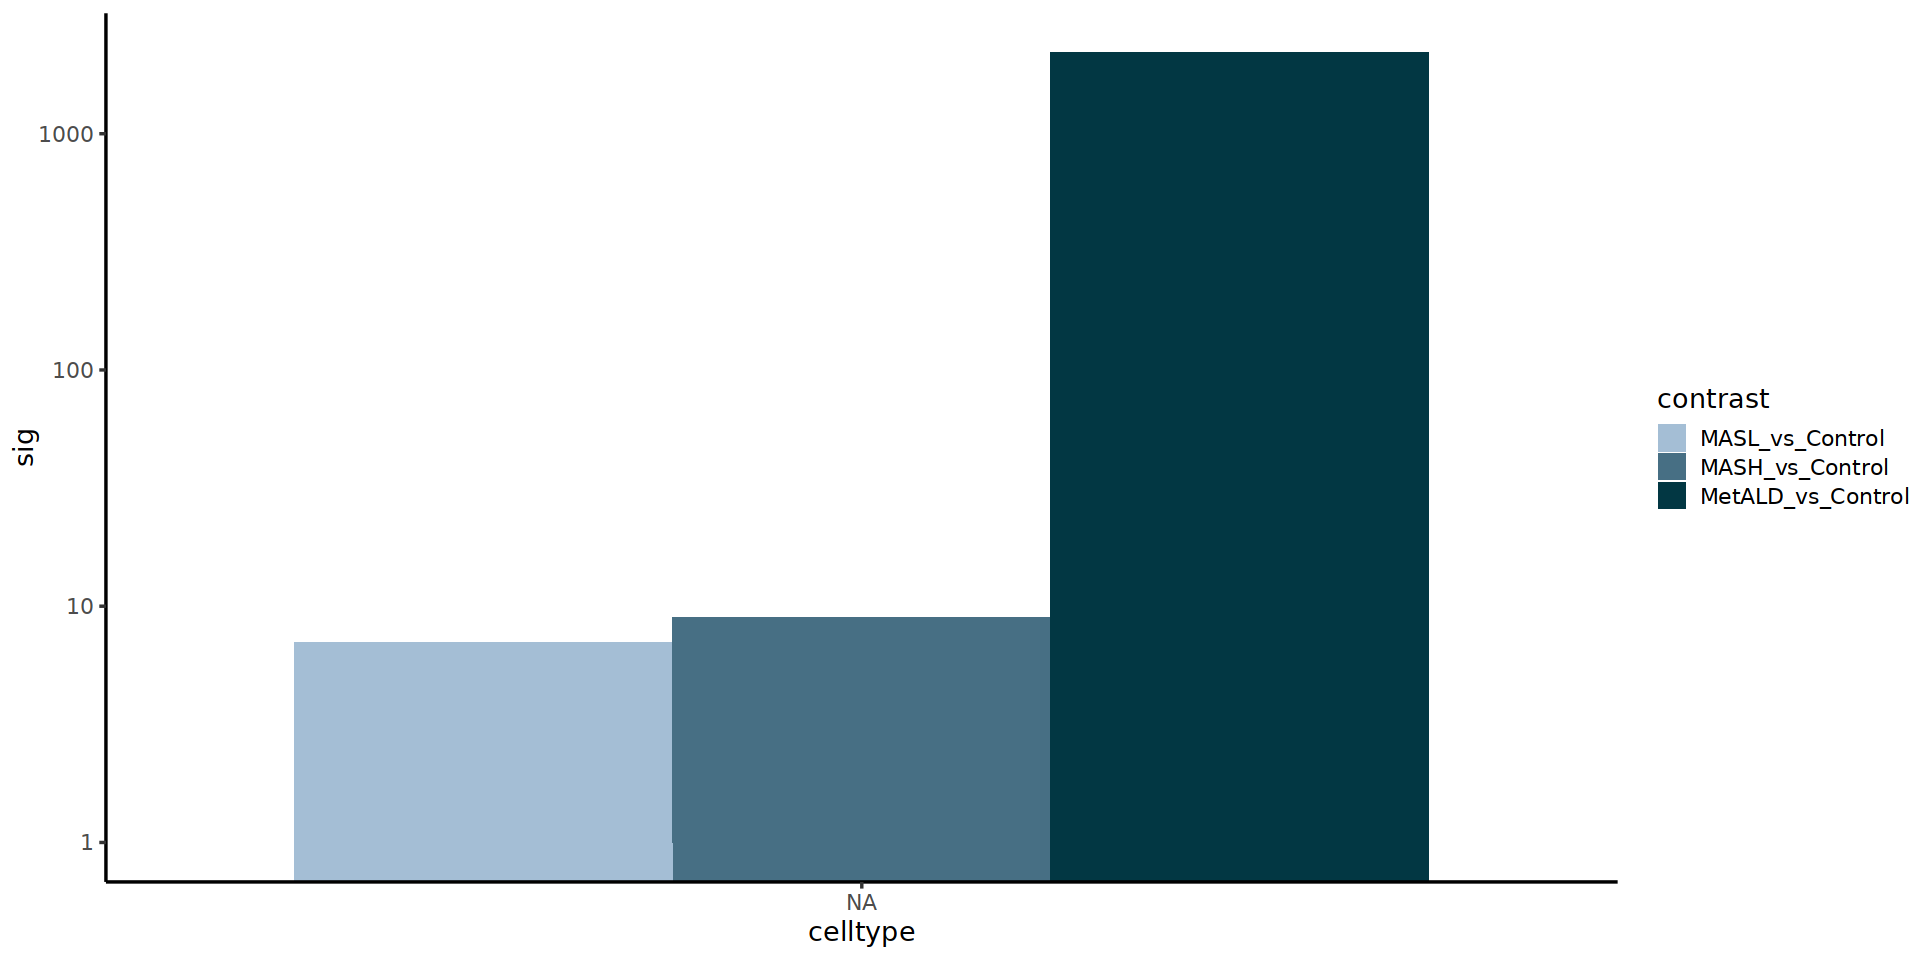

In [50]:
library(nationalparkcolors)

options(repr.plot.width=16, repr.plot.height=8)

ggplot(select(deseq.stats2, -up_pval, -down_pval) %>%
    pivot_longer(c(up_padj, down_padj), values_to = 'sig',names_to = 'direction'),
       aes(x=celltype, fill=contrast, y=sig)) + geom_col(position = 'dodge') +
scale_y_log10()+
    theme_classic(base_size=16) + scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(length(levels(deseq.stats2$contrast))))

### MASH_ALL

In [110]:
#deseq.stats = NULL

for (i in seq_along(files)) {
    file.use = files[i]
    cell.use = cells[i]
    
    if(cell.use %in% c('Bulk')) {
        next
    }
    
    print(paste0("Analyzing: ", cell.use))
    raw_counts <- read.table(paste0(dir, file.use), header = TRUE, row.names = 1)
    #colnames(raw_counts) <- str_remove(colnames(raw_counts), paste0(cell.use, '.'))
    # Remove low bc cells
    #raw_counts <- raw_counts[colnames(raw_counts) %in% meta$donor_demux[meta[[cell.use]] > 10]]
    # Filter for only samples with any counts in the cell type rowSums(raw_counts == 0)
    raw_counts = raw_counts[, (colSums(raw_counts >= 0) > 0)]
    # Subset samples to make one feature with counts in every sample
    best.row <- raw_counts[which(rowSums(raw_counts!=0) == max(rowSums(raw_counts != 0))),][1,]
    raw_counts <- raw_counts[colnames(raw_counts) %in% colnames(best.row)[best.row != 0]]
    print(dim(raw_counts))
    
    message("Donors detectected with celltype: ", ncol(raw_counts))
    if(ncol(raw_counts) == 0) {
        next
    }
    
    meta_cell <- subset(meta, donor %in% colnames(raw_counts))
    rownames(meta_cell) = meta_cell$donor
    message("subsetting metadata accordingly - Check that value is equal to above: ", nrow(meta_cell))
    # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
    meta_cell <- meta_cell[match(colnames(raw_counts), rownames(meta_cell)), ]
    
    contrast.use <- 'MASH_ALL_vs_Control'
    
    condition.1 = c('MASH','MetALD')
    condition.2 = 'Control'
    message(" - ", contrast.use)

    # Create vectors of samples for each condition
    samples.condition.1 <- meta_cell %>% 
                           dplyr::filter(condition %in% condition.1) %>% 
                           pull(donor)
    samples.condition.2 <- meta_cell %>% 
                           dplyr::filter(condition %in% condition.2) %>% 
                           pull(donor)
    
    if(length(samples.condition.1) < 3) {
        next
    }
    if(length(samples.condition.2) < 3) {
        next
    }
    
    # Subset meta_cell for the current contrast
    meta_cell.use <- meta_cell %>% 
                 dplyr::filter(donor %in% c(samples.condition.1, samples.condition.2)) 
    meta_cell.use[meta_cell.use$condition == 'MASH',]$condition <- 'MASH_ALL'
    meta_cell.use[meta_cell.use$condition == 'MetALD',]$condition <- 'MASH_ALL'
    rownames(meta_cell.use) <- meta_cell.use$donor
    
    # Subset raw_counts for the donors in meta_cell
    raw_counts_subset <- raw_counts[, colnames(raw_counts) %in% rownames(meta_cell.use)]

    # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
    meta_cell.use <- meta_cell.use[match(colnames(raw_counts_subset), rownames(meta_cell.use)), ]
    
    # Check if enough samples are present for both conditions
    if (all(summarise(group_by(meta_cell.use, condition), count=n())$count > 2)) {
        deseq.stats.tmp <- data.frame()
        
        if (is.null(nrow(raw_counts_subset))) {
                next
        }
        
        # Light pre-filtering
        counts_filtered <- raw_counts_subset[rowSums(raw_counts_subset) >= 10,]
        counts_filtered <- counts_filtered[,colSums(counts_filtered) > 0]
        
        if (nrow(counts_filtered) < 3) {
            next
        }

        # Run DESeq2
        dds <- DESeqDataSetFromMatrix(countData = round(counts_filtered),
                                      colData = meta_cell.use, 
                                      design = deseq.formula)
        dds$condition <- relevel(dds$condition, ref = condition.2)
        dds <- DESeq(dds)
        dds.results <- results(dds)
        
        # Write DESeq results to file
        write.table(dds.results, 
                    file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                    sep = '\t', quote = FALSE)
        
        dds.results <- na.omit(dds.results[order(dds.results$padj), ])

        # Write DESeq results to file
        write.table(dds.results, 
                    file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                    sep = '\t', quote = FALSE)
        
        # Collect summary statistics
        deseq.stats.tmp <- data.frame(
            celltype = cell.use,
            contrast = contrast.use,
            up_pval = sum(dds.results$log2FoldChange > 0 & dds.results$pvalue < 0.05),
            down_pval = sum(dds.results$log2FoldChange < 0 & dds.results$pvalue < 0.05),
            up_padj = sum(dds.results$log2FoldChange > 0 & dds.results$padj < 0.1),
            down_padj = sum(dds.results$log2FoldChange < 0 & dds.results$padj < 0.1))
            deseq.stats <- rbind(deseq.stats, deseq.stats.tmp)

                       # Make Volcano plot - Padj
                        res = as.data.frame(dds.results)
                        res$SYMBOL = rownames(res)
                        res = res %>%
                        dplyr::filter(!is.na(SYMBOL)) %>%
                        dplyr::filter(padj < 0.1) %>%
                        dplyr::group_by(sign(log2FoldChange)) %>%
                        dplyr::mutate(rank = abs(log2FoldChange) * -log10(padj)) %>%
                        dplyr::top_n(50, rank) %>%
                        dplyr::mutate(delabel = SYMBOL) %>%
                        ungroup() %>%
                        dplyr::select(delabel, SYMBOL) %>%
                        right_join(res) %>%
                        dplyr::mutate(delabel = if_else(is.na(delabel), "", as.character(delabel))) 

                        # Add a new column for color based on significance and direction
                        res$changes <- ifelse(res$log2FoldChange > 0 & res$padj < 0.1, "Up-regulated",
                                            ifelse(res$log2FoldChange < 0 & res$padj < 0.1, "Down-regulated", "NS"))
                        # Get the number of upregulated and downregulated genes
                        n_up <- sum(res$changes == "Up-regulated")
                        n_down <- sum(res$changes == "Down-regulated")

                        # Modify log2FoldChange values to be max x
                        res$log2FoldChange[res$log2FoldChange > 10] <- 10
                        res$log2FoldChange[res$log2FoldChange < -10] <- -10
                        # Modify padj values to be max x 
                        res$padj[res$padj < 10^-200] <- 10^-200
                
                        plot = ggplot(res, aes(x=log2FoldChange, y=-log10(padj), label=delabel, color=changes)) +
                            theme_bw() +
                            labs(y="-log10(padj)", x="log2FoldChange", 
                               title=paste(cell.use, " - ",
                                           condition.1, "Vs", condition.2, "\n",
                                          "Up: ", n_up, "-",
                                           "Down: ", n_down)) +
                            geom_point() +
                            scale_color_manual(values=c("blue", "grey", "red")) + 
                            theme(axis.text=element_text(size=16), axis.title=element_text(size=16, face="bold"),
                                axis.text.x=element_text(), plot.title=element_text(size=18, face="bold", hjust=0.5)) +
                            scale_x_continuous(breaks=c(-10, -5, 0, 5, 10),
                                        labels=c("< -10", "-5", "0", "5", "> 10"), lim = c(-10, 10))+
                            scale_y_continuous(breaks=c(0, 20, 40, 60, 80, 100, 200),
                                        labels=c("0", "20", "40", "60", "80", "100", ">200"))+
                            geom_text_repel(label=res$delabel, size=3.5, max.overlaps=10,
                                          point.padding=0, min.segment.length=0,
                                          max.time=20, max.iter=1e5, box.padding=0.3)
                
                        ggsave(filename = paste0(outdir, cell.use, "_", contrast.use, ".volcanoPlot.pdf"),
                               height = 10, width = 10,
                               plot = plot, device = "pdf")
    } else {
        message("Not enough samples for contrast: ", contrast.use)
    }
}

[1] "Analyzing: Hepatocytes.Senescent"
[1] 191678     56


Donors detectected with celltype: 56

subsetting metadata accordingly - Check that value is equal to above: 56

 - MASH_ALL_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimat

[1] "Analyzing: Hepatocytes.Stress"
[1] 191678     15


Donors detectected with celltype: 15

subsetting metadata accordingly - Check that value is equal to above: 15

 - MASH_ALL_vs_Control



[1] "Analyzing: Hepatocytes.Zone1"
[1] 191678     48


Donors detectected with celltype: 48

subsetting metadata accordingly - Check that value is equal to above: 48

 - MASH_ALL_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimat

[1] "Analyzing: Hepatocytes.Zone2"
[1] 191678     37


Donors detectected with celltype: 37

subsetting metadata accordingly - Check that value is equal to above: 37

 - MASH_ALL_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimat

[1] "Analyzing: Hepatocytes.Zone3"
[1] 191678     69


Donors detectected with celltype: 69

subsetting metadata accordingly - Check that value is equal to above: 69

 - MASH_ALL_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimat

In [111]:
deseq.stats

celltype,contrast,up_pval,down_pval,up_padj,down_padj
<chr>,<chr>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,MASL_vs_Control,2635,27,0,7
Hepatocytes.Senescent,MASH_vs_Control,4916,23,1,0
Hepatocytes.Senescent,MetALD_vs_Control,10026,25,2201,2
Hepatocytes.Zone1,MASL_vs_Control,913,1103,0,2
Hepatocytes.Zone1,MASH_vs_Control,297,3381,0,2
Hepatocytes.Zone1,MetALD_vs_Control,2044,981,1,4
Hepatocytes.Zone2,MASL_vs_Control,3077,573,0,0
Hepatocytes.Zone2,MASH_vs_Control,1667,491,0,6
Hepatocytes.Zone2,MetALD_vs_Control,1027,845,3,20


In [112]:
mutate(deseq.stats, sig = up_padj + down_padj) %>%
    select(celltype, contrast, sig) %>%
    pivot_wider(names_from = contrast, values_from = sig)

celltype,MASL_vs_Control,MASH_vs_Control,MetALD_vs_Control,MASH_ALL_vs_Control
<chr>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,7,1,2203,857
Hepatocytes.Zone1,2,2,5,0
Hepatocytes.Zone2,0,6,23,0
Hepatocytes.Zone3,0,10,84,1


In [113]:
deseq.stats2 <- deseq.stats

In [114]:
deseq.stats2$contrast <- factor(deseq.stats2$contrast, levels = c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control',"MASH_ALL_vs_Control"))
deseq.stats2$celltype <- factor(deseq.stats2$celltype, levels = paste0(names(sort(colSums(meta[,2:11]), decreasing = T))))                           

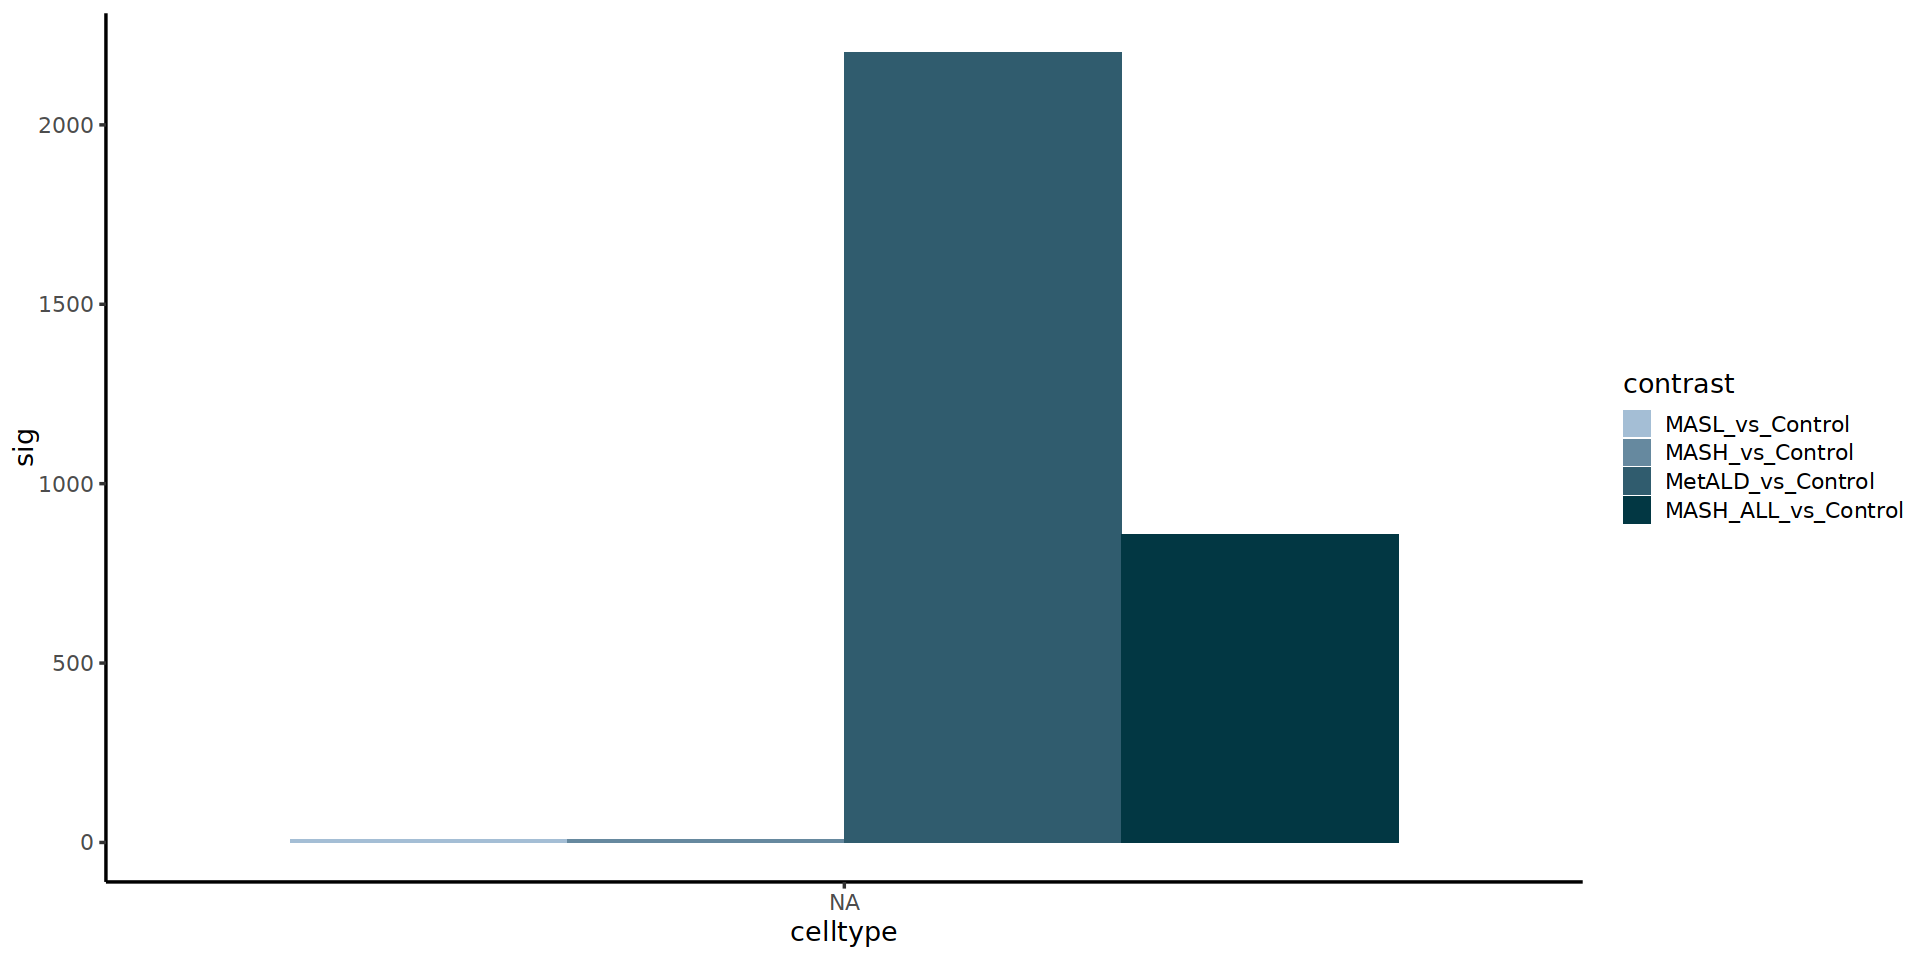

In [115]:
library(nationalparkcolors)

options(repr.plot.width=16, repr.plot.height=8)

ggplot(select(deseq.stats2, -up_pval, -down_pval) %>%
    pivot_longer(c(up_padj, down_padj), values_to = 'sig',names_to = 'direction'),
       aes(x=celltype, fill=contrast, y=sig)) + geom_col(position = 'dodge') +
    theme_classic(base_size=16) + scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(length(levels(deseq.stats2$contrast))))

### Fibrosis

In [116]:
contrasts  <- c('Fibrosis.stage')


# Define the DESeq2 formula
deseq.base.formula <- '~ Age.scaled + BMI.scaled + batch + Gender'

In [117]:
#deseq.stats = NULL

for (i in seq_along(files)) {
    file.use = files[i]
    cell.use = cells[i]
    
    if(cell.use %in% c('Bulk')) {
        next
    }
    
    print(paste0("Analyzing: ", cell.use))
    raw_counts <- read.table(paste0(dir, file.use), header = TRUE, row.names = 1)
    #colnames(raw_counts) <- str_remove(colnames(raw_counts), paste0(cell.use, '.'))
    # Remove low bc cells
    #raw_counts <- raw_counts[colnames(raw_counts) %in% meta$donor_demux[meta[[cell.use]] > 10]]
    # Filter for only samples with any counts in the cell type rowSums(raw_counts == 0)
    raw_counts = raw_counts[, (colSums(raw_counts >= 0) > 0)]
    # Subset samples to make one feature with counts in every sample
    best.row <- raw_counts[which(rowSums(raw_counts!=0) == max(rowSums(raw_counts != 0))),][1,]
    raw_counts <- raw_counts[colnames(raw_counts) %in% colnames(best.row)[best.row != 0]]
    print(dim(raw_counts))
    
    message("Donors detectected with celltype: ", ncol(raw_counts))
    if(ncol(raw_counts) == 0) {
        next
    }
    
    meta_cell <- subset(meta, donor %in% colnames(raw_counts))
    rownames(meta_cell) = meta_cell$donor
    message("Subsetting metadata accordingly - Check that value is equal to above: ", nrow(meta_cell))
    meta_cell <- meta_cell[match(colnames(raw_counts), rownames(meta_cell)), ]
    
    for (contrast in contrasts) {
        contrast.use <- contrast
        message("  - ", contrast.use)

        # Create vectors of samples for each condition
        samples <- meta_cell %>%  
                   pull(donor)
        
        if(length(samples) < 3) {
            next
        }
        
        # Subset meta_cell for the current contrast
        meta_cell.use <- meta_cell %>% 
                     dplyr::filter(donor %in% c(samples)) 
        rownames(meta_cell.use) <- meta_cell.use$donor
        
        # Subset raw_counts for the donors in meta_cell
        raw_counts_subset <- raw_counts[, colnames(raw_counts) %in% rownames(meta_cell.use)]

        # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
        meta_cell.use <- meta_cell.use[match(colnames(raw_counts_subset), rownames(meta_cell.use)), ]
        
        # Check if enough samples are present for both conditions
        if (length(unique(meta_cell.use[[contrast.use]])) >= 2) {
            deseq.stats.tmp <- data.frame()
            
            if (is.null(nrow(raw_counts_subset))) {
                next
            }
            
            # Light pre-filtering
            counts_filtered <- raw_counts_subset[rowSums(raw_counts_subset) >= 10,]
            
            if (nrow(counts_filtered) < 3) {
                next
            }

            # Run DESeq2 with a check for full rank
            tryCatch({
                deseq.formula <- as.formula(paste0(deseq.base.formula,'+',contrast.use))
                
                
                dds <- DESeqDataSetFromMatrix(countData = round(counts_filtered),
                                              colData = meta_cell.use, 
                                              design = deseq.formula)
                
                # DESeq analysis
                dds <- DESeq(dds)
                dds.results <- results(dds)
                
                # Write DESeq results to file
                write.table(dds.results, 
                    file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                    sep = '\t', quote = FALSE)
                
                dds.results <- na.omit(dds.results[order(dds.results$padj), ])
                
                # Write DESeq results to file
                write.table(dds.results, 
                            file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                            sep = '\t', quote = FALSE)
                
                # Collect summary statistics
                deseq.stats.tmp <- data.frame(
                    celltype = cell.use,
                    contrast = contrast.use,
                    up_pval = sum(dds.results$log2FoldChange > 0 & dds.results$pvalue < 0.05),
                    down_pval = sum(dds.results$log2FoldChange < 0 & dds.results$pvalue < 0.05),
                    up_padj = sum(dds.results$log2FoldChange > 0 & dds.results$padj < 0.1),
                    down_padj = sum(dds.results$log2FoldChange < 0 & dds.results$padj < 0.1))
                deseq.stats <- rbind(deseq.stats, deseq.stats.tmp)
                
                             # Make Volcano plot - Padj
                            res = as.data.frame(dds.results)
                            res$SYMBOL = rownames(res)
                            res = res %>%
                            dplyr::filter(!is.na(SYMBOL)) %>%
                            dplyr::filter(padj < 0.1) %>%
                            dplyr::group_by(sign(log2FoldChange)) %>%
                            dplyr::mutate(rank = abs(log2FoldChange) * -log10(padj)) %>%
                            dplyr::top_n(50, rank) %>%
                            dplyr::mutate(delabel = SYMBOL) %>%
                            ungroup() %>%
                            dplyr::select(delabel, SYMBOL) %>%
                            right_join(res) %>%
                            dplyr::mutate(delabel = if_else(is.na(delabel), "", as.character(delabel))) 

                            # Add a new column for color based on significance and direction
                            res$changes <- ifelse(res$log2FoldChange > 0 & res$padj < 0.1, "Up-regulated",
                                                ifelse(res$log2FoldChange < 0 & res$padj < 0.1, "Down-regulated", "NS"))
                            # Get the number of upregulated and downregulated genes
                            n_up <- sum(res$changes == "Up-regulated")
                            n_down <- sum(res$changes == "Down-regulated")

                            # Modify log2FoldChange values to be max x
                            res$log2FoldChange[res$log2FoldChange > 10] <- 10
                            res$log2FoldChange[res$log2FoldChange < -10] <- -10
                            # Modify padj values to be max x 
                            res$padj[res$padj < 10^-200] <- 10^-200
                    
                            plot = ggplot(res, aes(x=log2FoldChange, y=-log10(padj), label=delabel, color=changes)) +
                                theme_bw() +
                                labs(y="-log10(padj)", x="log2FoldChange", 
                                   title=paste(cell.use, " - ",
                                               contrast.use, "\n",
                                              "Up: ", n_up, "-",
                                               "Down: ", n_down)) +
                                geom_point() +
                                scale_color_manual(values=c("blue", "grey", "red")) + 
                                theme(axis.text=element_text(size=16), axis.title=element_text(size=16, face="bold"),
                                    axis.text.x=element_text(), plot.title=element_text(size=18, face="bold", hjust=0.5)) +
                                scale_x_continuous(breaks=c(-10, -5, 0, 5, 10),
                                            labels=c("< -10", "-5", "0", "5", "> 10"), lim = c(-10, 10))+
                                scale_y_continuous(breaks=c(0, 20, 40, 60, 80, 100, 200),
                                            labels=c("0", "20", "40", "60", "80", "100", ">200"))+
                                geom_text_repel(label=res$delabel, size=3.5, max.overlaps=10,
                                              point.padding=0, min.segment.length=0,
                                              max.time=20, max.iter=1e5, box.padding=0.3)
                    
                            ggsave(filename = paste0(outdir, cell.use, "_", contrast.use, ".volcanoPlot.pdf"),
                                   height = 10, width = 10,
                                   plot = plot, device = "pdf")

            }, error = function(e) {
                message(paste0("Skipping contrast ", contrast.use, ": ", e$message))
            })
        } else {
            message("Not enough samples for contrast: ", contrast.use)
        }
    }
}


[1] "Analyzing: Hepatocytes.Senescent"
[1] 191678     56


Donors detectected with celltype: 56

Subsetting metadata accordingly - Check that value is equal to above: 56

  - Fibrosis.stage

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates



[1] "Analyzing: Hepatocytes.Stress"
[1] 191678     15


Donors detectected with celltype: 15

Subsetting metadata accordingly - Check that value is equal to above: 15

  - Fibrosis.stage

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates



[1] "Analyzing: Hepatocytes.Zone1"
[1] 191678     48


Donors detectected with celltype: 48

Subsetting metadata accordingly - Check that value is equal to above: 48

  - Fibrosis.stage

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates



[1] "Analyzing: Hepatocytes.Zone2"
[1] 191678     37


Donors detectected with celltype: 37

Subsetting metadata accordingly - Check that value is equal to above: 37

  - Fibrosis.stage

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates



[1] "Analyzing: Hepatocytes.Zone3"
[1] 191678     69


Donors detectected with celltype: 69

Subsetting metadata accordingly - Check that value is equal to above: 69

  - Fibrosis.stage

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates



In [118]:
deseq.stats

celltype,contrast,up_pval,down_pval,up_padj,down_padj
<chr>,<chr>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,MASL_vs_Control,2635,27,0,7
Hepatocytes.Senescent,MASH_vs_Control,4916,23,1,0
Hepatocytes.Senescent,MetALD_vs_Control,10026,25,2201,2
Hepatocytes.Zone1,MASL_vs_Control,913,1103,0,2
Hepatocytes.Zone1,MASH_vs_Control,297,3381,0,2
Hepatocytes.Zone1,MetALD_vs_Control,2044,981,1,4
Hepatocytes.Zone2,MASL_vs_Control,3077,573,0,0
Hepatocytes.Zone2,MASH_vs_Control,1667,491,0,6
Hepatocytes.Zone2,MetALD_vs_Control,1027,845,3,20


In [119]:
mutate(deseq.stats, sig = up_padj + down_padj) %>%
    select(celltype, contrast, sig) %>%
    pivot_wider(names_from = contrast, values_from = sig)

celltype,MASL_vs_Control,MASH_vs_Control,MetALD_vs_Control,MASH_ALL_vs_Control,Fibrosis.stage
<chr>,<int>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,7,1,2203,857,0
Hepatocytes.Zone1,2,2,5,0,0
Hepatocytes.Zone2,0,6,23,0,0
Hepatocytes.Zone3,0,10,84,1,63
Hepatocytes.Stress,NA,NA,NA,NA,1


In [120]:
deseq.stats2 <- deseq.stats

In [121]:
deseq.stats2$contrast <- factor(deseq.stats2$contrast, levels = c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control',"MASH_ALL_vs_Control",'Fibrosis.stage'))
deseq.stats2$celltype <- factor(deseq.stats2$celltype, levels = paste0(names(sort(colSums(meta[,2:11]), decreasing = T))))                           

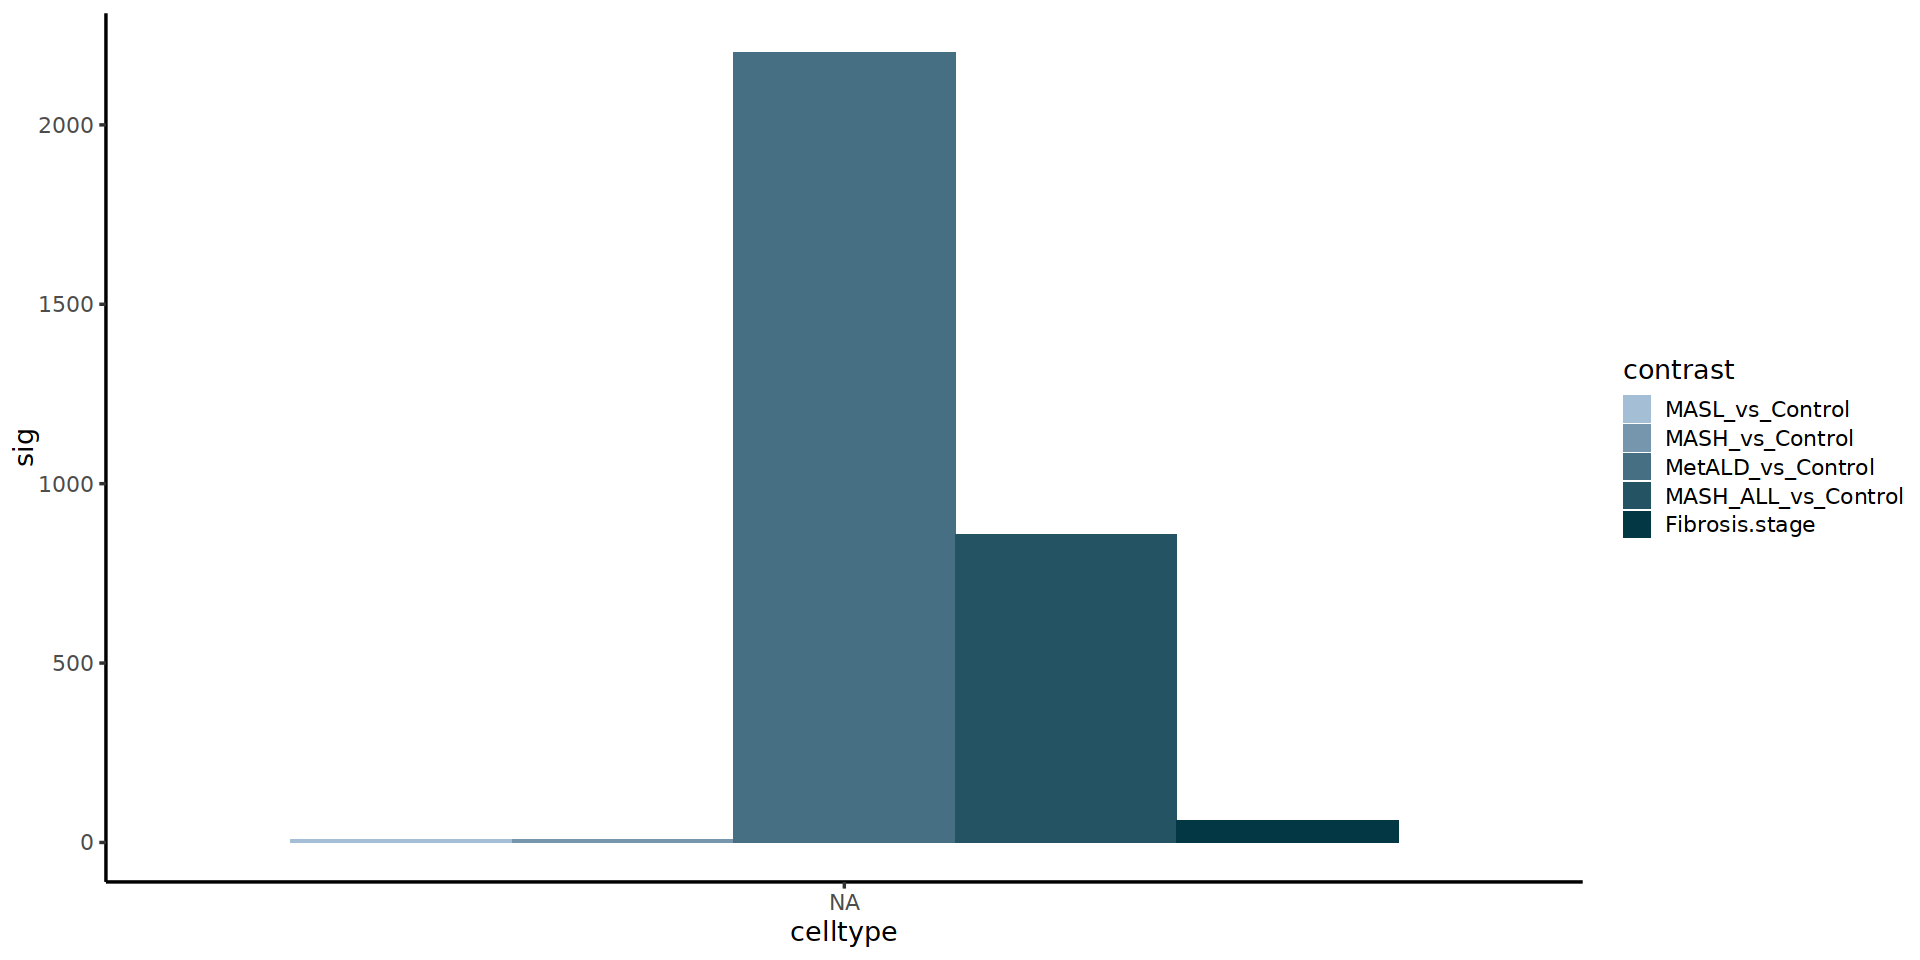

In [122]:
library(nationalparkcolors)

options(repr.plot.width=16, repr.plot.height=8)

ggplot(select(deseq.stats2, -up_pval, -down_pval) %>%
    pivot_longer(c(up_padj, down_padj), values_to = 'sig',names_to = 'direction'),
       aes(x=celltype, fill=contrast, y=sig)) + geom_col(position = 'dodge') +
    theme_classic(base_size=16) + scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(length(levels(deseq.stats2$contrast))))

In [123]:
write.table(deseq.stats, paste0(outdir, '241024_WE_deseq_summary.tsv'),
           col.names=T, row.names=T, quote=F, sep='\t')

### Other Meta

In [124]:
contrasts  <- c('Steatosis.grade', 'Lobular.inflammation', 'Ballooning', 'MASH.CRN.score..X.8')


# Define the DESeq2 formula
deseq.base.formula <- '~ Fibrosis.stage + Age.scaled + BMI.scaled + batch + Gender'

In [125]:
#deseq.stats = NULL

for (i in seq_along(files)) {
    file.use = files[i]
    cell.use = cells[i]
    
    if(cell.use %in% c('Bulk')) {
        next
    }
    
    print(paste0("Analyzing: ", cell.use))
    raw_counts <- read.table(paste0(dir, file.use), header = TRUE, row.names = 1)
    #colnames(raw_counts) <- str_remove(colnames(raw_counts), paste0(cell.use, '.'))
    # Remove low bc cells
    #raw_counts <- raw_counts[colnames(raw_counts) %in% meta$donor_demux[meta[[cell.use]] > 10]]
    # Filter for only samples with any counts in the cell type rowSums(raw_counts == 0)
    raw_counts = raw_counts[, (colSums(raw_counts >= 0) > 0)]
    # Subset samples to make one feature with counts in every sample
    best.row <- raw_counts[which(rowSums(raw_counts!=0) == max(rowSums(raw_counts != 0))),][1,]
    raw_counts <- raw_counts[colnames(raw_counts) %in% colnames(best.row)[best.row != 0]]
    print(dim(raw_counts))
    
    message("Donors detectected with celltype: ", ncol(raw_counts))
    if(ncol(raw_counts) == 0) {
        next
    }
    
    meta_cell <- subset(meta, donor %in% colnames(raw_counts))
    rownames(meta_cell) = meta_cell$donor
    message("Subsetting metadata accordingly - Check that value is equal to above: ", nrow(meta_cell))
    meta_cell <- meta_cell[match(colnames(raw_counts), rownames(meta_cell)), ]
    
    for (contrast in contrasts) {
        contrast.use <- contrast
        message("  - ", contrast.use)

        # Create vectors of samples for each condition
        samples <- meta_cell %>%  
                   pull(donor)
        
        if(length(samples) < 3) {
            next
        }
        
        # Subset meta_cell for the current contrast
        meta_cell.use <- meta_cell %>% 
                     dplyr::filter(donor %in% c(samples)) 
        rownames(meta_cell.use) <- meta_cell.use$donor
        
        # Subset raw_counts for the donors in meta_cell
        raw_counts_subset <- raw_counts[, colnames(raw_counts) %in% rownames(meta_cell.use)]

        # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
        meta_cell.use <- meta_cell.use[match(colnames(raw_counts_subset), rownames(meta_cell.use)), ]
        
        # Check if enough samples are present for both conditions
        if (length(unique(meta_cell.use[[contrast.use]])) >= 2) {
            deseq.stats.tmp <- data.frame()
            
            if (is.null(nrow(raw_counts_subset))) {
                next
            }
            
            # Light pre-filtering
            counts_filtered <- raw_counts_subset[rowSums(raw_counts_subset) >= 10,]
            
            if (nrow(counts_filtered) < 3) {
                next
            }

            # Run DESeq2 with a check for full rank
            tryCatch({
                deseq.formula <- as.formula(paste0(deseq.base.formula,'+',contrast.use))
                
                
                dds <- DESeqDataSetFromMatrix(countData = round(counts_filtered),
                                              colData = meta_cell.use, 
                                              design = deseq.formula)
                
                # DESeq analysis
                dds <- DESeq(dds)
                dds.results <- results(dds)
                
                # Write DESeq results to file
                write.table(dds.results, 
                    file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                    sep = '\t', quote = FALSE)
                
                dds.results <- na.omit(dds.results[order(dds.results$padj), ])
                
                # Write DESeq results to file
                write.table(dds.results, 
                            file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                            sep = '\t', quote = FALSE)
                
                # Collect summary statistics
                deseq.stats.tmp <- data.frame(
                    celltype = cell.use,
                    contrast = contrast.use,
                    up_pval = sum(dds.results$log2FoldChange > 0 & dds.results$pvalue < 0.05),
                    down_pval = sum(dds.results$log2FoldChange < 0 & dds.results$pvalue < 0.05),
                    up_padj = sum(dds.results$log2FoldChange > 0 & dds.results$padj < 0.1),
                    down_padj = sum(dds.results$log2FoldChange < 0 & dds.results$padj < 0.1))
                deseq.stats <- rbind(deseq.stats, deseq.stats.tmp)
                
                             # Make Volcano plot - Padj
                            res = as.data.frame(dds.results)
                            res$SYMBOL = rownames(res)
                            res = res %>%
                            dplyr::filter(!is.na(SYMBOL)) %>%
                            dplyr::filter(padj < 0.1) %>%
                            dplyr::group_by(sign(log2FoldChange)) %>%
                            dplyr::mutate(rank = abs(log2FoldChange) * -log10(padj)) %>%
                            dplyr::top_n(50, rank) %>%
                            dplyr::mutate(delabel = SYMBOL) %>%
                            ungroup() %>%
                            dplyr::select(delabel, SYMBOL) %>%
                            right_join(res) %>%
                            dplyr::mutate(delabel = if_else(is.na(delabel), "", as.character(delabel))) 

                            # Add a new column for color based on significance and direction
                            res$changes <- ifelse(res$log2FoldChange > 0 & res$padj < 0.1, "Up-regulated",
                                                ifelse(res$log2FoldChange < 0 & res$padj < 0.1, "Down-regulated", "NS"))
                            # Get the number of upregulated and downregulated genes
                            n_up <- sum(res$changes == "Up-regulated")
                            n_down <- sum(res$changes == "Down-regulated")

                            # Modify log2FoldChange values to be max x
                            res$log2FoldChange[res$log2FoldChange > 10] <- 10
                            res$log2FoldChange[res$log2FoldChange < -10] <- -10
                            # Modify padj values to be max x 
                            res$padj[res$padj < 10^-200] <- 10^-200
                    
                            plot = ggplot(res, aes(x=log2FoldChange, y=-log10(padj), label=delabel, color=changes)) +
                                theme_bw() +
                                labs(y="-log10(padj)", x="log2FoldChange", 
                                   title=paste(cell.use, " - ",
                                               contrast.use, "\n",
                                              "Up: ", n_up, "-",
                                               "Down: ", n_down)) +
                                geom_point() +
                                scale_color_manual(values=c("blue", "grey", "red")) + 
                                theme(axis.text=element_text(size=16), axis.title=element_text(size=16, face="bold"),
                                    axis.text.x=element_text(), plot.title=element_text(size=18, face="bold", hjust=0.5)) +
                                scale_x_continuous(breaks=c(-10, -5, 0, 5, 10),
                                            labels=c("< -10", "-5", "0", "5", "> 10"), lim = c(-10, 10))+
                                scale_y_continuous(breaks=c(0, 20, 40, 60, 80, 100, 200),
                                            labels=c("0", "20", "40", "60", "80", "100", ">200"))+
                                geom_text_repel(label=res$delabel, size=3.5, max.overlaps=10,
                                              point.padding=0, min.segment.length=0,
                                              max.time=20, max.iter=1e5, box.padding=0.3)
                    
                            ggsave(filename = paste0(outdir, cell.use, "_", contrast.use, ".volcanoPlot.pdf"),
                                   height = 10, width = 10,
                                   plot = plot, device = "pdf")

            }, error = function(e) {
                message(paste0("Skipping contrast ", contrast.use, ": ", e$message))
            })
        } else {
            message("Not enough samples for contrast: ", contrast.use)
        }
    }
}


[1] "Analyzing: Hepatocytes.Senescent"
[1] 191678     56


Donors detectected with celltype: 56

Subsetting metadata accordingly - Check that value is equal to above: 56

  - Steatosis.grade

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates


[1] "Analyzing: Hepatocytes.Stress"
[1] 191678     15


Donors detectected with celltype: 15

Subsetting metadata accordingly - Check that value is equal to above: 15

  - Steatosis.grade

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates


[1] "Analyzing: Hepatocytes.Zone1"
[1] 191678     48


Donors detectected with celltype: 48

Subsetting metadata accordingly - Check that value is equal to above: 48

  - Steatosis.grade

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates


[1] "Analyzing: Hepatocytes.Zone2"
[1] 191678     37


Donors detectected with celltype: 37

Subsetting metadata accordingly - Check that value is equal to above: 37

  - Steatosis.grade

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates


[1] "Analyzing: Hepatocytes.Zone3"
[1] 191678     69


Donors detectected with celltype: 69

Subsetting metadata accordingly - Check that value is equal to above: 69

  - Steatosis.grade

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates


In [126]:
deseq.stats

celltype,contrast,up_pval,down_pval,up_padj,down_padj
<chr>,<chr>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,MASL_vs_Control,2635,27,0,7
Hepatocytes.Senescent,MASH_vs_Control,4916,23,1,0
Hepatocytes.Senescent,MetALD_vs_Control,10026,25,2201,2
Hepatocytes.Zone1,MASL_vs_Control,913,1103,0,2
Hepatocytes.Zone1,MASH_vs_Control,297,3381,0,2
Hepatocytes.Zone1,MetALD_vs_Control,2044,981,1,4
Hepatocytes.Zone2,MASL_vs_Control,3077,573,0,0
Hepatocytes.Zone2,MASH_vs_Control,1667,491,0,6
Hepatocytes.Zone2,MetALD_vs_Control,1027,845,3,20


In [127]:
mutate(deseq.stats, sig = up_padj + down_padj) %>%
    select(celltype, contrast, sig) %>%
    pivot_wider(names_from = contrast, values_from = sig)

celltype,MASL_vs_Control,MASH_vs_Control,MetALD_vs_Control,MASH_ALL_vs_Control,Fibrosis.stage,Steatosis.grade,Lobular.inflammation,MASH.CRN.score..X.8,Ballooning
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,7,1,2203,857,0,1820,0,32,NA
Hepatocytes.Zone1,2,2,5,0,0,0,0,0,NA
Hepatocytes.Zone2,0,6,23,0,0,2,4,4,6
Hepatocytes.Zone3,0,10,84,1,63,0,0,0,NA
Hepatocytes.Stress,NA,NA,NA,NA,1,4408,1048,163,837


In [128]:
deseq.stats2 <- deseq.stats

In [129]:
deseq.stats2$contrast <- factor(deseq.stats2$contrast, levels = c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control',"MASH_ALL_vs_Control",'Fibrosis.stage',
                                    'Steatosis.grade', 'Lobular.inflammation', 'MASH.CRN.score..X.8', 'Age.scaled', 'BMI.scaled'))
deseq.stats2$celltype <- factor(deseq.stats2$celltype, levels = paste0(names(sort(colSums(meta[,2:11]), decreasing = T))))                           

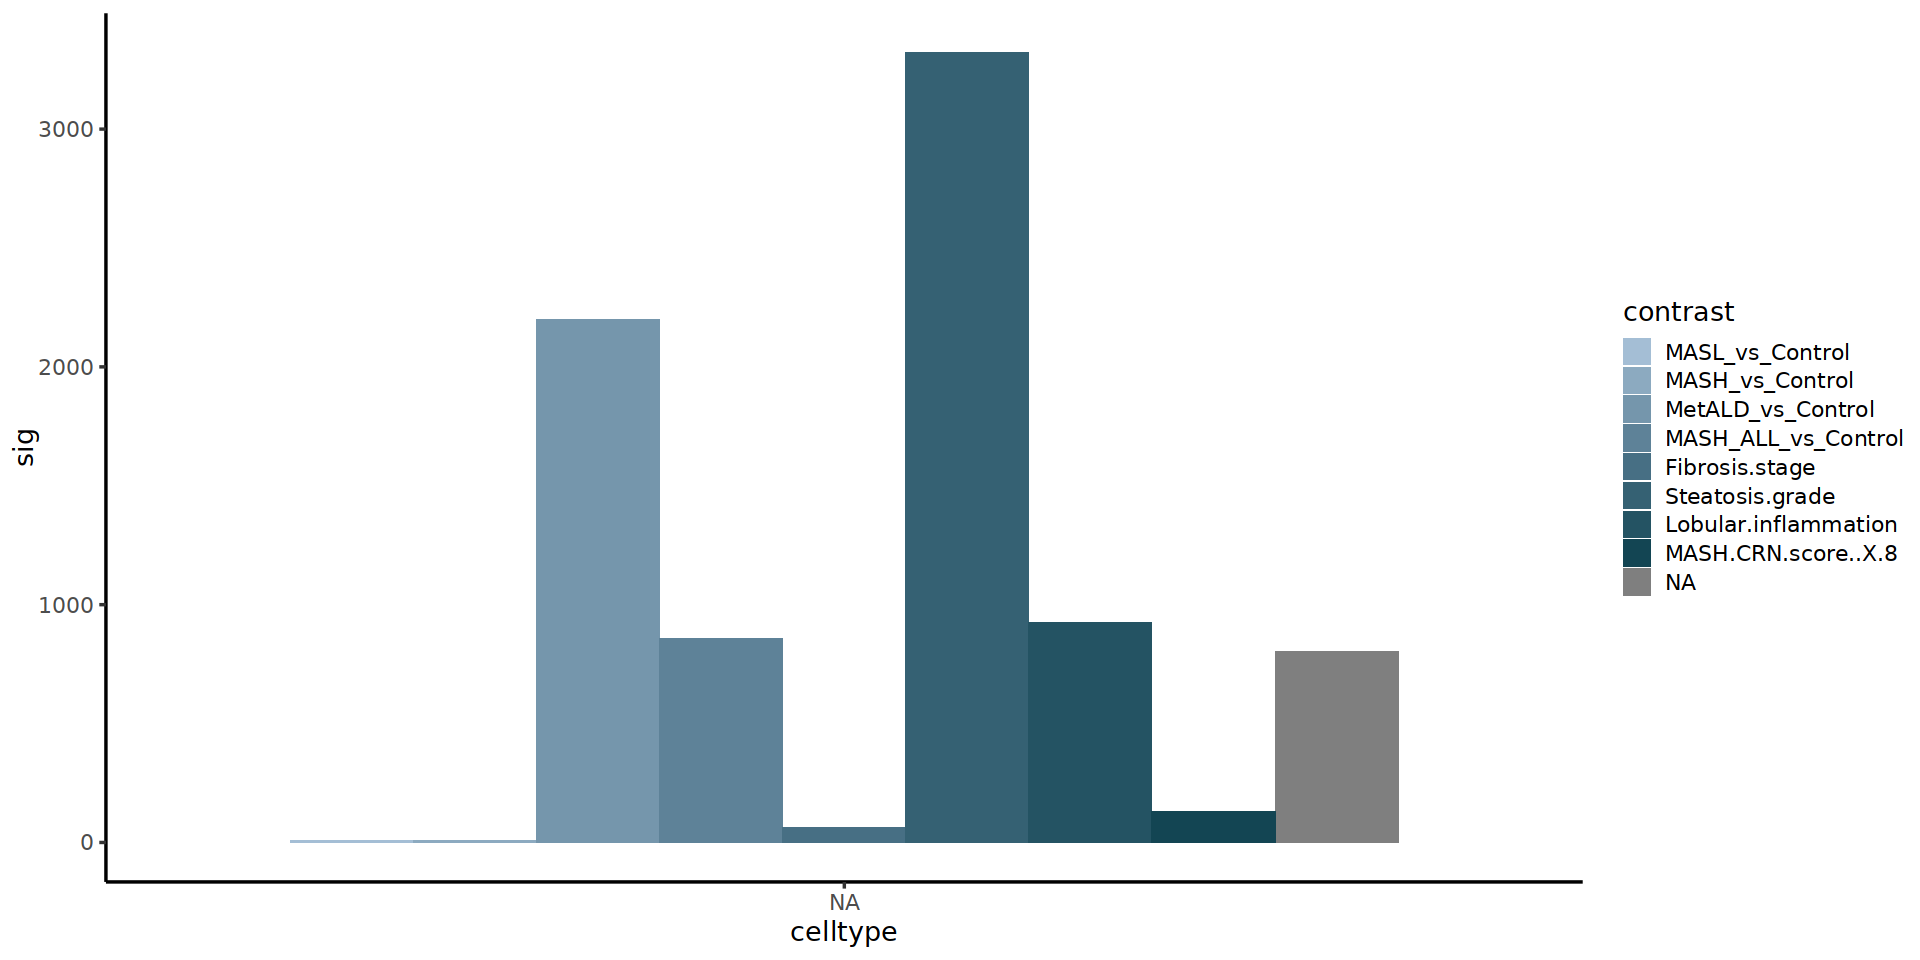

In [130]:
library(nationalparkcolors)

options(repr.plot.width=16, repr.plot.height=8)

ggplot(select(deseq.stats2, -up_pval, -down_pval) %>%
    pivot_longer(c(up_padj, down_padj), values_to = 'sig',names_to = 'direction'),
       aes(x=celltype, fill=contrast, y=sig)) + geom_col(position = 'dodge') +
    #scale_y_log10() +
    theme_classic(base_size=16) + scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(length(unique(deseq.stats2$contrast))))

Warning message in scale_y_log10():
“log-10 transformation introduced infinite values.”


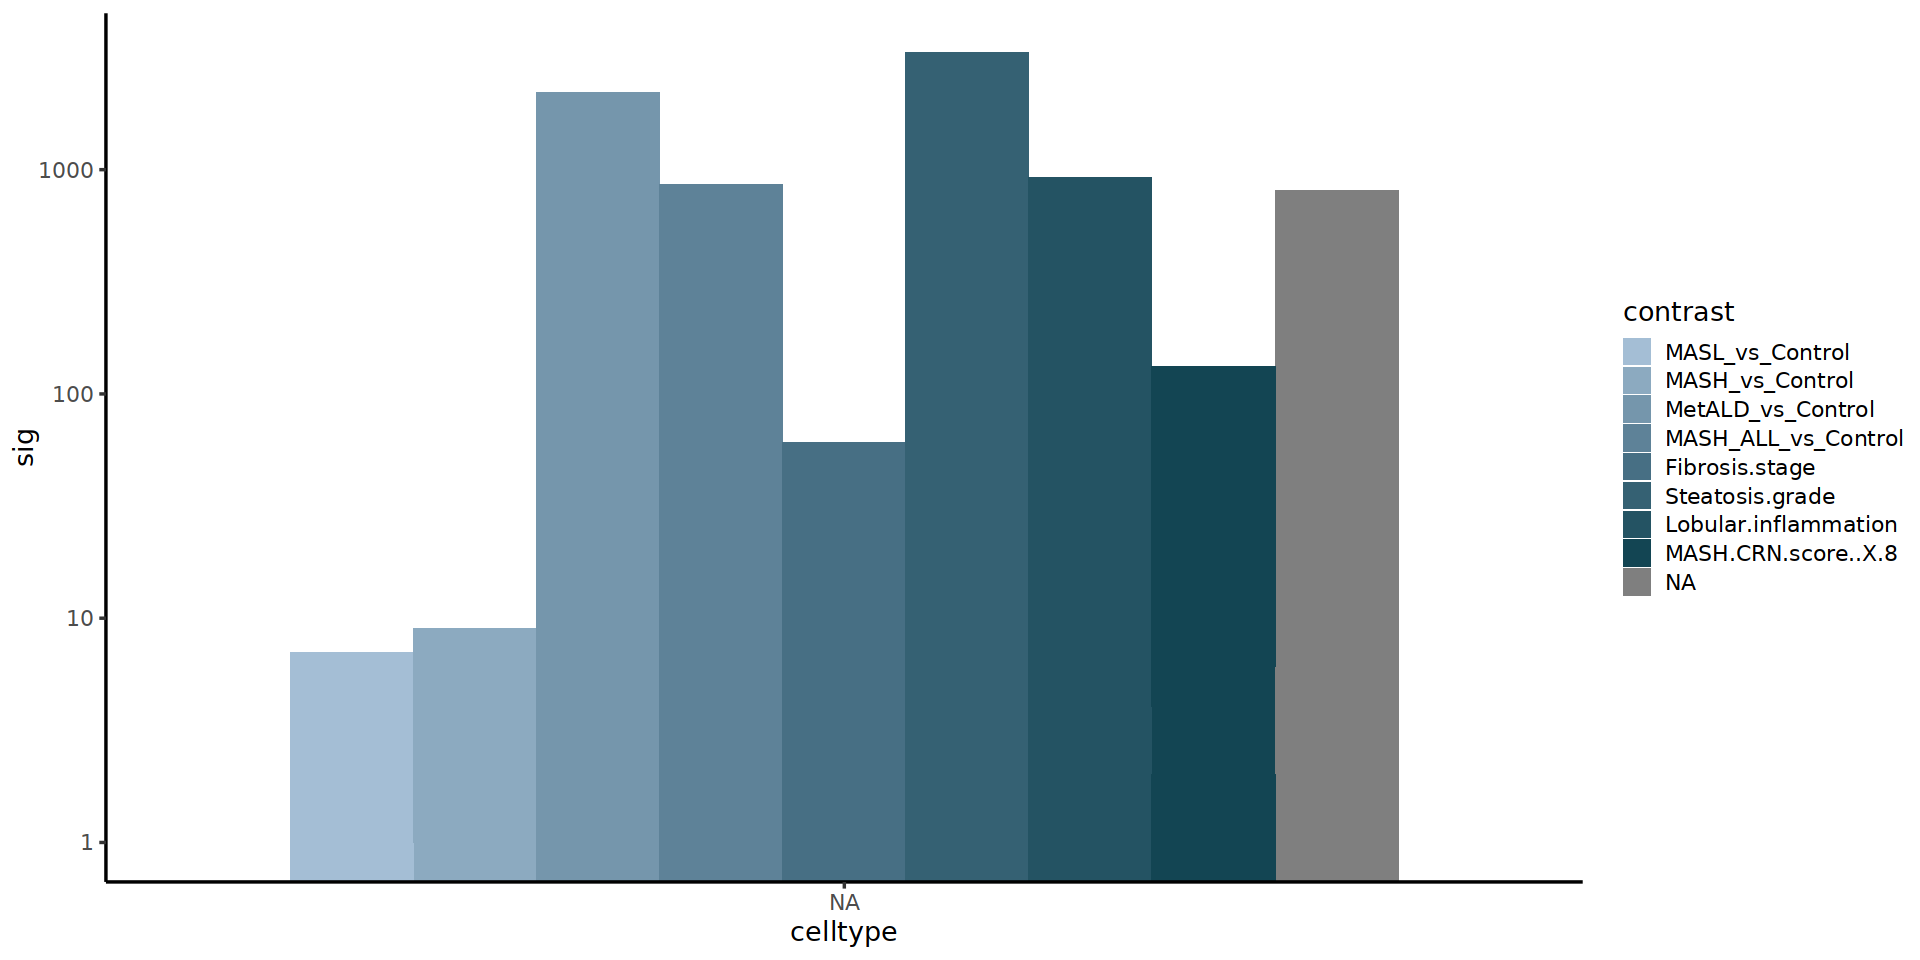

In [131]:
library(nationalparkcolors)

options(repr.plot.width=16, repr.plot.height=8)

ggplot(select(deseq.stats2, -up_pval, -down_pval) %>%
    pivot_longer(c(up_padj, down_padj), values_to = 'sig',names_to = 'direction'),
       aes(x=celltype, fill=contrast, y=sig)) + geom_col(position = 'dodge') +
    scale_y_log10() +
    theme_classic(base_size=16) + scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(length(unique(deseq.stats2$contrast))))

In [132]:
length(unique(deseq.stats2$contrast))

[1] 9

In [133]:
contrasts  <- c('Age','Age.scaled')


# Define the DESeq2 formula
deseq.base.formula <- '~ Fibrosis.stage + BMI.scaled + batch + Gender'

In [134]:
#deseq.stats = NULL

for (i in seq_along(files)) {
    file.use = files[i]
    cell.use = cells[i]
    
    if(cell.use %in% c('Bulk')) {
        next
    }
    
    print(paste0("Analyzing: ", cell.use))
    raw_counts <- read.table(paste0(dir, file.use), header = TRUE, row.names = 1)
    #colnames(raw_counts) <- str_remove(colnames(raw_counts), paste0(cell.use, '.'))
    # Remove low bc cells
    #raw_counts <- raw_counts[colnames(raw_counts) %in% meta$donor_demux[meta[[cell.use]] > 10]]
    # Filter for only samples with any counts in the cell type rowSums(raw_counts == 0)
    raw_counts = raw_counts[, (colSums(raw_counts >= 0) > 0)]
    # Subset samples to make one feature with counts in every sample
    best.row <- raw_counts[which(rowSums(raw_counts!=0) == max(rowSums(raw_counts != 0))),][1,]
    raw_counts <- raw_counts[colnames(raw_counts) %in% colnames(best.row)[best.row != 0]]
    print(dim(raw_counts))
    
    message("Donors detectected with celltype: ", ncol(raw_counts))
    if(ncol(raw_counts) == 0) {
        next
    }
    
    meta_cell <- subset(meta, donor %in% colnames(raw_counts))
    rownames(meta_cell) = meta_cell$donor
    message("Subsetting metadata accordingly - Check that value is equal to above: ", nrow(meta_cell))
    meta_cell <- meta_cell[match(colnames(raw_counts), rownames(meta_cell)), ]
    
    for (contrast in contrasts) {
        contrast.use <- contrast
        message("  - ", contrast.use)

        # Create vectors of samples for each condition
        samples <- meta_cell %>%  
                   pull(donor)
        
        if(length(samples) < 3) {
            next
        }
        
        # Subset meta_cell for the current contrast
        meta_cell.use <- meta_cell %>% 
                     dplyr::filter(donor %in% c(samples)) 
        rownames(meta_cell.use) <- meta_cell.use$donor
        
        # Subset raw_counts for the donors in meta_cell
        raw_counts_subset <- raw_counts[, colnames(raw_counts) %in% rownames(meta_cell.use)]

        # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
        meta_cell.use <- meta_cell.use[match(colnames(raw_counts_subset), rownames(meta_cell.use)), ]
        
        # Check if enough samples are present for both conditions
        if (length(unique(meta_cell.use[[contrast.use]])) >= 2) {
            deseq.stats.tmp <- data.frame()
            
            if (is.null(nrow(raw_counts_subset))) {
                next
            }
            
            # Light pre-filtering
            counts_filtered <- raw_counts_subset[rowSums(raw_counts_subset) >= 10,]
            
            if (nrow(counts_filtered) < 3) {
                next
            }

            # Run DESeq2 with a check for full rank
            tryCatch({
                deseq.formula <- as.formula(paste0(deseq.base.formula,'+',contrast.use))
                
                
                dds <- DESeqDataSetFromMatrix(countData = round(counts_filtered),
                                              colData = meta_cell.use, 
                                              design = deseq.formula)
                
                # DESeq analysis
                dds <- DESeq(dds)
                dds.results <- results(dds)
                
                # Write DESeq results to file
                write.table(dds.results, 
                    file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                    sep = '\t', quote = FALSE)
                
                dds.results <- na.omit(dds.results[order(dds.results$padj), ])
                
                # Write DESeq results to file
                write.table(dds.results, 
                            file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                            sep = '\t', quote = FALSE)
                
                # Collect summary statistics
                deseq.stats.tmp <- data.frame(
                    celltype = cell.use,
                    contrast = contrast.use,
                    up_pval = sum(dds.results$log2FoldChange > 0 & dds.results$pvalue < 0.05),
                    down_pval = sum(dds.results$log2FoldChange < 0 & dds.results$pvalue < 0.05),
                    up_padj = sum(dds.results$log2FoldChange > 0 & dds.results$padj < 0.1),
                    down_padj = sum(dds.results$log2FoldChange < 0 & dds.results$padj < 0.1))
                deseq.stats <- rbind(deseq.stats, deseq.stats.tmp)
                
                             # Make Volcano plot - Padj
                            res = as.data.frame(dds.results)
                            res$SYMBOL = rownames(res)
                            res = res %>%
                            dplyr::filter(!is.na(SYMBOL)) %>%
                            dplyr::filter(padj < 0.1) %>%
                            dplyr::group_by(sign(log2FoldChange)) %>%
                            dplyr::mutate(rank = abs(log2FoldChange) * -log10(padj)) %>%
                            dplyr::top_n(50, rank) %>%
                            dplyr::mutate(delabel = SYMBOL) %>%
                            ungroup() %>%
                            dplyr::select(delabel, SYMBOL) %>%
                            right_join(res) %>%
                            dplyr::mutate(delabel = if_else(is.na(delabel), "", as.character(delabel))) 

                            # Add a new column for color based on significance and direction
                            res$changes <- ifelse(res$log2FoldChange > 0 & res$padj < 0.1, "Up-regulated",
                                                ifelse(res$log2FoldChange < 0 & res$padj < 0.1, "Down-regulated", "NS"))
                            # Get the number of upregulated and downregulated genes
                            n_up <- sum(res$changes == "Up-regulated")
                            n_down <- sum(res$changes == "Down-regulated")

                            # Modify log2FoldChange values to be max x
                            res$log2FoldChange[res$log2FoldChange > 10] <- 10
                            res$log2FoldChange[res$log2FoldChange < -10] <- -10
                            # Modify padj values to be max x 
                            res$padj[res$padj < 10^-200] <- 10^-200
                    
                            plot = ggplot(res, aes(x=log2FoldChange, y=-log10(padj), label=delabel, color=changes)) +
                                theme_bw() +
                                labs(y="-log10(padj)", x="log2FoldChange", 
                                   title=paste(cell.use, " - ",
                                               contrast.use, "\n",
                                              "Up: ", n_up, "-",
                                               "Down: ", n_down)) +
                                geom_point() +
                                scale_color_manual(values=c("blue", "grey", "red")) + 
                                theme(axis.text=element_text(size=16), axis.title=element_text(size=16, face="bold"),
                                    axis.text.x=element_text(), plot.title=element_text(size=18, face="bold", hjust=0.5)) +
                                scale_x_continuous(breaks=c(-10, -5, 0, 5, 10),
                                            labels=c("< -10", "-5", "0", "5", "> 10"), lim = c(-10, 10))+
                                scale_y_continuous(breaks=c(0, 20, 40, 60, 80, 100, 200),
                                            labels=c("0", "20", "40", "60", "80", "100", ">200"))+
                                geom_text_repel(label=res$delabel, size=3.5, max.overlaps=10,
                                              point.padding=0, min.segment.length=0,
                                              max.time=20, max.iter=1e5, box.padding=0.3)
                    
                            ggsave(filename = paste0(outdir, cell.use, "_", contrast.use, ".volcanoPlot.pdf"),
                                   height = 10, width = 10,
                                   plot = plot, device = "pdf")

            }, error = function(e) {
                message(paste0("Skipping contrast ", contrast.use, ": ", e$message))
            })
        } else {
            message("Not enough samples for contrast: ", contrast.use)
        }
    }
}


[1] "Analyzing: Hepatocytes.Senescent"
[1] 191678     56


Donors detectected with celltype: 56

Subsetting metadata accordingly - Check that value is equal to above: 56

  - Age

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-disper

[1] "Analyzing: Hepatocytes.Stress"
[1] 191678     15


Donors detectected with celltype: 15

Subsetting metadata accordingly - Check that value is equal to above: 15

  - Age

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-disper

[1] "Analyzing: Hepatocytes.Zone1"
[1] 191678     48


Donors detectected with celltype: 48

Subsetting metadata accordingly - Check that value is equal to above: 48

  - Age

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-disper

[1] "Analyzing: Hepatocytes.Zone2"
[1] 191678     37


Donors detectected with celltype: 37

Subsetting metadata accordingly - Check that value is equal to above: 37

  - Age

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-disper

[1] "Analyzing: Hepatocytes.Zone3"
[1] 191678     69


Donors detectected with celltype: 69

Subsetting metadata accordingly - Check that value is equal to above: 69

  - Age

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-disper

In [135]:
deseq.stats

celltype,contrast,up_pval,down_pval,up_padj,down_padj
<chr>,<chr>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,MASL_vs_Control,2635,27,0,7
Hepatocytes.Senescent,MASH_vs_Control,4916,23,1,0
Hepatocytes.Senescent,MetALD_vs_Control,10026,25,2201,2
Hepatocytes.Zone1,MASL_vs_Control,913,1103,0,2
Hepatocytes.Zone1,MASH_vs_Control,297,3381,0,2
Hepatocytes.Zone1,MetALD_vs_Control,2044,981,1,4
Hepatocytes.Zone2,MASL_vs_Control,3077,573,0,0
Hepatocytes.Zone2,MASH_vs_Control,1667,491,0,6
Hepatocytes.Zone2,MetALD_vs_Control,1027,845,3,20


In [136]:
mutate(deseq.stats, sig = up_padj + down_padj) %>%
    select(celltype, contrast, sig) %>%
    pivot_wider(names_from = contrast, values_from = sig)

celltype,MASL_vs_Control,MASH_vs_Control,MetALD_vs_Control,MASH_ALL_vs_Control,Fibrosis.stage,Steatosis.grade,Lobular.inflammation,MASH.CRN.score..X.8,Ballooning,Age,Age.scaled
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,7,1,2203,857,0,1820,0,32,NA,0,0
Hepatocytes.Zone1,2,2,5,0,0,0,0,0,NA,0,0
Hepatocytes.Zone2,0,6,23,0,0,2,4,4,6,0,0
Hepatocytes.Zone3,0,10,84,1,63,0,0,0,NA,0,0
Hepatocytes.Stress,NA,NA,NA,NA,1,4408,1048,163,837,17,2


In [137]:
deseq.stats2 <- deseq.stats

In [138]:
deseq.stats2$contrast <- factor(deseq.stats2$contrast, levels = c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control',"MASH_ALL_vs_Control",'Fibrosis.stage',
                                    'Steatosis.grade', 'Lobular.inflammation', 'MASH.CRN.score..X.8', 'Age.scaled', 'BMI.scaled'))
deseq.stats2$celltype <- factor(deseq.stats2$celltype, levels = paste0(names(sort(colSums(meta[,2:11]), decreasing = T))))                           

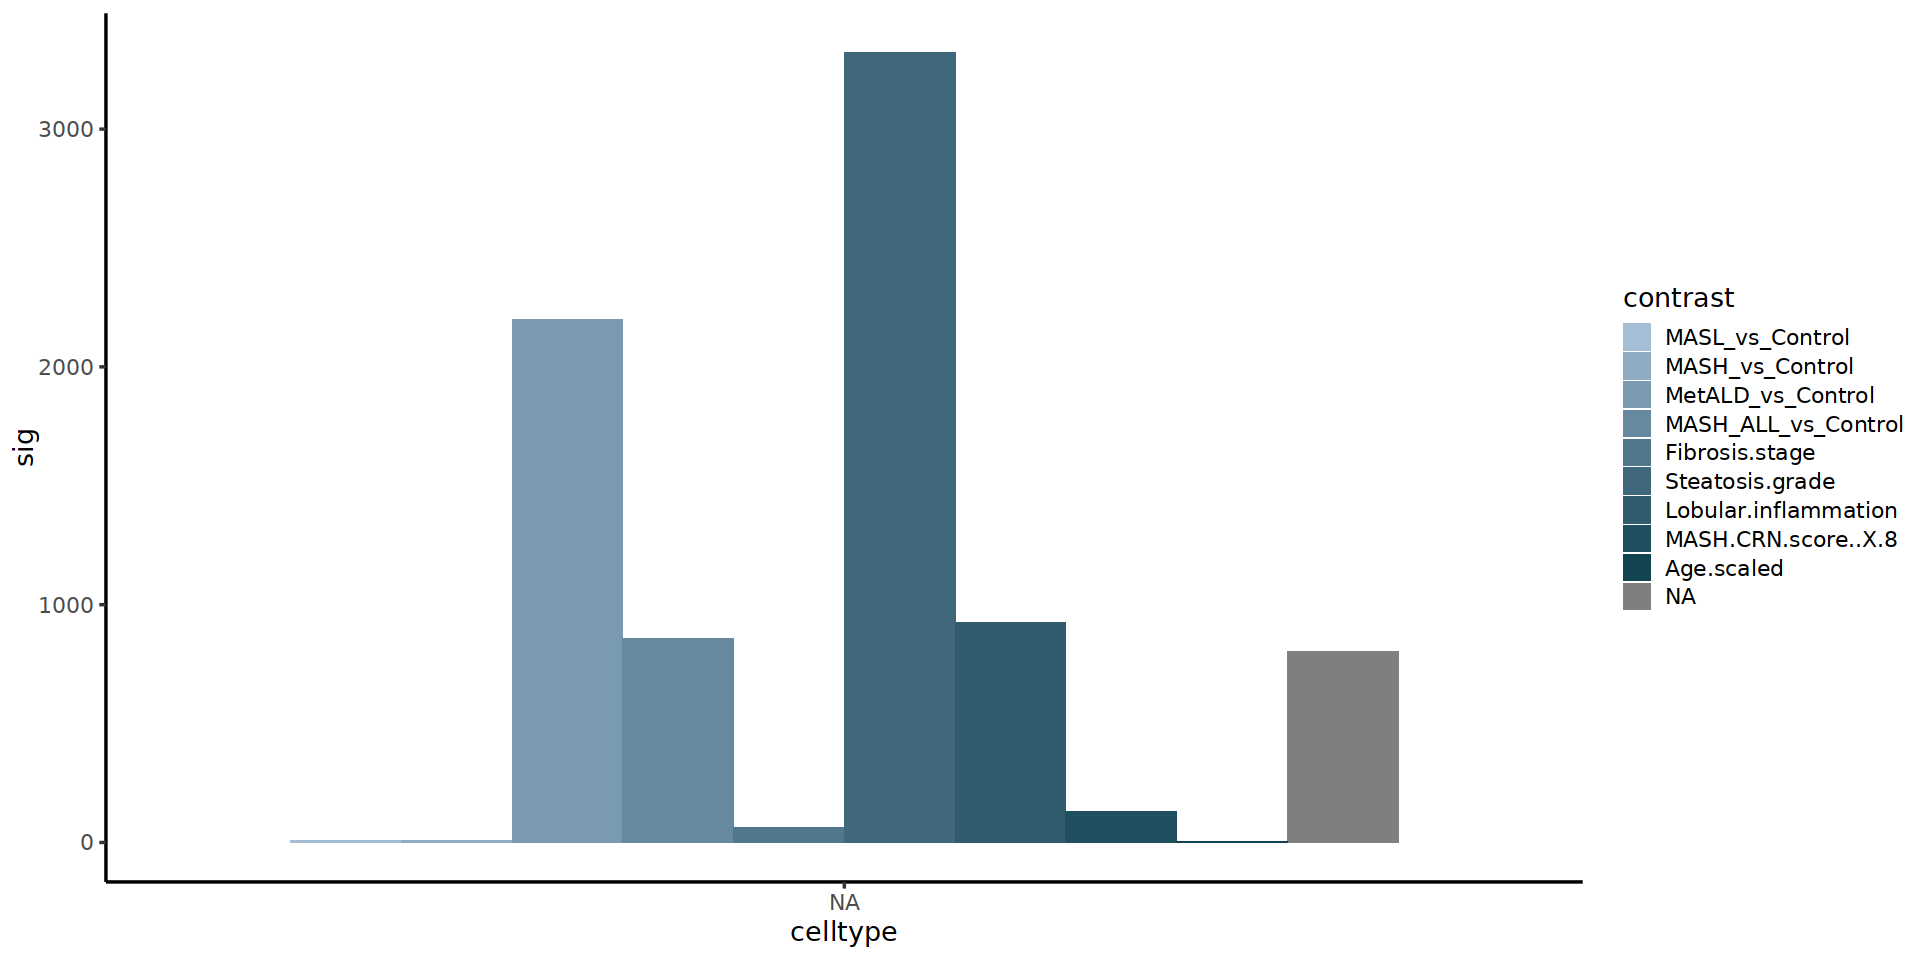

In [139]:
library(nationalparkcolors)

options(repr.plot.width=16, repr.plot.height=8)

ggplot(select(deseq.stats2, -up_pval, -down_pval) %>%
    pivot_longer(c(up_padj, down_padj), values_to = 'sig',names_to = 'direction'),
       aes(x=celltype, fill=contrast, y=sig)) + geom_col(position = 'dodge') +
    theme_classic(base_size=16) + scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(length(levels(deseq.stats2$contrast))))

In [140]:
contrasts  <- c('BMI','BMI.scaled')


# Define the DESeq2 formula
deseq.base.formula <- '~ Fibrosis.stage + Age.scaled + batch + Gender'

In [141]:
#deseq.stats = NULL

for (i in seq_along(files)) {
    file.use = files[i]
    cell.use = cells[i]
    
    if(cell.use %in% c('Bulk')) {
        next
    }
    
    print(paste0("Analyzing: ", cell.use))
    raw_counts <- read.table(paste0(dir, file.use), header = TRUE, row.names = 1)
    #colnames(raw_counts) <- str_remove(colnames(raw_counts), paste0(cell.use, '.'))
    # Remove low bc cells
    #raw_counts <- raw_counts[colnames(raw_counts) %in% meta$donor_demux[meta[[cell.use]] > 10]]
    # Filter for only samples with any counts in the cell type rowSums(raw_counts == 0)
    raw_counts = raw_counts[, (colSums(raw_counts >= 0) > 0)]
    # Subset samples to make one feature with counts in every sample
    best.row <- raw_counts[which(rowSums(raw_counts!=0) == max(rowSums(raw_counts != 0))),][1,]
    raw_counts <- raw_counts[colnames(raw_counts) %in% colnames(best.row)[best.row != 0]]
    print(dim(raw_counts))
    
    message("Donors detectected with celltype: ", ncol(raw_counts))
    if(ncol(raw_counts) == 0) {
        next
    }
    
    meta_cell <- subset(meta, donor %in% colnames(raw_counts))
    rownames(meta_cell) = meta_cell$donor
    message("Subsetting metadata accordingly - Check that value is equal to above: ", nrow(meta_cell))
    meta_cell <- meta_cell[match(colnames(raw_counts), rownames(meta_cell)), ]
    
    for (contrast in contrasts) {
        contrast.use <- contrast
        message("  - ", contrast.use)

        # Create vectors of samples for each condition
        samples <- meta_cell %>%  
                   pull(donor)
        
        if(length(samples) < 3) {
            next
        }
        
        # Subset meta_cell for the current contrast
        meta_cell.use <- meta_cell %>% 
                     dplyr::filter(donor %in% c(samples)) 
        rownames(meta_cell.use) <- meta_cell.use$donor
        
        # Subset raw_counts for the donors in meta_cell
        raw_counts_subset <- raw_counts[, colnames(raw_counts) %in% rownames(meta_cell.use)]

        # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
        meta_cell.use <- meta_cell.use[match(colnames(raw_counts_subset), rownames(meta_cell.use)), ]
        
        # Check if enough samples are present for both conditions
        if (length(unique(meta_cell.use[[contrast.use]])) >= 2) {
            deseq.stats.tmp <- data.frame()
            
            if (is.null(nrow(raw_counts_subset))) {
                next
            }
            
            # Light pre-filtering
            counts_filtered <- raw_counts_subset[rowSums(raw_counts_subset) >= 10,]
            
            if (nrow(counts_filtered) < 3) {
                next
            }

            # Run DESeq2 with a check for full rank
            tryCatch({
                deseq.formula <- as.formula(paste0(deseq.base.formula,'+',contrast.use))
                
                
                dds <- DESeqDataSetFromMatrix(countData = round(counts_filtered),
                                              colData = meta_cell.use, 
                                              design = deseq.formula)
                
                # DESeq analysis
                dds <- DESeq(dds)
                dds.results <- results(dds)
                
                # Write DESeq results to file
                write.table(dds.results, 
                    file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                    sep = '\t', quote = FALSE)
                
                dds.results <- na.omit(dds.results[order(dds.results$padj), ])
                
                # Write DESeq results to file
                write.table(dds.results, 
                            file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                            sep = '\t', quote = FALSE)
                
                # Collect summary statistics
                deseq.stats.tmp <- data.frame(
                    celltype = cell.use,
                    contrast = contrast.use,
                    up_pval = sum(dds.results$log2FoldChange > 0 & dds.results$pvalue < 0.05),
                    down_pval = sum(dds.results$log2FoldChange < 0 & dds.results$pvalue < 0.05),
                    up_padj = sum(dds.results$log2FoldChange > 0 & dds.results$padj < 0.1),
                    down_padj = sum(dds.results$log2FoldChange < 0 & dds.results$padj < 0.1))
                deseq.stats <- rbind(deseq.stats, deseq.stats.tmp)
                
                             # Make Volcano plot - Padj
                            res = as.data.frame(dds.results)
                            res$SYMBOL = rownames(res)
                            res = res %>%
                            dplyr::filter(!is.na(SYMBOL)) %>%
                            dplyr::filter(padj < 0.1) %>%
                            dplyr::group_by(sign(log2FoldChange)) %>%
                            dplyr::mutate(rank = abs(log2FoldChange) * -log10(padj)) %>%
                            dplyr::top_n(50, rank) %>%
                            dplyr::mutate(delabel = SYMBOL) %>%
                            ungroup() %>%
                            dplyr::select(delabel, SYMBOL) %>%
                            right_join(res) %>%
                            dplyr::mutate(delabel = if_else(is.na(delabel), "", as.character(delabel))) 

                            # Add a new column for color based on significance and direction
                            res$changes <- ifelse(res$log2FoldChange > 0 & res$padj < 0.1, "Up-regulated",
                                                ifelse(res$log2FoldChange < 0 & res$padj < 0.1, "Down-regulated", "NS"))
                            # Get the number of upregulated and downregulated genes
                            n_up <- sum(res$changes == "Up-regulated")
                            n_down <- sum(res$changes == "Down-regulated")

                            # Modify log2FoldChange values to be max x
                            res$log2FoldChange[res$log2FoldChange > 10] <- 10
                            res$log2FoldChange[res$log2FoldChange < -10] <- -10
                            # Modify padj values to be max x 
                            res$padj[res$padj < 10^-200] <- 10^-200
                    
                            plot = ggplot(res, aes(x=log2FoldChange, y=-log10(padj), label=delabel, color=changes)) +
                                theme_bw() +
                                labs(y="-log10(padj)", x="log2FoldChange", 
                                   title=paste(cell.use, " - ",
                                               contrast.use, "\n",
                                              "Up: ", n_up, "-",
                                               "Down: ", n_down)) +
                                geom_point() +
                                scale_color_manual(values=c("blue", "grey", "red")) + 
                                theme(axis.text=element_text(size=16), axis.title=element_text(size=16, face="bold"),
                                    axis.text.x=element_text(), plot.title=element_text(size=18, face="bold", hjust=0.5)) +
                                scale_x_continuous(breaks=c(-10, -5, 0, 5, 10),
                                            labels=c("< -10", "-5", "0", "5", "> 10"), lim = c(-10, 10))+
                                scale_y_continuous(breaks=c(0, 20, 40, 60, 80, 100, 200),
                                            labels=c("0", "20", "40", "60", "80", "100", ">200"))+
                                geom_text_repel(label=res$delabel, size=3.5, max.overlaps=10,
                                              point.padding=0, min.segment.length=0,
                                              max.time=20, max.iter=1e5, box.padding=0.3)
                    
                            ggsave(filename = paste0(outdir, cell.use, "_", contrast.use, ".volcanoPlot.pdf"),
                                   height = 10, width = 10,
                                   plot = plot, device = "pdf")

            }, error = function(e) {
                message(paste0("Skipping contrast ", contrast.use, ": ", e$message))
            })
        } else {
            message("Not enough samples for contrast: ", contrast.use)
        }
    }
}


[1] "Analyzing: Hepatocytes.Senescent"
[1] 191678     56


Donors detectected with celltype: 56

Subsetting metadata accordingly - Check that value is equal to above: 56

  - BMI

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-disper

[1] "Analyzing: Hepatocytes.Stress"
[1] 191678     15


Donors detectected with celltype: 15

Subsetting metadata accordingly - Check that value is equal to above: 15

  - BMI

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-disper

[1] "Analyzing: Hepatocytes.Zone1"
[1] 191678     48


Donors detectected with celltype: 48

Subsetting metadata accordingly - Check that value is equal to above: 48

  - BMI

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-disper

[1] "Analyzing: Hepatocytes.Zone2"
[1] 191678     37


Donors detectected with celltype: 37

Subsetting metadata accordingly - Check that value is equal to above: 37

  - BMI

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-disper

[1] "Analyzing: Hepatocytes.Zone3"
[1] 191678     69


Donors detectected with celltype: 69

Subsetting metadata accordingly - Check that value is equal to above: 69

  - BMI

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-disper

In [142]:
deseq.stats

celltype,contrast,up_pval,down_pval,up_padj,down_padj
<chr>,<chr>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,MASL_vs_Control,2635,27,0,7
Hepatocytes.Senescent,MASH_vs_Control,4916,23,1,0
Hepatocytes.Senescent,MetALD_vs_Control,10026,25,2201,2
Hepatocytes.Zone1,MASL_vs_Control,913,1103,0,2
Hepatocytes.Zone1,MASH_vs_Control,297,3381,0,2
Hepatocytes.Zone1,MetALD_vs_Control,2044,981,1,4
Hepatocytes.Zone2,MASL_vs_Control,3077,573,0,0
Hepatocytes.Zone2,MASH_vs_Control,1667,491,0,6
Hepatocytes.Zone2,MetALD_vs_Control,1027,845,3,20


In [143]:
filter(deseq.stats, celltype=='Hepatocytes')

celltype,contrast,up_pval,down_pval,up_padj,down_padj
<chr>,<chr>,<int>,<int>,<int>,<int>


In [144]:
mutate(deseq.stats, sig = up_padj + down_padj) %>%
    select(celltype, contrast, sig) %>%
    pivot_wider(names_from = contrast, values_from = sig)

celltype,MASL_vs_Control,MASH_vs_Control,MetALD_vs_Control,MASH_ALL_vs_Control,Fibrosis.stage,Steatosis.grade,Lobular.inflammation,MASH.CRN.score..X.8,Ballooning,Age,Age.scaled,BMI,BMI.scaled
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,7,1,2203,857,0,1820,0,32,NA,0,0,0,0
Hepatocytes.Zone1,2,2,5,0,0,0,0,0,NA,0,0,0,0
Hepatocytes.Zone2,0,6,23,0,0,2,4,4,6,0,0,0,0
Hepatocytes.Zone3,0,10,84,1,63,0,0,0,NA,0,0,0,0
Hepatocytes.Stress,NA,NA,NA,NA,1,4408,1048,163,837,17,2,244,222


In [145]:
mutate(deseq.stats, sig = up_padj + down_padj) %>%
    select(celltype, contrast, sig) %>%
    pivot_wider(names_from = contrast, values_from = sig)

celltype,MASL_vs_Control,MASH_vs_Control,MetALD_vs_Control,MASH_ALL_vs_Control,Fibrosis.stage,Steatosis.grade,Lobular.inflammation,MASH.CRN.score..X.8,Ballooning,Age,Age.scaled,BMI,BMI.scaled
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,7,1,2203,857,0,1820,0,32,NA,0,0,0,0
Hepatocytes.Zone1,2,2,5,0,0,0,0,0,NA,0,0,0,0
Hepatocytes.Zone2,0,6,23,0,0,2,4,4,6,0,0,0,0
Hepatocytes.Zone3,0,10,84,1,63,0,0,0,NA,0,0,0,0
Hepatocytes.Stress,NA,NA,NA,NA,1,4408,1048,163,837,17,2,244,222


In [146]:
deseq.stats2 <- deseq.stats

In [147]:
deseq.stats2$contrast <- factor(deseq.stats2$contrast, levels = c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control',"MASH_ALL_vs_Control",'Fibrosis.stage',
                                    'Steatosis.grade', 'Lobular.inflammation', 'MASH.CRN.score..X.8', 'Age.scaled', 'BMI.scaled'))
deseq.stats2$celltype <- factor(deseq.stats2$celltype, levels = paste0(names(sort(colSums(meta[,2:11]), decreasing = T))))                           

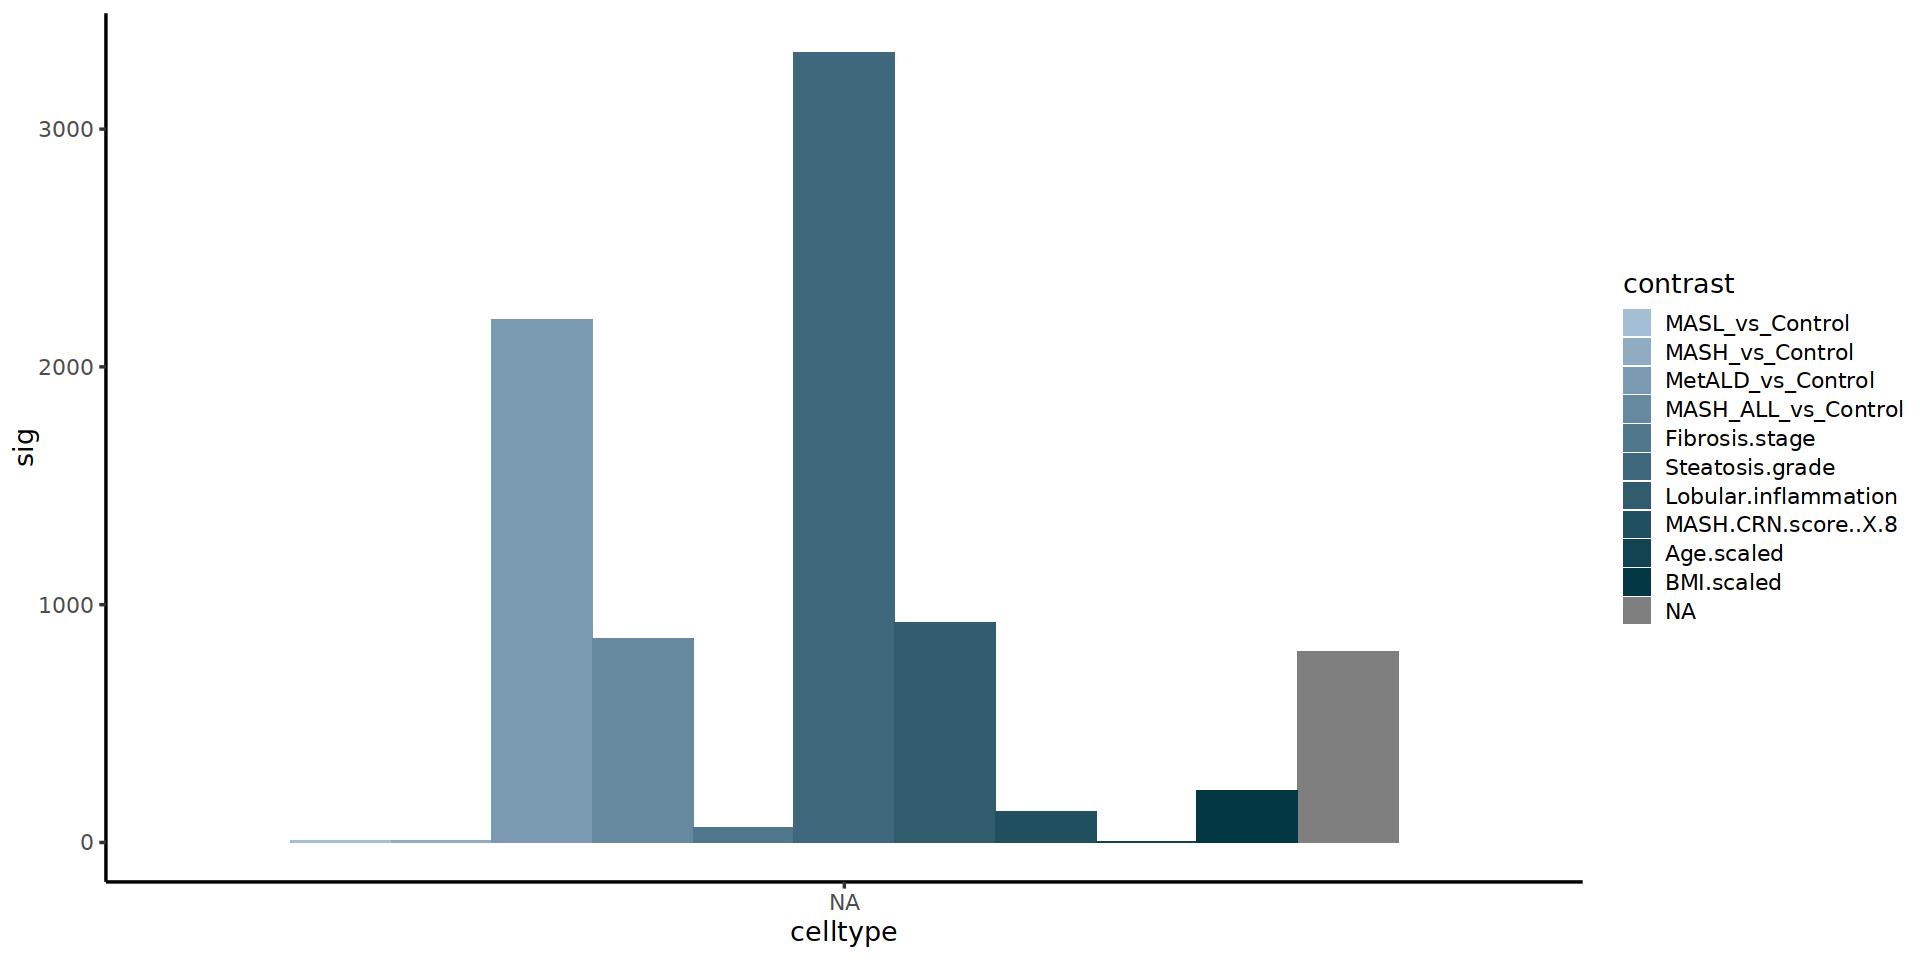

In [148]:
library(nationalparkcolors)

options(repr.plot.width=16, repr.plot.height=8)

ggplot(select(deseq.stats2, -up_pval, -down_pval) %>%
    pivot_longer(c(up_padj, down_padj), values_to = 'sig',names_to = 'direction'),
       aes(x=celltype, fill=contrast, y=sig)) + geom_col(position = 'dodge') +
    theme_classic(base_size=16) + scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(length(levels(deseq.stats2$contrast))))

In [149]:
write.table(deseq.stats, paste0(outdir, '241024_WE_deseq_summary_add_contrasts_v2.tsv'),
           col.names=T, row.names=T, quote=F, sep='\t')

In [150]:
deseq.stats2 <- deseq.stats
deseq.stats2$contrast <- factor(deseq.stats2$contrast, levels = c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control',"MASH_ALL_vs_Control",'Fibrosis.stage',
                                    'Steatosis.grade', 'Lobular.inflammation', 'MASH.CRN.score..X.8', 'Age.scaled', 'BMI.scaled'))
deseq.stats2$celltype <- factor(deseq.stats2$celltype, levels = paste0(names(sort(colSums(meta[,2:11]), decreasing = T))))                           

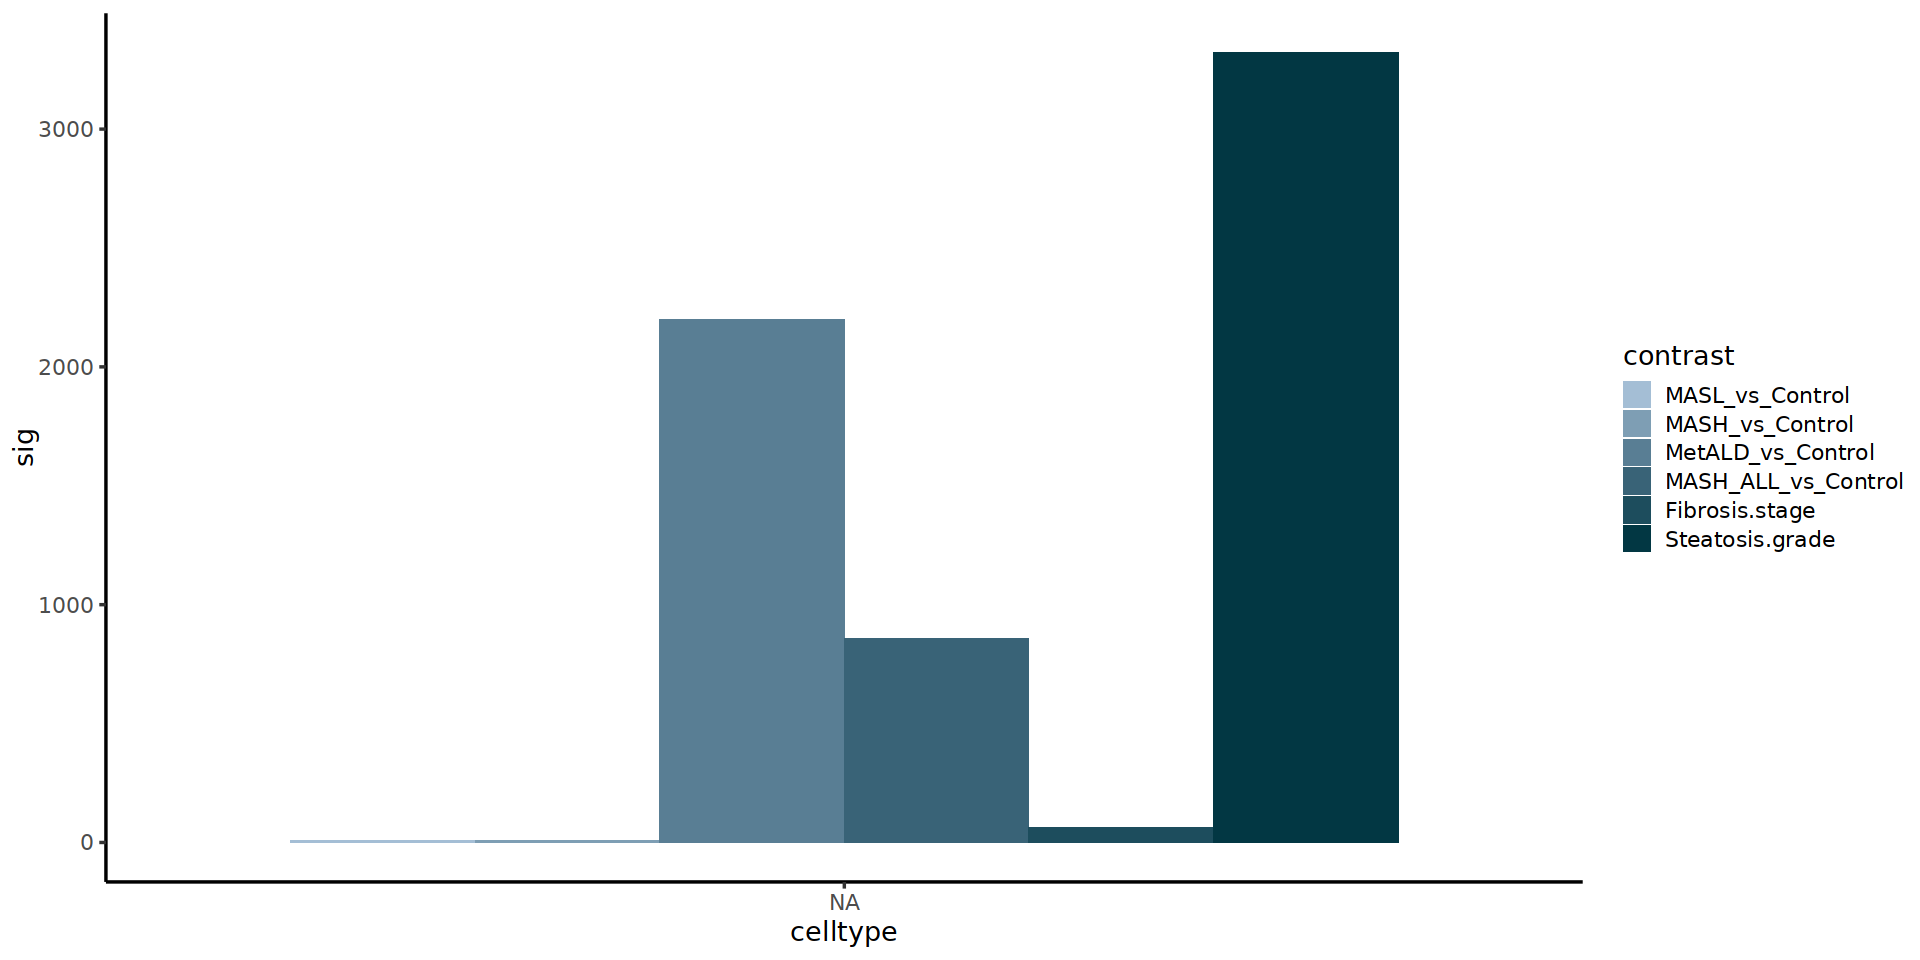

In [151]:
library(nationalparkcolors)

options(repr.plot.width=16, repr.plot.height=8)

ggplot(select(deseq.stats2, -up_pval, -down_pval) %>%
       filter(contrast %in% c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control',
                             'Fibrosis.stage','Steatosis.grade','MASH_ALL_vs_Control')) %>%
    pivot_longer(c(up_padj, down_padj), values_to = 'sig',names_to = 'direction'),
       aes(x=celltype, fill=contrast, y=sig)) + geom_col(position = 'dodge') +
    theme_classic(base_size=16) + scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(6))

Warning message in scale_y_log10():
“log-10 transformation introduced infinite values.”


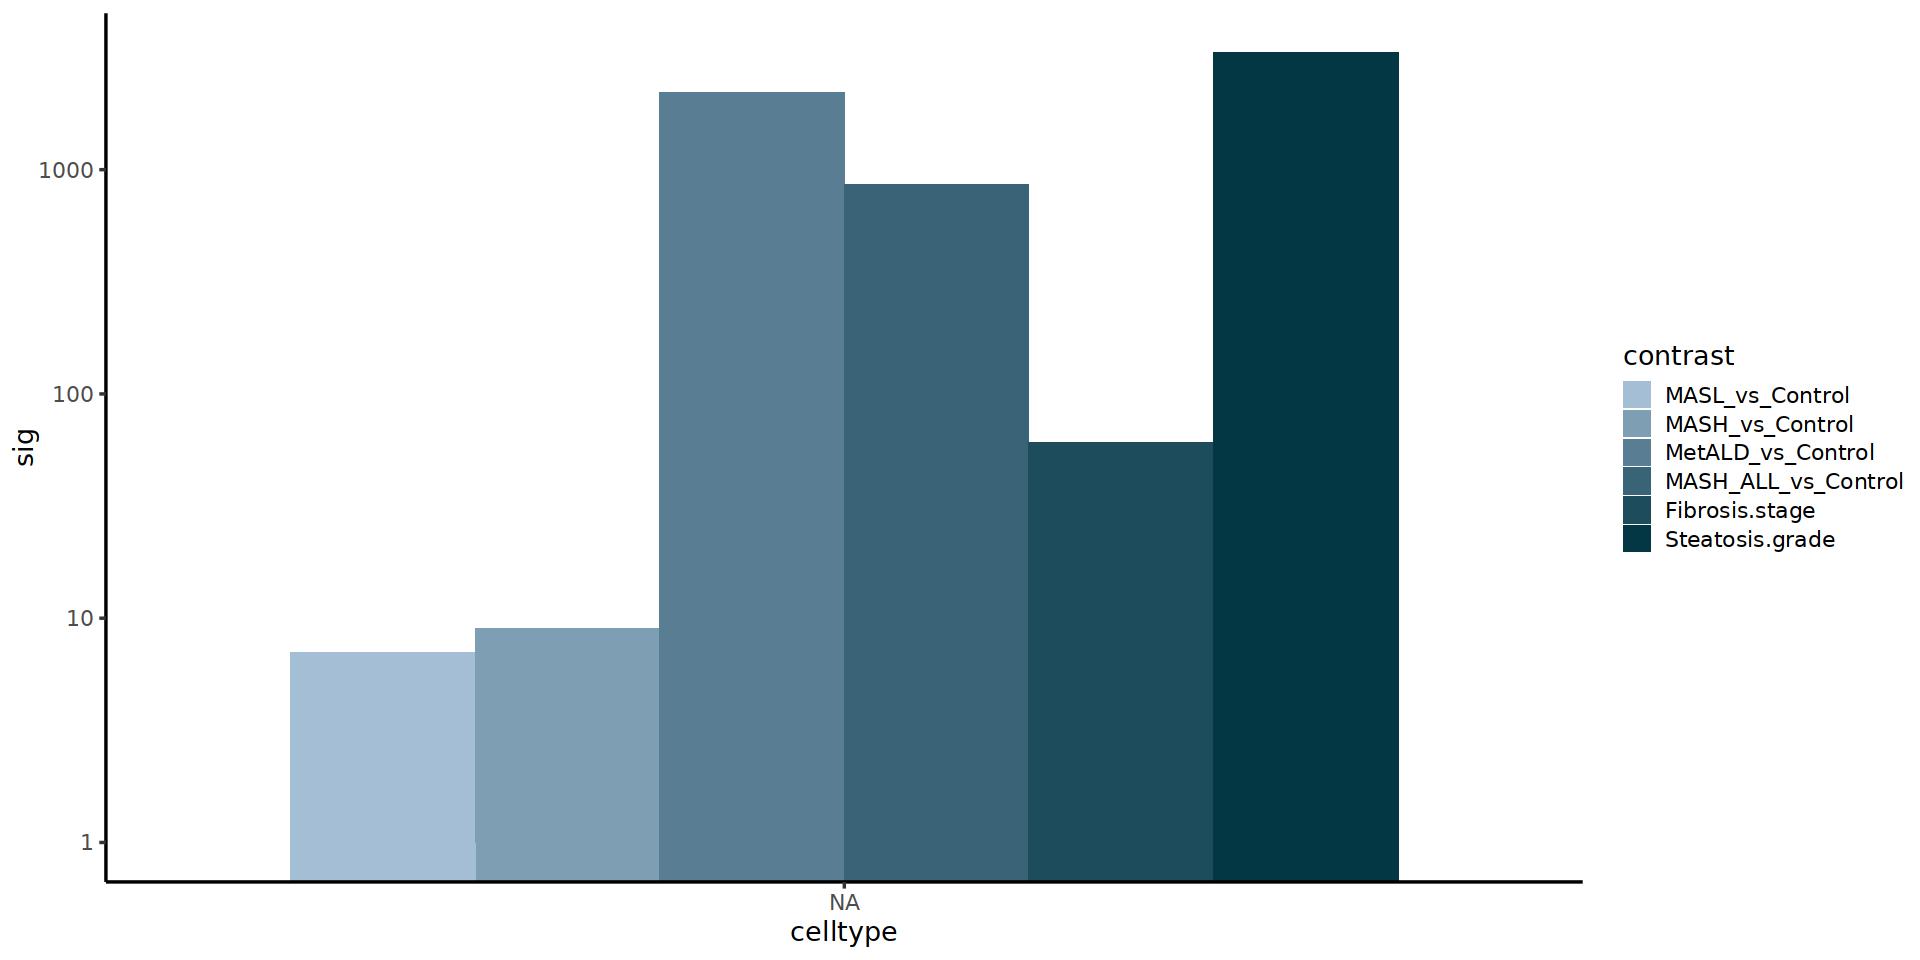

In [152]:
library(nationalparkcolors)

options(repr.plot.width=16, repr.plot.height=8)

ggplot(select(deseq.stats2, -up_pval, -down_pval) %>%
       filter(contrast %in% c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control',
                             'Fibrosis.stage','Steatosis.grade','MASH_ALL_vs_Control')) %>%
    pivot_longer(c(up_padj, down_padj), values_to = 'sig',names_to = 'direction'),
       aes(x=celltype, fill=contrast, y=sig)) + geom_col(position = 'dodge') +
    scale_y_log10() +
    theme_classic(base_size=16) + scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(6))

In [49]:
# List your contrasts  
conditions.1 = c("Low_Fibrosis", "High_Fibrosis") # disease
conditions.2 = c("Control", "Control") # control
contrasts = c(paste0(conditions.1, "_vs_", conditions.2))

# Write your formual
deseq.formula <- as.formula('~ Age.scaled + BMI.scaled + batch + Gender + condition') # last variable is the testing variable

In [50]:
unique(meta$condition)

[1] "MASL"    "MASH"    "MetALD"  "Control"

In [51]:
seq_along(files)

[1] 1 2 3 4 5 6 7

In [55]:
files <- files[str_detect(files, 'Hep')]
cells <- cells[str_detect(cells, 'Hep')]
files
cells

[1] "Hepatocytes.Senescent.tsv" "Hepatocytes.Stress.tsv"   
[3] "Hepatocytes.Zone1.tsv"     "Hepatocytes.Zone2.tsv"    
[5] "Hepatocytes.Zone3.tsv"

[1] "Hepatocytes.Senescent" "Hepatocytes.Stress"    "Hepatocytes.Zone1"    
[4] "Hepatocytes.Zone2"     "Hepatocytes.Zone3"

In [57]:
#deseq.stats = NULL

for (i in seq_along(files)) {
    file.use = files[i]
    cell.use = cells[i]
    if(cell.use %in% c('Bulk')) {
        next
    }
    
    print(paste0("Analyzing: ", cell.use))
    raw_counts <- read.table(paste0(dir, file.use), header = TRUE, row.names = 1)
    #colnames(raw_counts) <- str_remove(colnames(raw_counts), paste0(cell.use, '.'))
    # Remove low bc cells
    #raw_counts <- raw_counts[colnames(raw_counts) %in% meta$donor_demux[meta[[cell.use]] > 10]]
    # Filter for only samples with any counts in the cell type rowSums(raw_counts == 0)
    raw_counts = raw_counts[, (colSums(raw_counts >= 0) > 0)]
    # Subset samples to make one feature with counts in every sample
    best.row <- raw_counts[which(rowSums(raw_counts!=0) == max(rowSums(raw_counts != 0))),][1,]
    raw_counts <- raw_counts[colnames(raw_counts) %in% colnames(best.row)[best.row != 0]]
    print(dim(raw_counts))
    
    message("Donors detectected with celltype: ", ncol(raw_counts))
    if(ncol(raw_counts) == 0) {
        next
    }
    meta_cell <- subset(meta, donor %in% colnames(raw_counts))
    rownames(meta_cell) = meta_cell$donor
    message("subsetting metadata accordingly - Check that value is equal to above: ", nrow(meta_cell))
    # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
    meta_cell <- meta_cell[match(colnames(raw_counts), rownames(meta_cell)), ]
    
    for (c.i in seq_along(contrasts)) {
        contrast.use = contrasts[c.i]
        condition.1 = conditions.1[c.i]
        condition.2 = conditions.2[c.i]
        message("  - ", contrast.use)

        # Create vectors of samples for each condition
        if (condition.1 == 'Low_Fibrosis') {
            samples.condition.1 <- meta_cell %>% 
                               dplyr::filter(condition %in% c('MASH','MetALD') & Fibrosis.stage <= 2) %>% 
                               pull(donor)
        } else {
            samples.condition.1 <- meta_cell %>% 
                               dplyr::filter(condition %in% c('MASH','MetALD') & Fibrosis.stage >= 3) %>% 
                               pull(donor)
        }
        samples.condition.2 <- meta_cell %>% 
                               dplyr::filter(condition %in% condition.2) %>% 
                               pull(donor)
        
        if(length(samples.condition.1) < 3) {
            next
        }
        if(length(samples.condition.2) < 3) {
            next
        }
        
        # Subset meta_cell for the current contrast
        meta_cell.use <- meta_cell %>% 
                     dplyr::filter(donor %in% c(samples.condition.1, samples.condition.2)) 
        rownames(meta_cell.use) <- meta_cell.use$donor
        
        # Subset raw_counts for the donors in meta_cell
        raw_counts_subset <- raw_counts[, colnames(raw_counts) %in% rownames(meta_cell.use)]

        # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
        meta_cell.use <- meta_cell.use[match(colnames(raw_counts_subset), rownames(meta_cell.use)), ]
        
        # Check if enough samples are present for both conditions
        if (length(unique(meta_cell.use$condition)) >= 2) {
            deseq.stats.tmp <- data.frame()
            
            # Light pre-filtering
            counts_filtered <- raw_counts_subset[rowSums(raw_counts_subset) >= 10,]

            # Run DESeq2
            tryCatch({
            dds <- DESeqDataSetFromMatrix(countData = round(counts_filtered),
                                              colData = meta_cell.use, 
                                              design = deseq.formula)
            dds$condition <- relevel(dds$condition, ref = condition.2)
            dds <- DESeq(dds)
            dds.results <- results(dds)
                
            # Write DESeq results to file
            write.table(dds.results, 
                        file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                        sep = '\t', quote = FALSE)
                
            dds.results <- na.omit(dds.results[order(dds.results$padj), ])

            # Write DESeq results to file
            write.table(dds.results, 
                        file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                        sep = '\t', quote = FALSE)
            
            # Collect summary statistics
            deseq.stats.tmp <- data.frame(
                celltype = cell.use,
                contrast = contrast.use,
                up_pval = sum(dds.results$log2FoldChange > 0 & dds.results$pvalue < 0.05),
                down_pval = sum(dds.results$log2FoldChange < 0 & dds.results$pvalue < 0.05),
                up_padj = sum(dds.results$log2FoldChange > 0 & dds.results$padj < 0.1),
                down_padj = sum(dds.results$log2FoldChange < 0 & dds.results$padj < 0.1))
                deseq.stats <- rbind(deseq.stats, deseq.stats.tmp)

                           # Make Volcano plot - Padj
                            res = as.data.frame(dds.results)
                            res$SYMBOL = rownames(res)
                            res = res %>%
                            dplyr::filter(!is.na(SYMBOL)) %>%
                            dplyr::filter(padj < 0.1) %>%
                            dplyr::group_by(sign(log2FoldChange)) %>%
                            dplyr::mutate(rank = abs(log2FoldChange) * -log10(padj)) %>%
                            dplyr::top_n(50, rank) %>%
                            dplyr::mutate(delabel = SYMBOL) %>%
                            ungroup() %>%
                            dplyr::select(delabel, SYMBOL) %>%
                            right_join(res) %>%
                            dplyr::mutate(delabel = if_else(is.na(delabel), "", as.character(delabel))) 

                            # Add a new column for color based on significance and direction
                            res$changes <- ifelse(res$log2FoldChange > 0 & res$padj < 0.1, "Up-regulated",
                                                ifelse(res$log2FoldChange < 0 & res$padj < 0.1, "Down-regulated", "NS"))
                            # Get the number of upregulated and downregulated genes
                            n_up <- sum(res$changes == "Up-regulated")
                            n_down <- sum(res$changes == "Down-regulated")

                            # Modify log2FoldChange values to be max x
                            res$log2FoldChange[res$log2FoldChange > 10] <- 10
                            res$log2FoldChange[res$log2FoldChange < -10] <- -10
                            # Modify padj values to be max x 
                            res$padj[res$padj < 10^-200] <- 10^-200
                    
                            plot = ggplot(res, aes(x=log2FoldChange, y=-log10(padj), label=delabel, color=changes)) +
                                theme_bw() +
                                labs(y="-log10(padj)", x="log2FoldChange", 
                                   title=paste(cell.use, " - ",
                                               condition.1, "Vs", condition.2, "\n",
                                              "Up: ", n_up, "-",
                                               "Down: ", n_down)) +
                                geom_point() +
                                scale_color_manual(values=c("blue", "grey", "red")) + 
                                theme(axis.text=element_text(size=16), axis.title=element_text(size=16, face="bold"),
                                    axis.text.x=element_text(), plot.title=element_text(size=18, face="bold", hjust=0.5)) +
                                scale_x_continuous(breaks=c(-10, -5, 0, 5, 10),
                                            labels=c("< -10", "-5", "0", "5", "> 10"), lim = c(-10, 10))+
                                scale_y_continuous(breaks=c(0, 20, 40, 60, 80, 100, 200),
                                            labels=c("0", "20", "40", "60", "80", "100", ">200"))+
                                geom_text_repel(label=res$delabel, size=3.5, max.overlaps=10,
                                              point.padding=0, min.segment.length=0,
                                              max.time=20, max.iter=1e5, box.padding=0.3)
                    
                            ggsave(filename = paste0(outdir, cell.use, "_", contrast.use, ".volcanoPlot.pdf"),
                                   height = 10, width = 10,
                                   plot = plot, device = "pdf")
                #when it throws an error, the following block catches the error
                }, error = function(e) {
                message(paste0("Skipping contrast ", contrast.use, ": ", e$message))
            })
        } else {
            message("Not enough samples for contrast: ", contrast.use)
        }
    }
}

[1] "Analyzing: Hepatocytes.Senescent"
[1] 191678     56


Donors detectected with celltype: 56

subsetting metadata accordingly - Check that value is equal to above: 56

  - Low_Fibrosis_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion es

[1] "Analyzing: Hepatocytes.Stress"
[1] 191678     15


Donors detectected with celltype: 15

subsetting metadata accordingly - Check that value is equal to above: 15

  - Low_Fibrosis_vs_Control

  - High_Fibrosis_vs_Control



[1] "Analyzing: Hepatocytes.Zone1"
[1] 191678     48


Donors detectected with celltype: 48

subsetting metadata accordingly - Check that value is equal to above: 48

  - Low_Fibrosis_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion es

[1] "Analyzing: Hepatocytes.Zone2"
[1] 191678     37


Donors detectected with celltype: 37

subsetting metadata accordingly - Check that value is equal to above: 37

  - Low_Fibrosis_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion es

[1] "Analyzing: Hepatocytes.Zone3"
[1] 191678     69


Donors detectected with celltype: 69

subsetting metadata accordingly - Check that value is equal to above: 69

  - Low_Fibrosis_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion es

In [59]:
deseq.stats <- data.frame()
for (cell in c("Hepatocytes.Senescent",'Hepatocytes.Zone1','Hepatocytes.Zone2','Hepatocytes.Zone3','Hepatocytes.Stress')) {
    for (contrast in c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control','Fibrosis.stage',
                      'Steatosis.grade','High_Fibrosis_vs_Control','Low_Fibrosis_vs_Control')) {
        file <- paste0('/nfs/lab/projects/nash_nafld_liver/downstream_all/09_H3K27me3_DESEQ/15kb_bins/Subtype.Hepatocytes/',cell,'_',contrast,'.dds.res')
        
        if (!file.exists(file)) {
            next
        }
        dds.rna <- read.table(file, header=T)
        
        deseq.stats.tmp <- data.frame(
            celltype = cell,
            contrast = contrast,
            up_pval = sum(dds.rna$log2FoldChange > 0 & dds.rna$pvalue < 0.05),
            down_pval = sum(dds.rna$log2FoldChange < 0 & dds.rna$pvalue < 0.05),
            up_padj = sum(dds.rna$log2FoldChange > 0 & dds.rna$padj < 0.1),
            down_padj = sum(dds.rna$log2FoldChange < 0 & dds.rna$padj < 0.1))
        deseq.stats <- rbind(deseq.stats, deseq.stats.tmp)
    }
}
dim(deseq.stats)
head(deseq.stats)

[1] 32  6

,celltype,contrast,up_pval,down_pval,up_padj,down_padj
,<chr>,<chr>,<int>,<int>,<int>,<int>
1,Hepatocytes.Senescent,MASL_vs_Control,2635,27,0,7
2,Hepatocytes.Senescent,MASH_vs_Control,4916,23,1,0
3,Hepatocytes.Senescent,MetALD_vs_Control,10026,25,2201,2
4,Hepatocytes.Senescent,Fibrosis.stage,8004,192,0,0
5,Hepatocytes.Senescent,Steatosis.grade,6277,1,1820,0
6,Hepatocytes.Senescent,High_Fibrosis_vs_Control,17542,34,6888,10


In [60]:
deseq.stats

celltype,contrast,up_pval,down_pval,up_padj,down_padj
<chr>,<chr>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,MASL_vs_Control,2635,27,0,7
Hepatocytes.Senescent,MASH_vs_Control,4916,23,1,0
Hepatocytes.Senescent,MetALD_vs_Control,10026,25,2201,2
Hepatocytes.Senescent,Fibrosis.stage,8004,192,0,0
Hepatocytes.Senescent,Steatosis.grade,6277,1,1820,0
Hepatocytes.Senescent,High_Fibrosis_vs_Control,17542,34,6888,10
Hepatocytes.Senescent,Low_Fibrosis_vs_Control,651,5,43,0
Hepatocytes.Zone1,MASL_vs_Control,913,1103,0,2
Hepatocytes.Zone1,MASH_vs_Control,297,3381,0,2


In [61]:
mutate(deseq.stats, sig = up_padj + down_padj) %>%
    select(celltype, contrast, sig) %>%
    pivot_wider(names_from = contrast, values_from = sig)

celltype,MASL_vs_Control,MASH_vs_Control,MetALD_vs_Control,Fibrosis.stage,Steatosis.grade,High_Fibrosis_vs_Control,Low_Fibrosis_vs_Control
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,7,1,2203,0,1820,6898,43
Hepatocytes.Zone1,2,2,5,0,0,27,78
Hepatocytes.Zone2,0,6,23,0,2,1579,33
Hepatocytes.Zone3,0,10,84,63,0,270,18
Hepatocytes.Stress,NA,NA,NA,1,4408,11,3


In [28]:
deseq.stats2 <- deseq.stats

In [29]:
deseq.stats2 <- filter(deseq.stats2, contrast %in% c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control','Fibrosis.stage','Steatosis.grade','Low_Fibrosis_vs_Control','High_Fibrosis_vs_Control')& celltype != 'Hepatocytes.Stress')
deseq.stats2$contrast <- factor(deseq.stats2$contrast, levels = c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control','Fibrosis.stage','Steatosis.grade','Low_Fibrosis_vs_Control','High_Fibrosis_vs_Control'))
deseq.stats2$celltype <- factor(deseq.stats2$celltype, levels = unique(deseq.stats2$celltype))                         

pdf 
  2

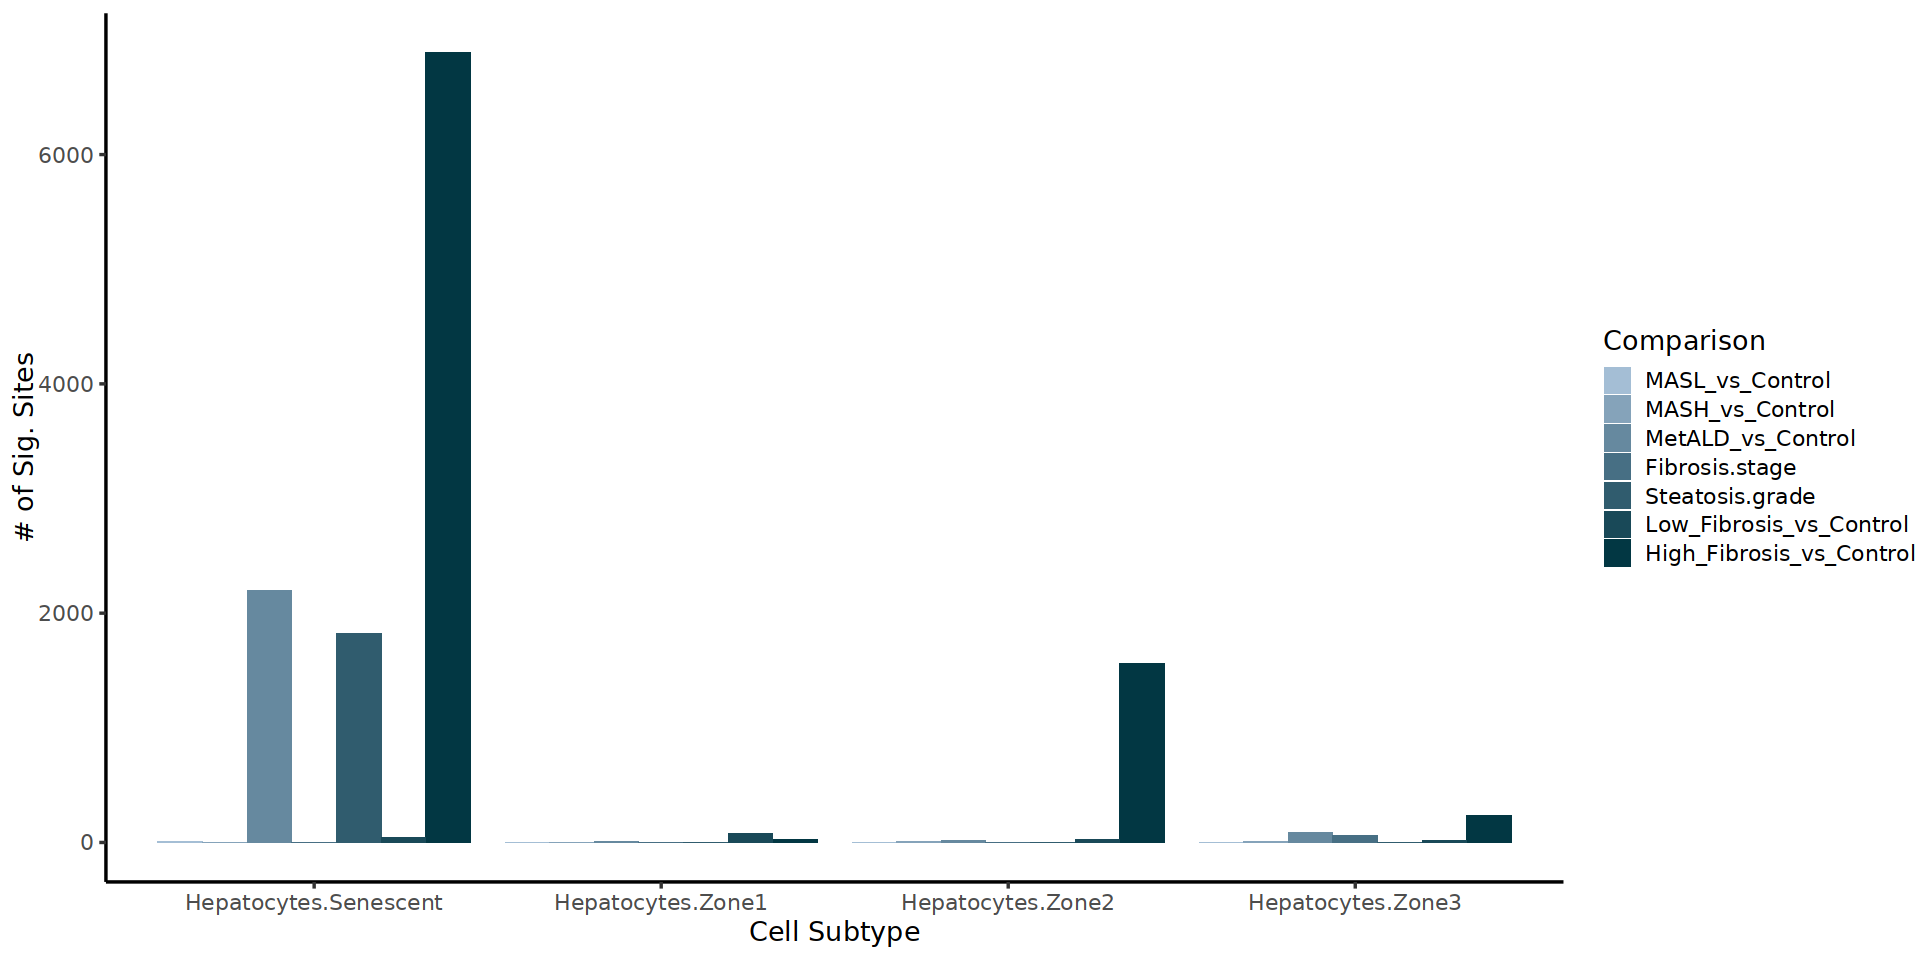

In [30]:
library(nationalparkcolors)

options(repr.plot.width=16, repr.plot.height=8)

p1 <- ggplot(select(deseq.stats2, -up_pval, -down_pval) %>%
    pivot_longer(c(up_padj, down_padj), values_to = 'sig',names_to = 'direction'),
       aes(x=celltype, fill=contrast, y=sig)) + geom_col(position = 'dodge') +
#scale_y_log10()+
    theme_classic(base_size=16) + scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(length(levels(deseq.stats2$contrast))))+
    labs(y='# of Sig. Sites', x= 'Cell Subtype', fill='Comparison')

p1

pdf('/nfs/lab/welison/Liver/Plots/250109_HeK27me3_Subtypes_DEseq_Overview_All.pdf', width=16)
p1
dev.off()

In [31]:
deseq.stats2 <- deseq.stats

In [32]:
deseq.stats2 <- filter(deseq.stats2, contrast %in% c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control','Low_Fibrosis_vs_Control','High_Fibrosis_vs_Control')& celltype != 'Hepatocytes.Stress')
deseq.stats2$contrast <- factor(deseq.stats2$contrast, levels = c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control','Low_Fibrosis_vs_Control','High_Fibrosis_vs_Control'))
deseq.stats2$celltype <- factor(deseq.stats2$celltype, levels = unique(deseq.stats2$celltype))                         

pdf 
  2

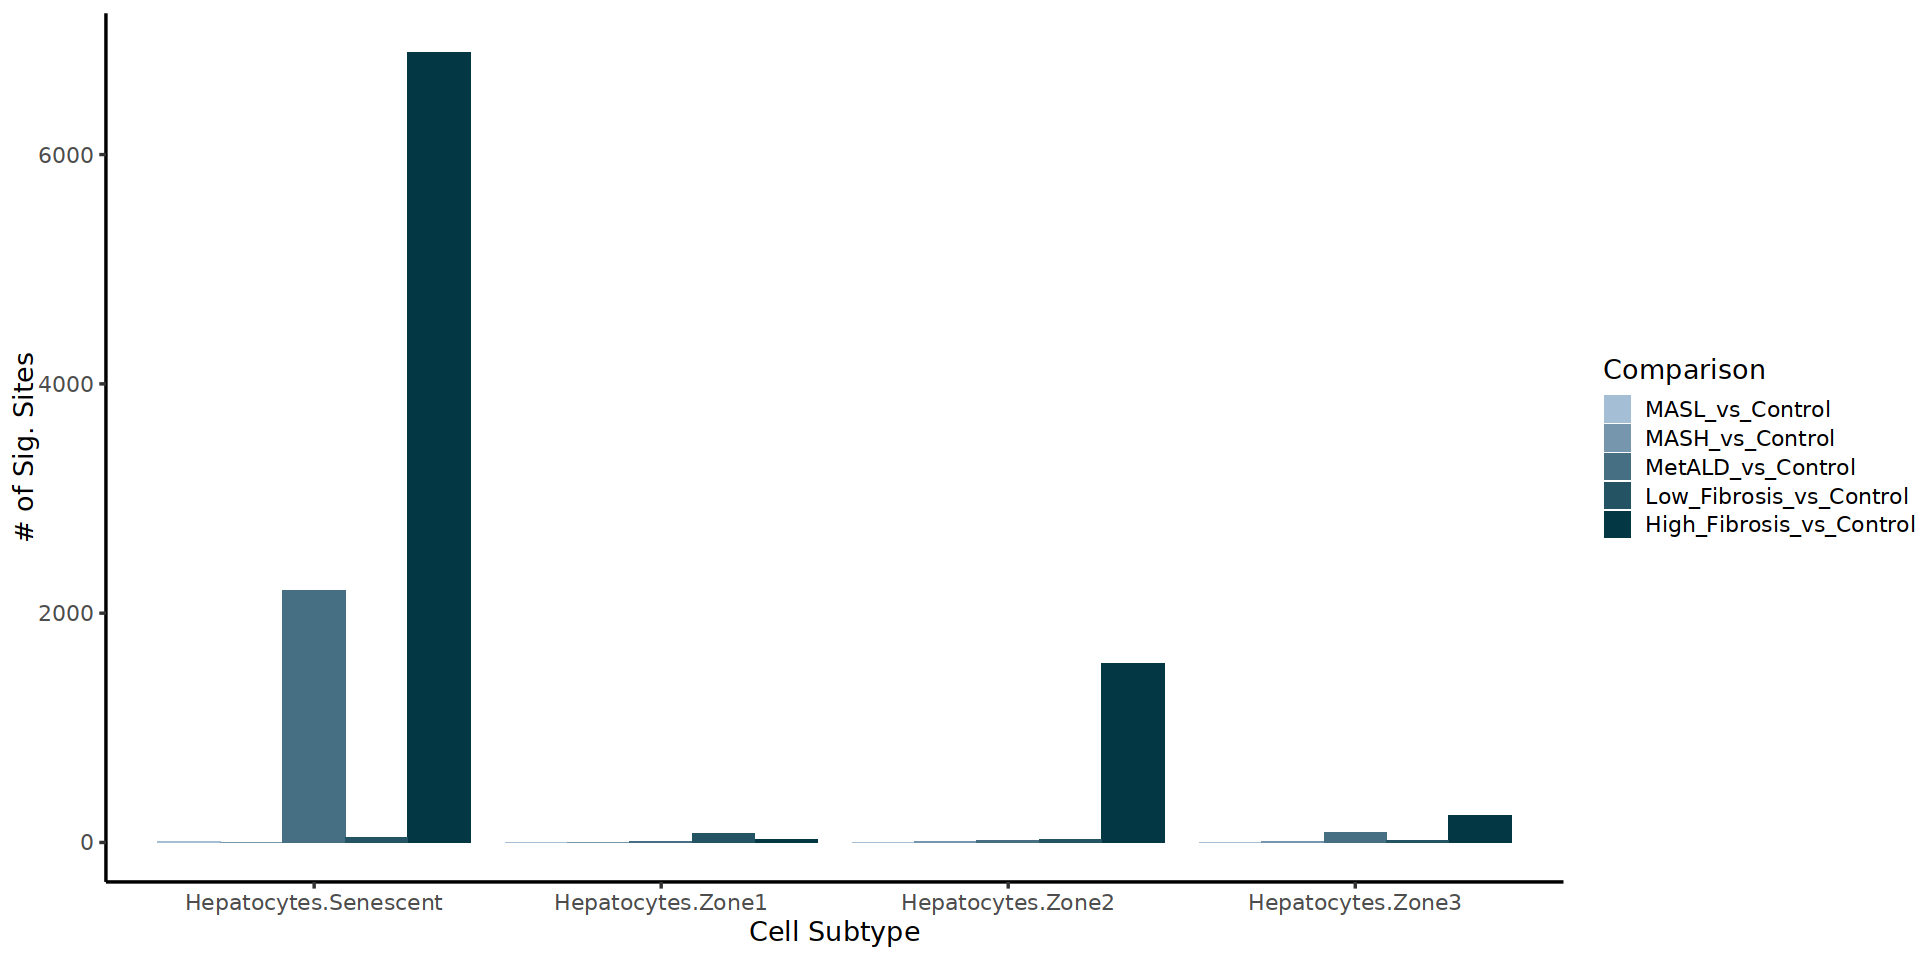

In [33]:
library(nationalparkcolors)

options(repr.plot.width=16, repr.plot.height=8)

p1 <- ggplot(select(deseq.stats2, -up_pval, -down_pval) %>%
    pivot_longer(c(up_padj, down_padj), values_to = 'sig',names_to = 'direction'),
       aes(x=celltype, fill=contrast, y=sig)) + geom_col(position = 'dodge') +
#scale_y_log10()+
    theme_classic(base_size=16) + scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(length(levels(deseq.stats2$contrast))))+
    labs(y='# of Sig. Sites', x= 'Cell Subtype', fill='Comparison')

p1

pdf('/nfs/lab/welison/Liver/Plots/250109_HeK27me3_Subtypes_DEseq_Overview_Fig_2_contrasts.pdf', width=16)
p1
dev.off()

In [34]:
deseq.stats2 <- deseq.stats

In [35]:
deseq.stats2 <- filter(deseq.stats2, contrast %in% c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control','Fibrosis.stage','Steatosis.grade')& celltype != 'Hepatocytes.Stress')
deseq.stats2$contrast <- factor(deseq.stats2$contrast, levels = c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control','Fibrosis.stage','Steatosis.grade'))
deseq.stats2$celltype <- factor(deseq.stats2$celltype, levels = unique(deseq.stats2$celltype))                         

pdf 
  2

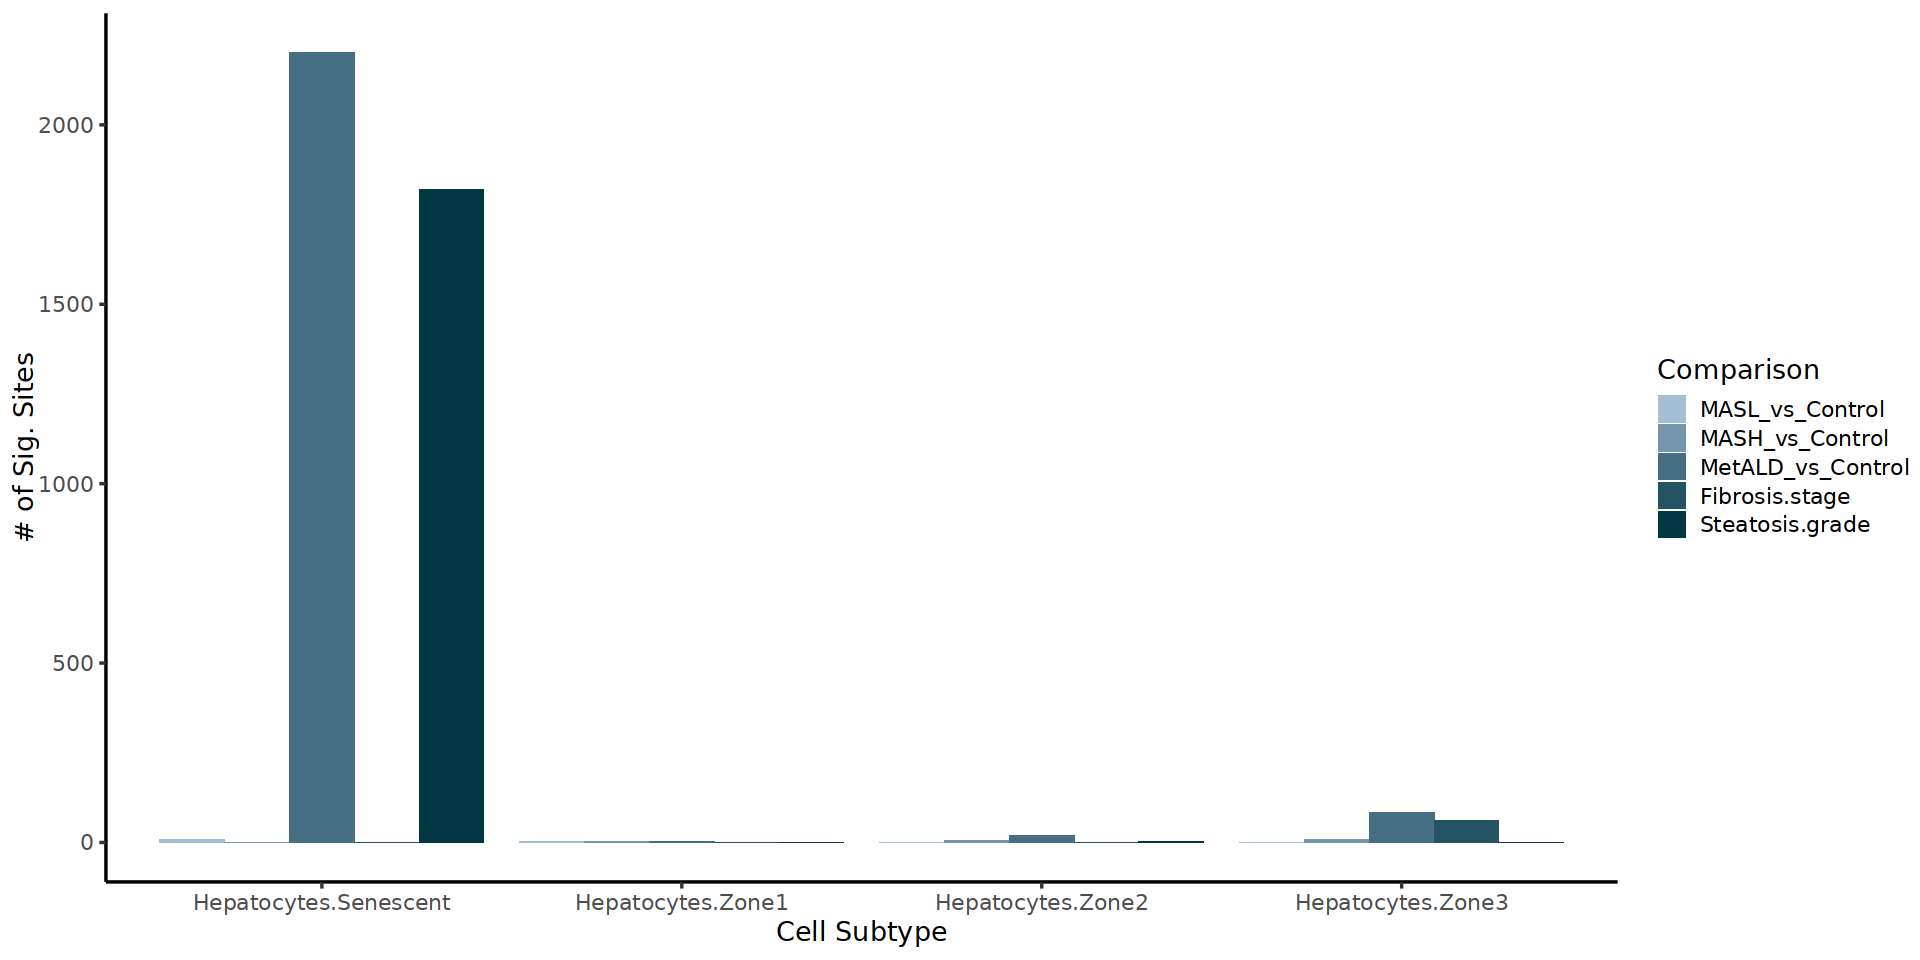

In [36]:
library(nationalparkcolors)

options(repr.plot.width=16, repr.plot.height=8)

p1 <- ggplot(select(deseq.stats2, -up_pval, -down_pval) %>%
    pivot_longer(c(up_padj, down_padj), values_to = 'sig',names_to = 'direction'),
       aes(x=celltype, fill=contrast, y=sig)) + geom_col(position = 'dodge') +
#scale_y_log10()+
    theme_classic(base_size=16) + scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(length(levels(deseq.stats2$contrast))))+
    labs(y='# of Sig. Sites', x= 'Cell Subtype', fill='Comparison')

p1

pdf('/nfs/lab/welison/Liver/Plots/250109_HeK27me3_Subtypes_DEseq_Overview_Match_RNA.pdf', width=16)
p1
dev.off()

In [34]:
deseq.stats2 <- deseq.stats

In [35]:
deseq.stats2 <- filter(deseq.stats2, contrast %in% c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control','Low_Fibrosis_vs_Control','High_Fibrosis_vs_Control')& celltype != 'Hepatocytes.Stress')
deseq.stats2$contrast <- factor(deseq.stats2$contrast, levels = c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control','Low_Fibrosis_vs_Control','High_Fibrosis_vs_Control'))
deseq.stats2$celltype <- factor(deseq.stats2$celltype, levels = unique(deseq.stats2$celltype))                         

pdf 
  2

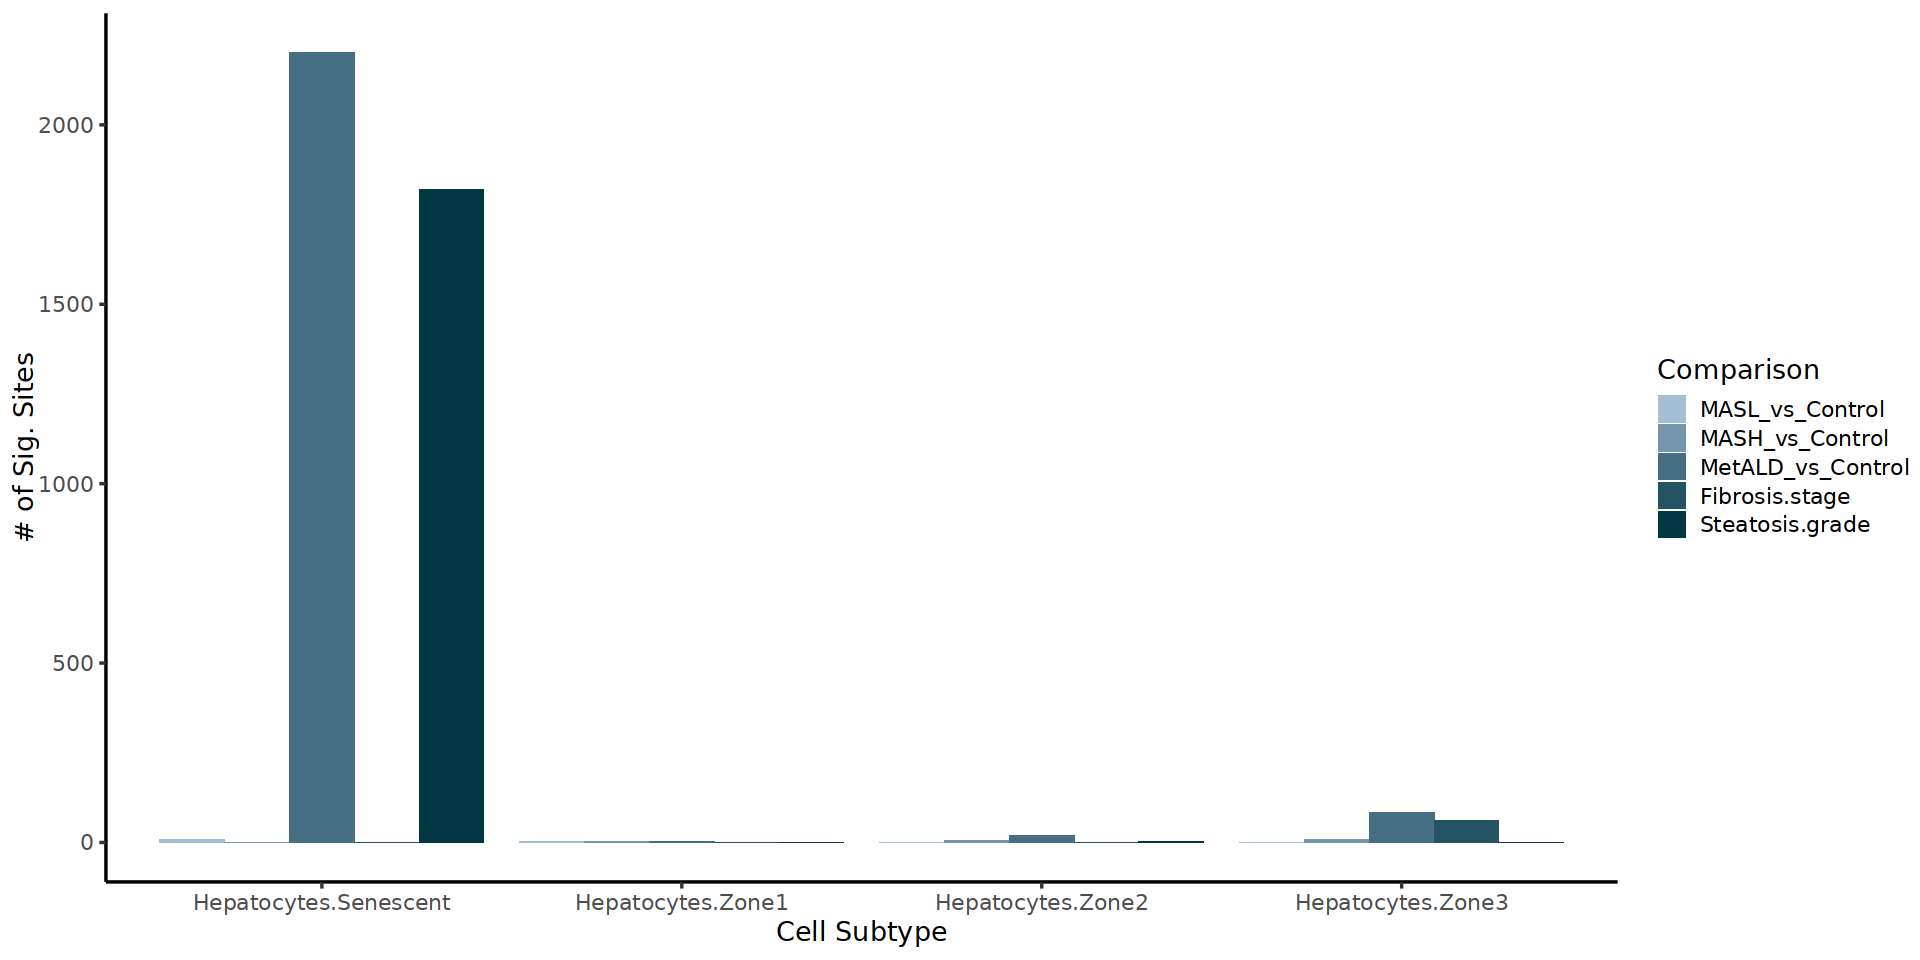

In [36]:
library(nationalparkcolors)

options(repr.plot.width=16, repr.plot.height=8)

p1 <- ggplot(select(deseq.stats2, -up_pval, -down_pval) %>%
    pivot_longer(c(up_padj, down_padj), values_to = 'sig',names_to = 'direction'),
       aes(x=celltype, fill=contrast, y=sig)) + geom_col(position = 'dodge') +
#scale_y_log10()+
    theme_classic(base_size=16) + scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(length(levels(deseq.stats2$contrast))))+
    labs(y='# of Sig. Sites', x= 'Cell Subtype', fill='Comparison')

p1

pdf('/nfs/lab/welison/Liver/Plots/250109_HeK27me3_Subtypes_DEseq_Overview_Match_RNA.pdf', width=16)
p1
dev.off()

In [66]:
deseq.stats2 <- deseq.stats

In [67]:
deseq.stats2 <- filter(deseq.stats2, contrast %in% c('MASL_vs_Control','Low_Fibrosis_vs_Control','High_Fibrosis_vs_Control')& celltype == 'Hepatocytes.Senescent')
deseq.stats2$contrast <- factor(deseq.stats2$contrast, levels = c('MASL_vs_Control','Low_Fibrosis_vs_Control','High_Fibrosis_vs_Control'))
deseq.stats2$celltype <- factor(deseq.stats2$celltype, levels = unique(deseq.stats2$celltype))                         

pdf 
  2

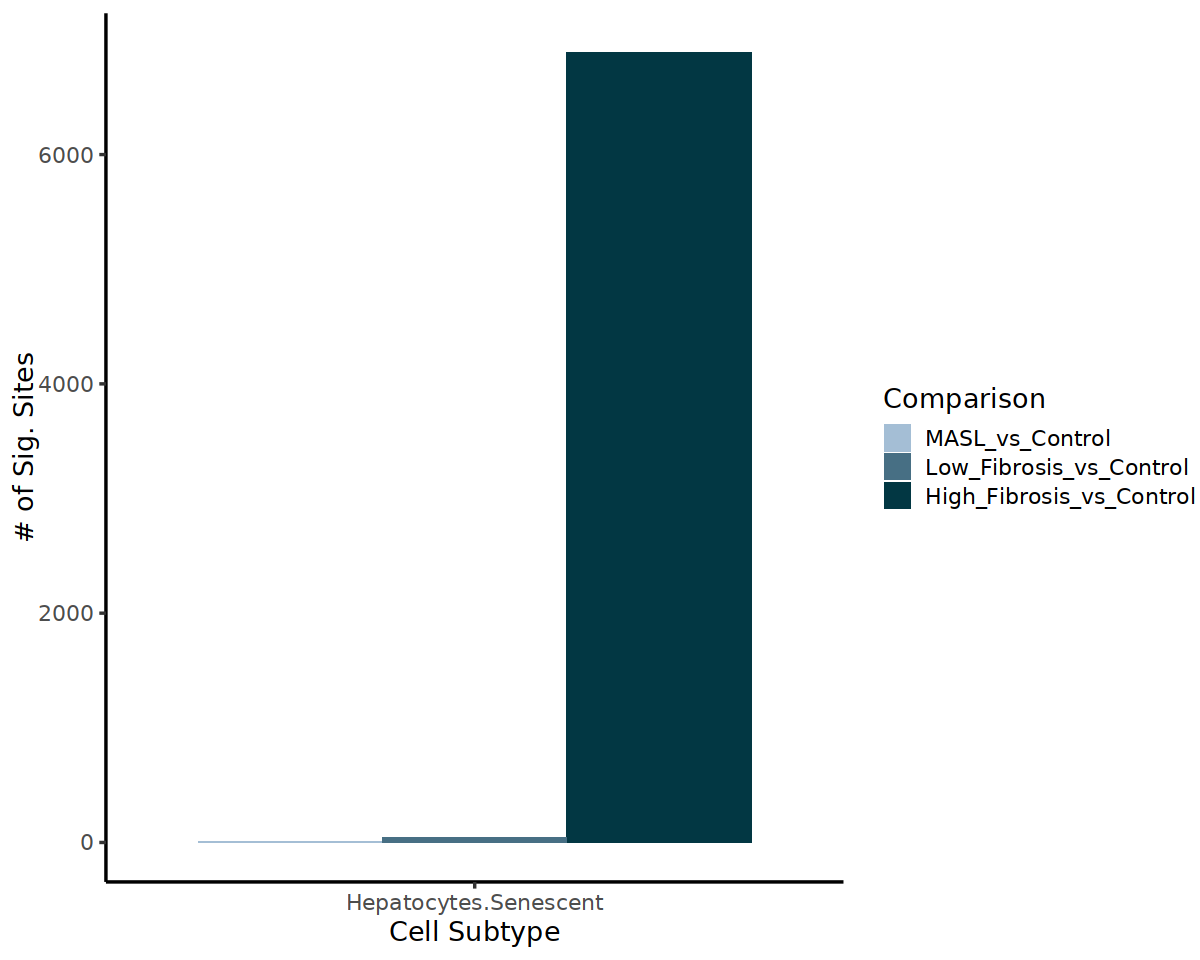

In [69]:
library(nationalparkcolors)

options(repr.plot.width=10, repr.plot.height=8)

p1 <- ggplot(select(deseq.stats2, -up_pval, -down_pval) %>%
    pivot_longer(c(up_padj, down_padj), values_to = 'sig',names_to = 'direction'),
       aes(x=celltype, fill=contrast, y=sig)) + geom_col(position = 'dodge') +
#scale_y_log10()+
    theme_classic(base_size=16) + scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(length(levels(deseq.stats2$contrast))))+
    labs(y='# of Sig. Sites', x= 'Cell Subtype', fill='Comparison')

p1

pdf('/nfs/lab/welison/Liver/Plots/250109_HeK27me3_Subtypes_DEseq_Overview_Allen_Spec.pdf', width=16)
p1
dev.off()

In [42]:
unique(deseq.stats$contrast)

[1] "MASL_vs_Control"          "MASH_vs_Control"         
[3] "MetALD_vs_Control"        "Fibrosis.stage"          
[5] "Steatosis.grade"          "High_Fibrosis_vs_Control"
[7] "Low_Fibrosis_vs_Control"

In [62]:
rna.deseq.stats <- data.frame()
for (cell in unique(deseq.stats$celltype)) {
    for (contrast in unique(deseq.stats$contrast)) {
        file <- paste0('/nfs/lab/tscc/welison/FNIH.Liver/subtypes/01_DESEQ_RNA_Hepatocytes_Subtypes/',cell,'_',contrast,'.dds.res')
        
        if (!file.exists(file)) {
            next
        }
        dds.rna <- read.table(file, header=T)
        
        deseq.stats.tmp <- data.frame(
            celltype = cell,
            contrast = contrast,
            up_pval = sum(dds.rna$log2FoldChange > 0 & dds.rna$pvalue < 0.05),
            down_pval = sum(dds.rna$log2FoldChange < 0 & dds.rna$pvalue < 0.05),
            up_padj = sum(dds.rna$log2FoldChange > 0 & dds.rna$padj < 0.1),
            down_padj = sum(dds.rna$log2FoldChange < 0 & dds.rna$padj < 0.1))
        rna.deseq.stats <- rbind(rna.deseq.stats, deseq.stats.tmp)
    }
}
dim(rna.deseq.stats)
head(rna.deseq.stats)

[1] 35  6

,celltype,contrast,up_pval,down_pval,up_padj,down_padj
,<chr>,<chr>,<int>,<int>,<int>,<int>
1,Hepatocytes.Senescent,MASL_vs_Control,494,450,1,2
2,Hepatocytes.Senescent,MASH_vs_Control,1164,636,239,77
3,Hepatocytes.Senescent,MetALD_vs_Control,1375,1037,548,220
4,Hepatocytes.Senescent,Fibrosis.stage,2684,2388,2008,1602
5,Hepatocytes.Senescent,Steatosis.grade,762,637,6,6
6,Hepatocytes.Senescent,High_Fibrosis_vs_Control,1633,1155,793,411


In [63]:
rna.deseq.stats

celltype,contrast,up_pval,down_pval,up_padj,down_padj
<chr>,<chr>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,MASL_vs_Control,494,450,1,2
Hepatocytes.Senescent,MASH_vs_Control,1164,636,239,77
Hepatocytes.Senescent,MetALD_vs_Control,1375,1037,548,220
Hepatocytes.Senescent,Fibrosis.stage,2684,2388,2008,1602
Hepatocytes.Senescent,Steatosis.grade,762,637,6,6
Hepatocytes.Senescent,High_Fibrosis_vs_Control,1633,1155,793,411
Hepatocytes.Senescent,Low_Fibrosis_vs_Control,368,528,0,1
Hepatocytes.Zone1,MASL_vs_Control,334,736,2,15
Hepatocytes.Zone1,MASH_vs_Control,693,453,50,26


In [21]:
rna.deseq.stats

celltype,contrast,up_pval,down_pval,up_padj,down_padj
<chr>,<chr>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,MASL_vs_Control,494,450,1,2
Hepatocytes.Senescent,MASH_vs_Control,1164,636,239,77
Hepatocytes.Senescent,MetALD_vs_Control,1375,1037,548,220
Hepatocytes.Senescent,Fibrosis.stage,2684,2388,2008,1602
Hepatocytes.Senescent,Steatosis.grade,762,637,6,6
Hepatocytes.Zone1,MASL_vs_Control,334,736,2,15
Hepatocytes.Zone1,MASH_vs_Control,693,453,50,26
Hepatocytes.Zone1,MetALD_vs_Control,426,613,48,23
Hepatocytes.Zone1,Fibrosis.stage,1612,1413,671,430


In [196]:
mutate(rna.deseq.stats, sig = up_padj + down_padj) %>%
    select(celltype, contrast, sig) %>%
    pivot_wider(names_from = contrast, values_from = sig)

celltype,MASL_vs_Control,MASH_vs_Control,MetALD_vs_Control,MASH_ALL_vs_Control,Fibrosis.stage,Steatosis.grade,Lobular.inflammation,MASH.CRN.score..X.8,Age,Age.scaled,BMI,BMI.scaled,Ballooning
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,3,316,768,1187,3610,12,9,43,10,11,14,16,NA
Hepatocytes.Zone1,17,76,71,170,1101,15,4,26,16,16,18,18,NA
Hepatocytes.Zone2,10,162,107,263,1671,16,2,24,63,64,43,45,NA
Hepatocytes.Zone3,2,216,240,476,2848,43,11,90,52,48,63,69,NA
Hepatocytes.Stress,2,6,1,1,12,0,0,1,0,0,0,0,1


In [24]:
rna.deseq.stats2 <- rna.deseq.stats

In [25]:
rna.deseq.stats2 <- filter(rna.deseq.stats2, contrast %in% c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control','Fibrosis.stage','Steatosis.grade','Low_Fibrosis_vs_Control','High_Fibrosis_vs_Control')& celltype != 'Hepatocytes.Stress')
rna.deseq.stats2$contrast <- factor(rna.deseq.stats2$contrast, levels = unique(rna.deseq.stats2$contrast))
rna.deseq.stats2$celltype <- factor(rna.deseq.stats2$celltype, levels = unique(rna.deseq.stats2$celltype))                         

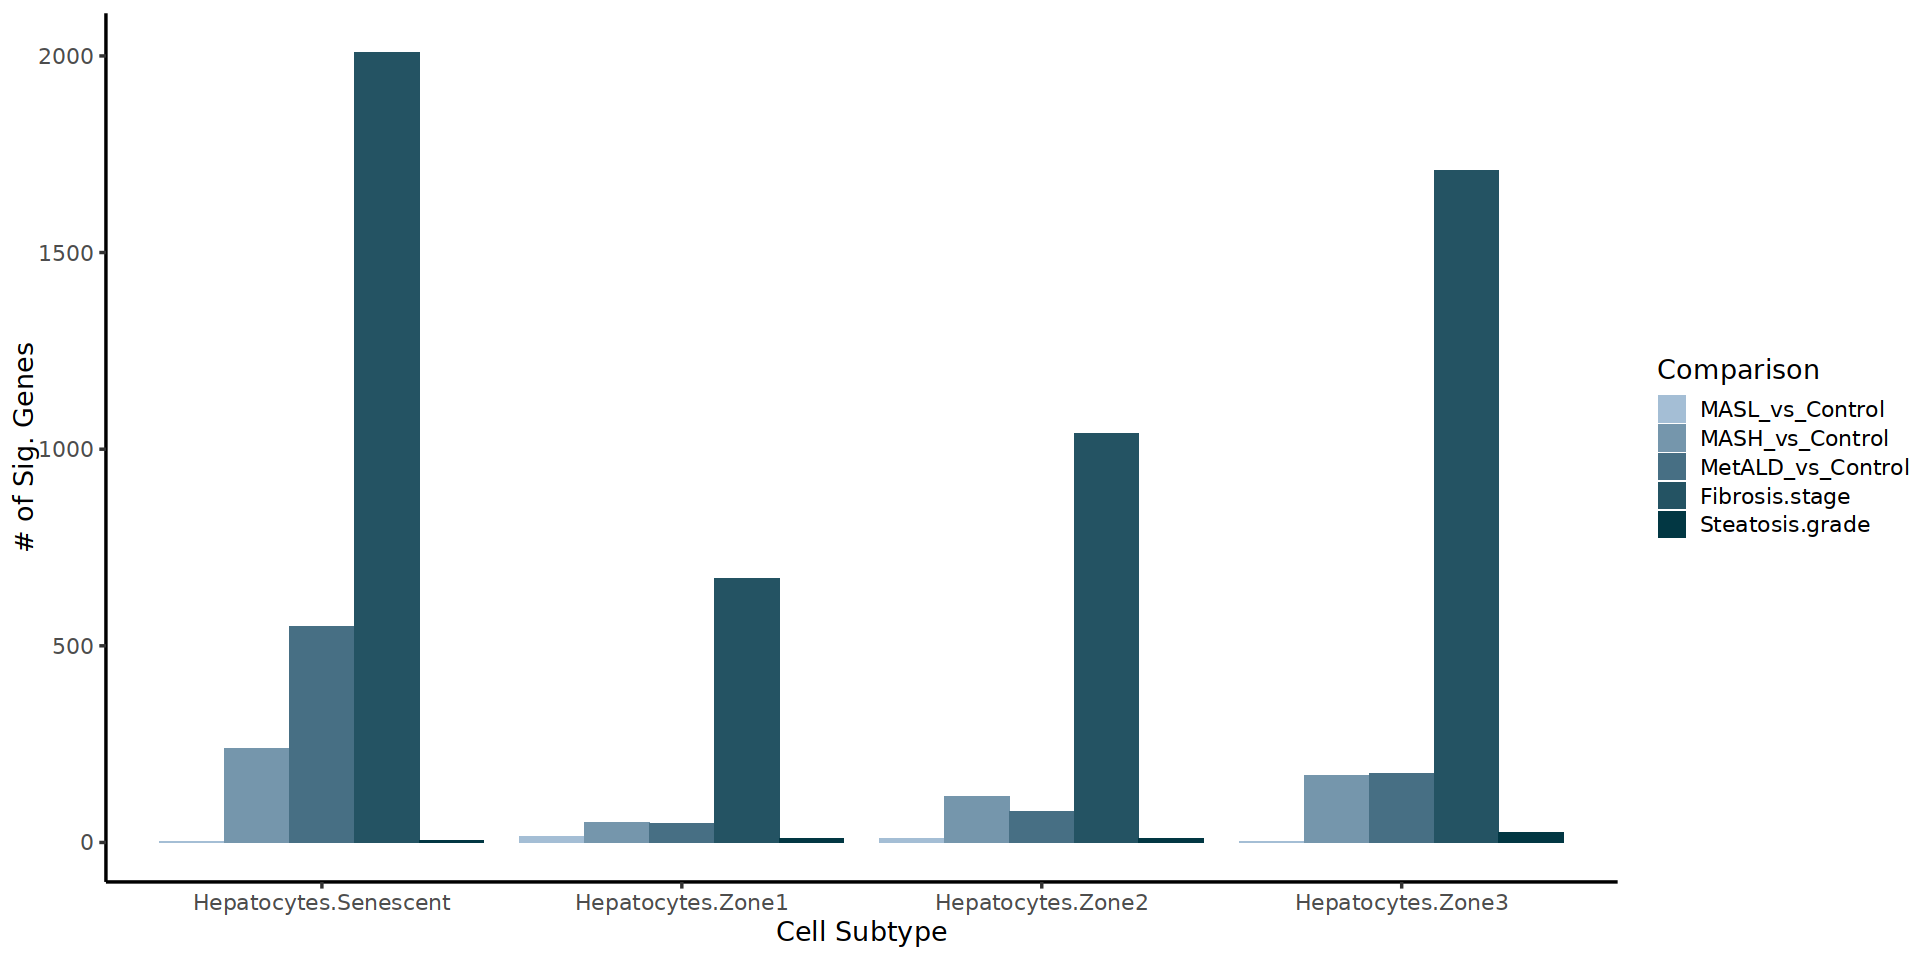

pdf 
  2

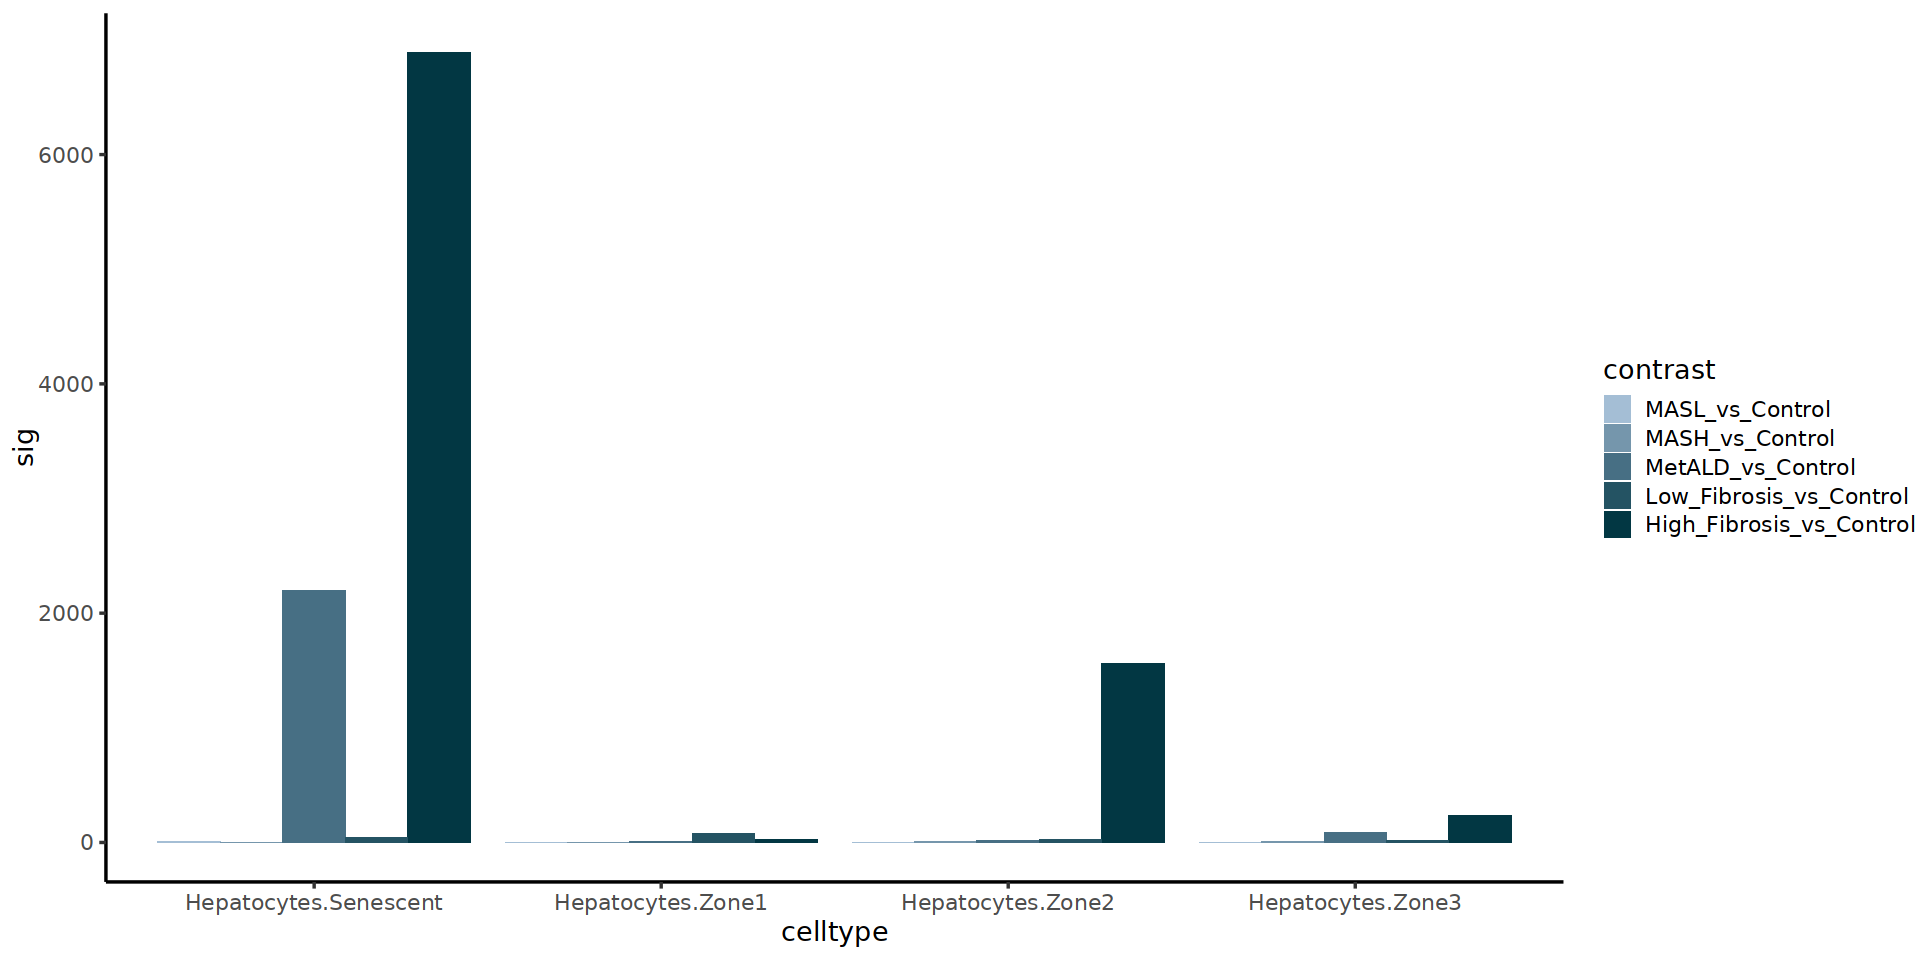

In [27]:
library(nationalparkcolors)

options(repr.plot.width=16, repr.plot.height=8)

ggplot(select(rna.deseq.stats2, -up_pval, -down_pval) %>%
    pivot_longer(c(up_padj, down_padj), values_to = 'sig',names_to = 'direction'),
       aes(x=celltype, fill=contrast, y=sig)) + geom_col(position = 'dodge') +
#scale_y_log10()+
    theme_classic(base_size=16) + scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(length(levels(rna.deseq.stats2$contrast)))) +
    labs(y='# of Sig. Genes', x= 'Cell Subtype', fill='Comparison')

p1

pdf('/nfs/lab/welison/Liver/Plots/250109_RNA_Subtypes_DEseq_Overview.pdf', width=16)
p1
dev.off()

In [74]:
rna.deseq.stats2 <- rna.deseq.stats

In [73]:
rna.deseq.stats

celltype,contrast,up_pval,down_pval,up_padj,down_padj
<chr>,<chr>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,MASL_vs_Control,494,450,1,2
Hepatocytes.Senescent,MASH_vs_Control,1164,636,239,77
Hepatocytes.Senescent,MetALD_vs_Control,1375,1037,548,220
Hepatocytes.Senescent,Fibrosis.stage,2684,2388,2008,1602
Hepatocytes.Senescent,Steatosis.grade,762,637,6,6
Hepatocytes.Senescent,High_Fibrosis_vs_Control,1633,1155,793,411
Hepatocytes.Senescent,Low_Fibrosis_vs_Control,368,528,0,1
Hepatocytes.Zone1,MASL_vs_Control,334,736,2,15
Hepatocytes.Zone1,MASH_vs_Control,693,453,50,26


In [75]:
rna.deseq.stats2 <- filter(rna.deseq.stats2, contrast %in% c('MASL_vs_Control','Low_Fibrosis_vs_Control','High_Fibrosis_vs_Control')& celltype == 'Hepatocytes.Senescent')
rna.deseq.stats2$contrast <- factor(rna.deseq.stats2$contrast, levels = c('MASL_vs_Control','Low_Fibrosis_vs_Control','High_Fibrosis_vs_Control'))
rna.deseq.stats2$celltype <- factor(rna.deseq.stats2$celltype, levels = unique(rna.deseq.stats2$celltype))                         

pdf 
  2

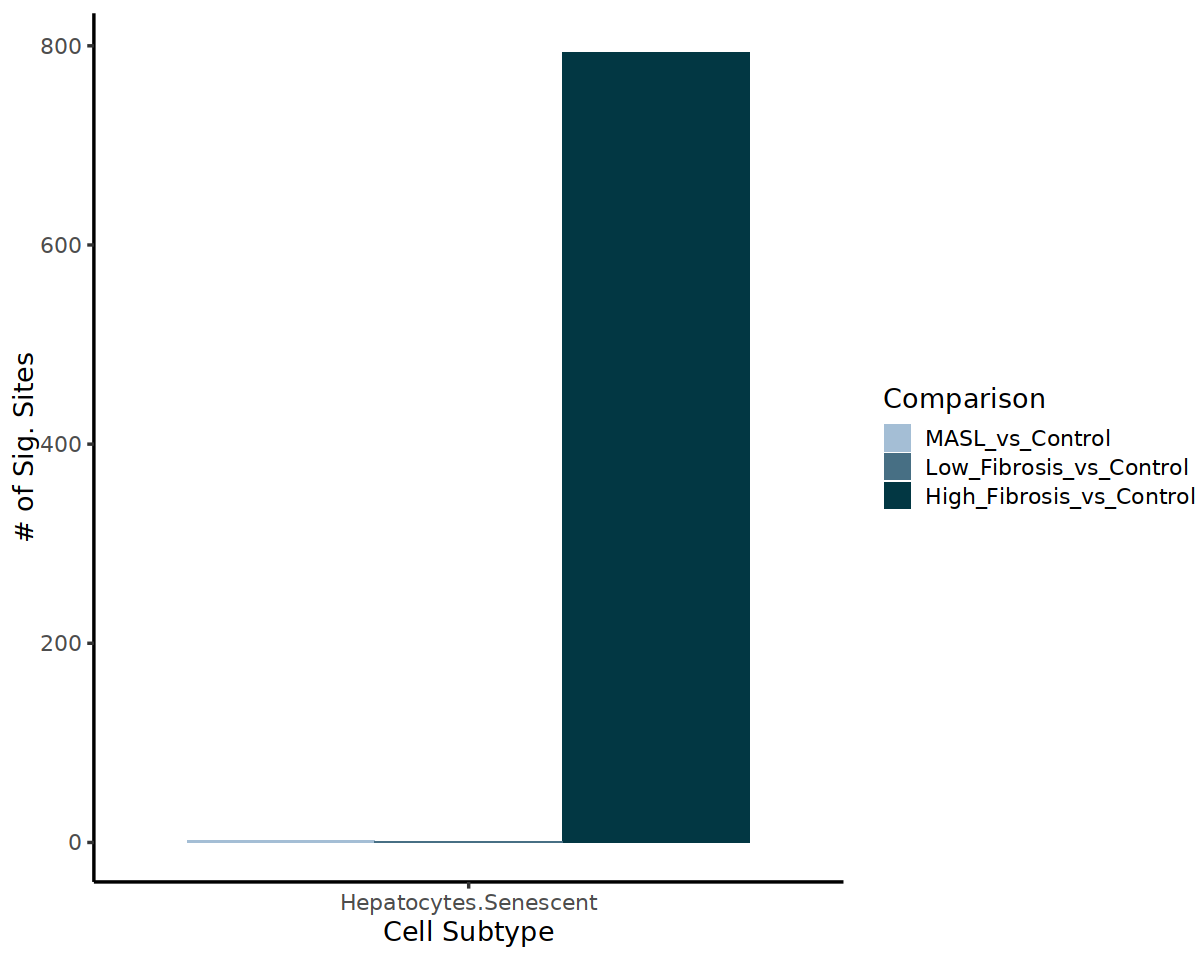

In [76]:
library(nationalparkcolors)

options(repr.plot.width=10, repr.plot.height=8)

p1 <- ggplot(select(rna.deseq.stats2, -up_pval, -down_pval) %>%
    pivot_longer(c(up_padj, down_padj), values_to = 'sig',names_to = 'direction'),
       aes(x=celltype, fill=contrast, y=sig)) + geom_col(position = 'dodge') +
#scale_y_log10()+
    theme_classic(base_size=16) + scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(length(levels(rna.deseq.stats2$contrast))))+
    labs(y='# of Sig. Sites', x= 'Cell Subtype', fill='Comparison')

p1

pdf('/nfs/lab/welison/Liver/Plots/250109_RNA_Subtypes_DEseq_Overview_Allen_Spec.pdf', width=16)
p1
dev.off()

In [11]:
#Pseudobulk matrices directory
dir <- '/nfs/lab/projects/nash_nafld_liver/downstream_all/09_H3K27me3_DESEQ/15kb_bins/Subtype.Hepatocytes/'
#Create outdir for results
outdir <- '/nfs/lab/projects/nash_nafld_liver/downstream_all/09_H3K27me3_DESEQ/15kb_bins/Subtype.Hepatocytes/'
#dir.create(outdir)

files <- list.files(dir, pattern='tsv')
#Cut off file suffices to get celltype names
cells <- gsub('.tsv','', files)

files <- files[str_detect(files, 'Hep')]
cells <- cells[str_detect(cells, 'Hep')]

files
cells

[1] "Hepatocytes.Senescent.tsv" "Hepatocytes.Stress.tsv"   
[3] "Hepatocytes.Zone1.tsv"     "Hepatocytes.Zone2.tsv"    
[5] "Hepatocytes.Zone3.tsv"

[1] "Hepatocytes.Senescent" "Hepatocytes.Stress"    "Hepatocytes.Zone1"    
[4] "Hepatocytes.Zone2"     "Hepatocytes.Zone3"

In [12]:
# List your contrasts  
conditions.1 = c("Low_Fibrosis", "High_Fibrosis") # disease
conditions.2 = c("Control", "Control") # control
contrasts = c(paste0(conditions.1, "_vs_", conditions.2))

# Write your formual
deseq.formula <- as.formula('~ Age.scaled + BMI.scaled + batch + Gender + condition') # last variable is the testing variable

In [13]:
raw_counts <- read.table(paste0(dir, file.use), header = TRUE, row.names = 1)
dim(raw_counts)

[1] 191678     69

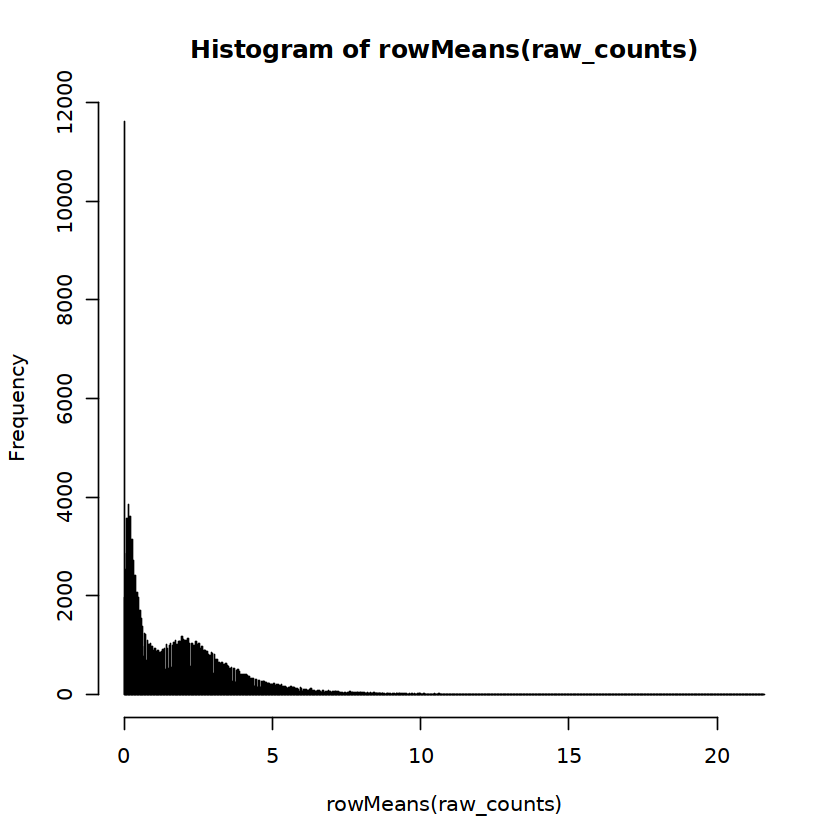

In [14]:
hist(rowMeans(raw_counts), breaks = 1000) 

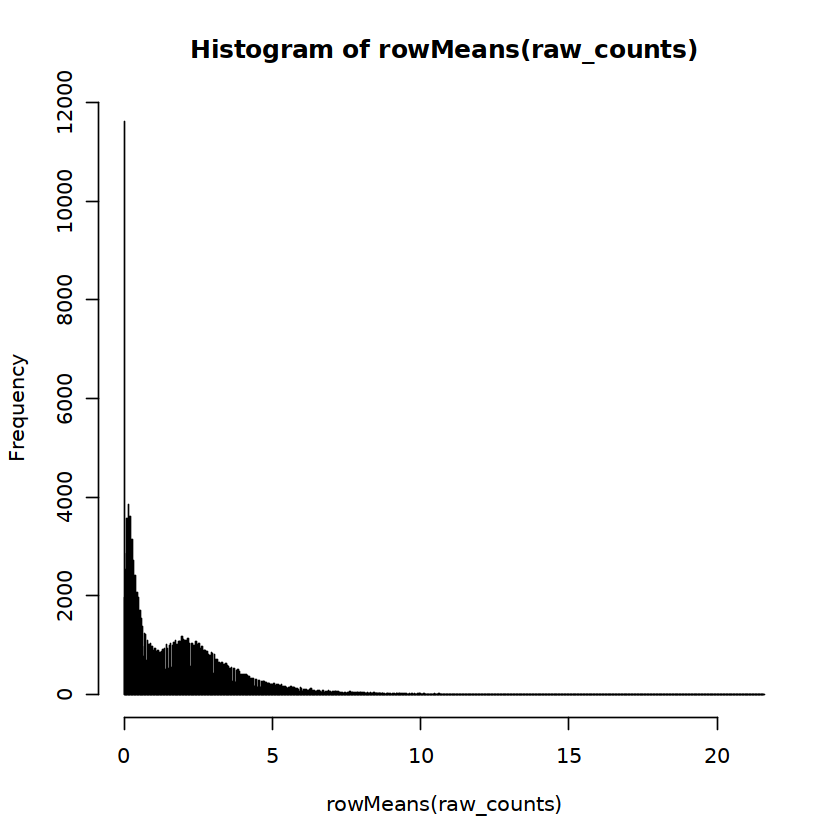

In [15]:
hist(rowMeans(raw_counts), breaks = 1000) 

In [19]:
deseq.stats.filt = NULL

for (i in seq_along(files)) {
    file.use = files[i]
    cell.use = cells[i]
    if(cell.use %in% c('Bulk')) {
        next
    }
    
    print(paste0("Analyzing: ", cell.use))
    raw_counts <- read.table(paste0(dir, file.use), header = TRUE, row.names = 1)
    #colnames(raw_counts) <- str_remove(colnames(raw_counts), paste0(cell.use, '.'))
    # Remove low bc cells
    #raw_counts <- raw_counts[colnames(raw_counts) %in% meta$donor_demux[meta[[cell.use]] > 10]]
    # Filter for only samples with any counts in the cell type rowSums(raw_counts == 0)
    raw_counts = raw_counts[, (colSums(raw_counts >= 0) > 0)]
    # Subset samples to make one feature with counts in every sample
    best.row <- raw_counts[which(rowSums(raw_counts!=0) == max(rowSums(raw_counts != 0))),][1,]
    raw_counts <- raw_counts[colnames(raw_counts) %in% colnames(best.row)[best.row != 0]]
    print(dim(raw_counts))
    
    message("Donors detectected with celltype: ", ncol(raw_counts))
    if(ncol(raw_counts) == 0) {
        next
    }
    meta_cell <- subset(meta, donor %in% colnames(raw_counts))
    rownames(meta_cell) = meta_cell$donor
    message("subsetting metadata accordingly - Check that value is equal to above: ", nrow(meta_cell))
    # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
    meta_cell <- meta_cell[match(colnames(raw_counts), rownames(meta_cell)), ]
    
    for (c.i in seq_along(contrasts)) {
        contrast.use = contrasts[c.i]
        condition.1 = conditions.1[c.i]
        condition.2 = conditions.2[c.i]
        message("  - ", contrast.use)

        # Create vectors of samples for each condition
        if (condition.1 == 'Low_Fibrosis') {
            samples.condition.1 <- meta_cell %>% 
                               dplyr::filter(condition %in% c('MASH','MetALD') & Fibrosis.stage <= 2) %>% 
                               pull(donor)
        } else {
            samples.condition.1 <- meta_cell %>% 
                               dplyr::filter(condition %in% c('MASH','MetALD') & Fibrosis.stage >= 3) %>% 
                               pull(donor)
        }
        samples.condition.2 <- meta_cell %>% 
                               dplyr::filter(condition %in% condition.2) %>% 
                               pull(donor)
        
        if(length(samples.condition.1) < 3) {
            next
        }
        if(length(samples.condition.2) < 3) {
            next
        }
        
        # Subset meta_cell for the current contrast
        meta_cell.use <- meta_cell %>% 
                     dplyr::filter(donor %in% c(samples.condition.1, samples.condition.2)) 
        rownames(meta_cell.use) <- meta_cell.use$donor
        
        # Subset raw_counts for the donors in meta_cell
        raw_counts_subset <- raw_counts[, colnames(raw_counts) %in% rownames(meta_cell.use)]

        # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
        meta_cell.use <- meta_cell.use[match(colnames(raw_counts_subset), rownames(meta_cell.use)), ]
        
        # Check if enough samples are present for both conditions
        if (length(unique(meta_cell.use$condition)) >= 2) {
            deseq.stats.tmp <- data.frame()
            
            # Light pre-filtering
            counts_filtered <- raw_counts_subset[rowSums(raw_counts_subset) >= 50,]

            # Run DESeq2
            tryCatch({
            dds <- DESeqDataSetFromMatrix(countData = round(counts_filtered),
                                              colData = meta_cell.use, 
                                              design = deseq.formula)
            dds$condition <- relevel(dds$condition, ref = condition.2)
            dds <- DESeq(dds)
            dds.results <- results(dds)
                
            # Write DESeq results to file
            #write.table(dds.results, 
            #            file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
            #            sep = '\t', quote = FALSE)
                
            dds.results <- na.omit(dds.results[order(dds.results$padj), ])

            # Write DESeq results to file
            #write.table(dds.results, 
            #            file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
            #            sep = '\t', quote = FALSE)
            
            # Collect summary statistics
            deseq.stats.tmp <- data.frame(
                celltype = cell.use,
                contrast = contrast.use,
                up_pval = sum(dds.results$log2FoldChange > 0 & dds.results$pvalue < 0.05),
                down_pval = sum(dds.results$log2FoldChange < 0 & dds.results$pvalue < 0.05),
                up_padj = sum(dds.results$log2FoldChange > 0 & dds.results$padj < 0.1),
                down_padj = sum(dds.results$log2FoldChange < 0 & dds.results$padj < 0.1))
                deseq.stats.filt <- rbind(deseq.stats.filt, deseq.stats.tmp)

                           # Make Volcano plot - Padj
                            res = as.data.frame(dds.results)
                            res$SYMBOL = rownames(res)
                            res = res %>%
                            dplyr::filter(!is.na(SYMBOL)) %>%
                            dplyr::filter(padj < 0.1) %>%
                            dplyr::group_by(sign(log2FoldChange)) %>%
                            dplyr::mutate(rank = abs(log2FoldChange) * -log10(padj)) %>%
                            dplyr::top_n(50, rank) %>%
                            dplyr::mutate(delabel = SYMBOL) %>%
                            ungroup() %>%
                            dplyr::select(delabel, SYMBOL) %>%
                            right_join(res) %>%
                            dplyr::mutate(delabel = if_else(is.na(delabel), "", as.character(delabel))) 

                            # Add a new column for color based on significance and direction
                            res$changes <- ifelse(res$log2FoldChange > 0 & res$padj < 0.1, "Up-regulated",
                                                ifelse(res$log2FoldChange < 0 & res$padj < 0.1, "Down-regulated", "NS"))
                            # Get the number of upregulated and downregulated genes
                            n_up <- sum(res$changes == "Up-regulated")
                            n_down <- sum(res$changes == "Down-regulated")

                            # Modify log2FoldChange values to be max x
                            res$log2FoldChange[res$log2FoldChange > 10] <- 10
                            res$log2FoldChange[res$log2FoldChange < -10] <- -10
                            # Modify padj values to be max x 
                            res$padj[res$padj < 10^-200] <- 10^-200
                    
                            plot = ggplot(res, aes(x=log2FoldChange, y=-log10(padj), label=delabel, color=changes)) +
                                theme_bw() +
                                labs(y="-log10(padj)", x="log2FoldChange", 
                                   title=paste(cell.use, " - ",
                                               condition.1, "Vs", condition.2, "\n",
                                              "Up: ", n_up, "-",
                                               "Down: ", n_down)) +
                                geom_point() +
                                scale_color_manual(values=c("blue", "grey", "red")) + 
                                theme(axis.text=element_text(size=16), axis.title=element_text(size=16, face="bold"),
                                    axis.text.x=element_text(), plot.title=element_text(size=18, face="bold", hjust=0.5)) +
                                scale_x_continuous(breaks=c(-10, -5, 0, 5, 10),
                                            labels=c("< -10", "-5", "0", "5", "> 10"), lim = c(-10, 10))+
                                scale_y_continuous(breaks=c(0, 20, 40, 60, 80, 100, 200),
                                            labels=c("0", "20", "40", "60", "80", "100", ">200"))+
                                geom_text_repel(label=res$delabel, size=3.5, max.overlaps=10,
                                              point.padding=0, min.segment.length=0,
                                              max.time=20, max.iter=1e5, box.padding=0.3)
                    
                            #ggsave(filename = paste0(outdir, cell.use, "_", contrast.use, ".volcanoPlot.pdf"),
                            #       height = 10, width = 10,
                            #       plot = plot, device = "pdf")
                #when it throws an error, the following block catches the error
                }, error = function(e) {
                message(paste0("Skipping contrast ", contrast.use, ": ", e$message))
            })
        } else {
            message("Not enough samples for contrast: ", contrast.use)
        }
    }
}

[1] "Analyzing: Hepatocytes.Senescent"
[1] 191678     56


Donors detectected with celltype: 56

subsetting metadata accordingly - Check that value is equal to above: 56

  - Low_Fibrosis_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion es

[1] "Analyzing: Hepatocytes.Stress"
[1] 191678     15


Donors detectected with celltype: 15

subsetting metadata accordingly - Check that value is equal to above: 15

  - Low_Fibrosis_vs_Control

  - High_Fibrosis_vs_Control



[1] "Analyzing: Hepatocytes.Zone1"
[1] 191678     48


Donors detectected with celltype: 48

subsetting metadata accordingly - Check that value is equal to above: 48

  - Low_Fibrosis_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion es

[1] "Analyzing: Hepatocytes.Zone2"
[1] 191678     37


Donors detectected with celltype: 37

subsetting metadata accordingly - Check that value is equal to above: 37

  - Low_Fibrosis_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion es

[1] "Analyzing: Hepatocytes.Zone3"
[1] 191678     69


Donors detectected with celltype: 69

subsetting metadata accordingly - Check that value is equal to above: 69

  - Low_Fibrosis_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion es

In [20]:
deseq.stats.filt

celltype,contrast,up_pval,down_pval,up_padj,down_padj
<chr>,<chr>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,Low_Fibrosis_vs_Control,572,2,12,0
Hepatocytes.Senescent,High_Fibrosis_vs_Control,12673,21,4364,3
Hepatocytes.Zone1,Low_Fibrosis_vs_Control,1090,900,2,66
Hepatocytes.Zone1,High_Fibrosis_vs_Control,3049,548,2,12
Hepatocytes.Zone2,Low_Fibrosis_vs_Control,864,675,0,1
Hepatocytes.Zone2,High_Fibrosis_vs_Control,4276,21,1695,10
Hepatocytes.Zone3,Low_Fibrosis_vs_Control,405,1327,0,3
Hepatocytes.Zone3,High_Fibrosis_vs_Control,2476,2874,20,104
